# PetFinder — Modelo Tabular
**Maestría en Ciencia de Datos — Laboratorio de Implementación**

Alumnos: Martín Cacabelos, Julia Maxwell, Keiver Nuñez, Patricia Sandagorda, Carmen Tello

Este notebook cubre tres etapas en secuencia:
1. **Baseline** — LightGBM con features crudas, sin ingeniería
2. **Feature Engineering iterativo** — creación y evaluación incremental de variables
3. **Tuning** — optimización de hiperparámetros con Optuna

**Métrica principal:** Cohen's Kappa Cuadrático (QWK)  
**Métricas de seguimiento:** accuracy por clase, F1 macro  
**Validación:** StratifiedKFold(n_splits=5)

# 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import datetime
import pickle
from scipy import stats
import os
import joblib
from itertools import combinations
import re
import unicodedata

# Modelado
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import (
    cohen_kappa_score, accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.decomposition import PCA

# Text
import nltk
#nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer
from pysentimiento import create_analyzer
from sentence_transformers import SentenceTransformer

# Imágenes
from tqdm import tqdm
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader


# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
sns.set_palette('Set2')
PALETTE = sns.color_palette('Set2', 5)

SEEDS = [310019, 320009, 330017, 340007, 350029]
SEED    = 42
TARGET  = 'AdoptionSpeed'
N_FOLDS = 5
np.random.seed(SEED)

print('Librerías cargadas OK')
print(f'LightGBM version: {lgb.__version__}')

c:\Users\carte\miniconda3\envs\ldi2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas OK
LightGBM version: 4.6.0


In [2]:
kaggle_input_path = '/kaggle/input/competitions/petfinder-adoption-prediction/'
local_input_path   = '../input/petfinder-adoption-prediction/'

train  = pd.read_csv(os.path.join(local_input_path, 'train/train.csv'))
breeds = pd.read_csv(os.path.join(local_input_path, 'breed_labels.csv'))
colors = pd.read_csv(os.path.join(local_input_path, 'color_labels.csv'))
states = pd.read_csv(os.path.join(local_input_path, 'state_labels.csv'))

print(f'Train: {train.shape[0]:,} filas × {train.shape[1]} columnas')
train.head(2)

Train: 14,993 filas × 24 columnas


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0


---
# 1. Preprocesamiento base

Realizaremos una limpieza rápida de las variables, derivada del EDA.

- Name: para identificar mejor los animales con nombres genéricos o que en realidad corresponden a valores nulos, se imputa un valor Nan a los nombres con 2 caracteres o menos, que contenga alguna de las palabras declaradas en 'invalid_kw', que contenga algún caracter extraño, o que sea sólo numérico.
- Descripción: para identificar mejor los animales con descripciones genéricas o muy cortas e imputar valores nulos, los criterios son que tenga alguna de las palabras genéricas pertenecientes al diccionario 'generic_phrases' y que la descripción tenga menos de 40 caracteres; o que la descripción tenga menos de 10 caracteres.
- Breed: si la raza principal es igual a la secundaria, se mantiene sólo la primaria.
- Color: si el color primario es igual al secundario o terciario, se mantiene solo el primario.
- Labels: se crean variables con las etitquetas de raza, color y estado.
- Desduplicados: se quitan registros que tienen los mismos valores en todas las variables salvo PetID.

In [3]:
# ── Paso 1: Limpieza de Name ──────────────────────────────────────────────────
def fun_clean_name(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    invalid_kw = ['adoption','urgent','none','unknown','name','nan','n/a','yet','help']
    df['Name'] = df['Name'].astype(str).str.lower().str.strip()
    mask_name = (
        df['Name'].str.contains('|'.join(invalid_kw), na=False) |
        (df['Name'].str.len() <= 2) |
        df['Name'].str.match(r'^[^a-zA-Z0-9]+$') |
        df['Name'].str.isnumeric() |
        (df['Name'] == 'nan')
    )
    df.loc[mask_name, 'Name'] = np.nan
    return df

# ── Paso 3: Limpieza de Breed y Color ────────────────────────────────────────
def fun_clean_breed_color_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.loc[df['Breed1'] == df['Breed2'], 'Breed2'] = 0
    df.loc[df['Color1'] == df['Color2'], 'Color2'] = 0
    df.loc[df['Color1'] == df['Color3'], 'Color3'] = 0
    return df

# ── Paso 4: Merge con labels de razas ────────────────────────────────────────
def fun_merge_breed_labels(df: pd.DataFrame, breeds: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    breeds_ = breeds.copy()
    breeds_['Type']    = breeds_['Type'].astype(int)
    breeds_['BreedID'] = breeds_['BreedID'].astype(int)
    df['Type']   = df['Type'].astype(int)
    df['Breed1'] = df['Breed1'].astype(int)
    df['Breed2'] = df['Breed2'].astype(int)

    df = df.merge(breeds_, left_on=['Type','Breed1'], right_on=['Type','BreedID'], how='left')
    df.rename(columns={'BreedName': 'Breed1Name'}, inplace=True)
    df.drop(columns=['BreedID'], inplace=True)

    df = df.merge(breeds_, left_on=['Type','Breed2'], right_on=['Type','BreedID'], how='left')
    df.rename(columns={'BreedName': 'Breed2Name'}, inplace=True)
    df.drop(columns=['BreedID'], inplace=True)
    return df

# ── Paso 5: Mapeos de color y estado ─────────────────────────────────────────
def fun_map_color_state(df: pd.DataFrame, colors: pd.DataFrame, states: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    color_map = colors.set_index('ColorID')['ColorName'].to_dict()
    state_map = states.set_index('StateID')['StateName'].to_dict()
    df['StateName']   = df['State'].map(state_map)
    df['Color1Label'] = df['Color1'].map(color_map)
    return df

# ── Paso 6: Deduplicación ─────────────────────────────────────────────────────
def fun_deduplicate(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(by='PetID').drop_duplicates(
        subset=df.columns.difference(['PetID']), keep='first'
    )
    return df

df = train.copy()

df = fun_clean_name(df)
df = fun_clean_breed_color_duplicates(df)
df = fun_merge_breed_labels(df, breeds)
df = fun_map_color_state(df, colors, states)
df = fun_deduplicate(df)

---
# 2. Infraestructura de evaluación

### La función `run_cv` — punto de entrada principal

Función que ejecuta todo el pipeline desde el preprocesamiento de datos hasta la ejecución del modelo.

**Parámetros siempre presentes:**
- `X` — DataFrame con las features. Puede incluir columnas auxiliares (ej. `RescuerID`, `Description`) que se usan para calcular encodings internamente pero no entran directamente al modelo si son de tipo texto o ID.
- `y` — Serie con el target.
- `params` — dict con hiperparámetros de LightGBM.
- `cat_features` — para que LGBM identifique las variables categóricas.

- `experiment_name` — nombre del experimento.
- experiment_name

**Parámetros opcionales**
| Parámetro | Qué hace | Cuándo usarlo |
|---|---|---|
| `te_cols` | Target encoding dentro del fold | Variables de alta cardinalidad (Breed1, RescuerID) |
| `te_smoothing` | Suavizado del TE (default='auto') | Ajustar si hay pocas observaciones por categoría |
| `agg_config` | Aggregations por grupo dentro del fold | Estadísticas de comportamiento (mean_age, mean_fee por rescatista) |
| `agg_smoothing` | Suavizado del AGG | Ajustar si hay pocas observaciones por categoría |
| `aux_cols` | Columnas auxiliares para TE y AGG | Para los procesamientos de TE y Agg, se pasa la variable a encodear para que se pueda procesar luego de separar en train y test pero no sea incluída en el modelo |
| `eval_metric_fn` | Función de evaluación del modelo | Por defecto multi-logloss |


In [4]:
def qwk(y_true, y_pred):
    """Cohen's Kappa Cuadrático — métrica principal del problema."""
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

def run_cv(
    X, y, params,
    cat_features=None,
    n_folds=N_FOLDS,
    verbose=True,
    experiment_name='exp',
    seed=None,
    te_cols=None,
    te_smoothing=50,
    agg_config=None,
    agg_smoothing=0,
    aux_cols=None,
    eval_metric_fn=None,   
    pca_config=None,

):
    _seed = seed if seed is not None else SEED

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=_seed)
    fold_qwk, fold_acc, fold_f1 = [], [], []
    oof_preds = np.zeros(len(y))
    oof_proba  = np.zeros((len(y), 5))

    feature_names  = None
    feat_imp_gain_folds  = []
    feat_imp_split_folds = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr  = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr  = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        # ── PCA interno (sin leakage) ─────────────────────────────────────────
        if pca_config:
            for prefix, n_components in pca_config.items():
                # Seleccionar columnas que matcheen el prefijo
                pca_cols = [c for c in X_tr.columns if c.startswith(prefix)]
                if not pca_cols:
                    continue

                # Clampear n_components al máximo posible
                n_comp = min(n_components, len(pca_cols))

                pca = PCA(n_components=n_comp, random_state=_seed)
                tr_reduced  = pca.fit_transform(X_tr[pca_cols])   # fit solo en train
                val_reduced = pca.transform(X_val[pca_cols])      # transform en val

                new_cols = [f'{prefix}_pc{i}' for i in range(n_comp)]

                # Reemplazar columnas originales por las componentes
                X_tr  = X_tr.drop(columns=pca_cols)
                X_val = X_val.drop(columns=pca_cols)
                X_tr  = pd.concat([X_tr, pd.DataFrame(tr_reduced,  columns=new_cols, index=X_tr.index)],  axis=1)
                X_val = pd.concat([X_val, pd.DataFrame(val_reduced, columns=new_cols, index=X_val.index)], axis=1)

        # ── Target Encoding ──────────────────────────────────────────────────
        if te_cols:
            te = TargetEncoder(
                smooth=te_smoothing,
                target_type='continuous',
                cv=5,
                random_state=_seed,
            )
            te_tr  = te.fit_transform(X_tr[te_cols], y_tr)
            te_val = te.transform(X_val[te_cols])
            te_col_names = [f'{col}_te' for col in te_cols]
            for i, col_name in enumerate(te_col_names):
                X_tr[col_name]  = te_tr[:, i]
                X_val[col_name] = te_val[:, i]

        # ── Aggregations ─────────────────────────────────────────────────────
        if agg_config:
            for group_col, aggs in agg_config.items():
                if isinstance(agg_smoothing, dict):
                    sm = agg_smoothing.get(group_col, 0)
                else:
                    sm = agg_smoothing

                if isinstance(X_tr.index, pd.MultiIndex) or X_tr[group_col].ndim != 1:
                    X_tr[group_col]  = X_tr[group_col].iloc[:, 0]
                    X_val[group_col] = X_val[group_col].iloc[:, 0]

                X_tr  = X_tr.loc[:,  ~X_tr.columns.duplicated()]
                X_val = X_val.loc[:, ~X_val.columns.duplicated()]

                agg_kwargs = {
                    new_name: pd.NamedAgg(column=src_col, aggfunc=func)
                    for new_name, (src_col, func) in aggs.items()
                }

                n_cv = 5
                inner_skf = KFold(n_splits=n_cv, shuffle=True, random_state=_seed)
                new_col_names = list(aggs.keys())

                for new_name in new_col_names:
                    X_tr[new_name] = np.nan

                for inner_tr_idx, inner_val_idx in inner_skf.split(X_tr):
                    inner_X_tr = X_tr.iloc[inner_tr_idx]
                    agg_df_inner = inner_X_tr.groupby(group_col).agg(**agg_kwargs)
                    agg_df_inner['__n__'] = inner_X_tr.groupby(group_col).size()
                    agg_df_inner = agg_df_inner.reset_index()
                    global_means_inner = {
                        new_name: agg_df_inner[new_name].mean()
                        for new_name in new_col_names
                    }
                    inner_val_rows = X_tr.iloc[inner_val_idx][[group_col]].merge(
                        agg_df_inner, on=group_col, how='left'
                    )
                    for new_name in new_col_names:
                        gm = global_means_inner[new_name]
                        n  = inner_val_rows['__n__']
                        vals = (
                            (inner_val_rows[new_name] * n + gm * sm) / (n + sm)
                        ).fillna(gm)
                        X_tr.iloc[inner_val_idx, X_tr.columns.get_loc(new_name)] = vals.values

                agg_df_full = X_tr.groupby(group_col).agg(**agg_kwargs)
                agg_df_full['__n__'] = X_tr.groupby(group_col).size()
                agg_df_full = agg_df_full.reset_index()
                global_means_full = {
                    new_name: agg_df_full[new_name].mean()
                    for new_name in new_col_names
                }
                X_val = X_val.merge(agg_df_full, on=group_col, how='left')
                for new_name in new_col_names:
                    gm = global_means_full[new_name]
                    n  = X_val['__n__']
                    X_val[new_name] = (
                        (X_val[new_name] * n + gm * sm) / (n + sm)
                    ).fillna(gm)
                X_val = X_val.drop(columns=['__n__'])

            agg_group_cols = list(agg_config.keys())
            X_tr  = X_tr.drop(columns=agg_group_cols, errors='ignore')
            X_val = X_val.drop(columns=agg_group_cols, errors='ignore')

        # ── Drop aux cols ─────────────────────────────────────────────────────
        if aux_cols:
            X_tr  = X_tr.drop(columns=aux_cols, errors='ignore')
            X_val = X_val.drop(columns=aux_cols, errors='ignore')

        # ── Init acumuladores ─────────────────────────────────────────────────
        if fold == 0:
            feature_names = list(X_tr.columns)

        # ── Restaurar dtypes categóricos ──────────────────────────────────────
        if cat_features:
            for col in cat_features:
                for df_ in [X_tr, X_val]:
                    if col in df_.columns:
                        df_[col] = df_[col].fillna(-1).astype(int)

        # ── Entrenamiento ─────────────────────────────────────────────────────
        # MODIFICADO: quitamos 'metric' de params para que el early stopping
        # use lgb_qwk_eval en lugar de multi_logloss.
        # Asegurate de que params NO incluya 'metric' al llamar a run_cv.
        model = lgb.LGBMClassifier(**params, random_state=_seed)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric=eval_metric_fn,   # ← None = usa la 'metric' de params (logloss)
            categorical_feature=cat_features or 'auto',
            callbacks=[
                lgb.early_stopping(50, verbose=False, first_metric_only=True),
                lgb.log_evaluation(period=-1),
            ]
        )

        proba = model.predict_proba(X_val)
        oof_proba[val_idx] = proba
        preds = proba.argmax(axis=1)
        oof_preds[val_idx] = preds
        fold_qwk.append(qwk(y_val, preds))
        fold_acc.append(accuracy_score(y_val, preds))
        fold_f1.append(f1_score(y_val, preds, average='macro'))
        feat_imp_gain_folds.append(model.booster_.feature_importance(importance_type='gain'))
        feat_imp_split_folds.append(model.booster_.feature_importance(importance_type='split'))

        if verbose:
            print(f'  Fold {fold+1}: QWK={fold_qwk[-1]:.4f}  '
                  f'Acc={fold_acc[-1]:.4f}  F1={fold_f1[-1]:.4f}  '
                  f'(best iter={model.best_iteration_})')

    gain_arr  = np.array(feat_imp_gain_folds)
    split_arr = np.array(feat_imp_split_folds)

    feat_imp_df = pd.DataFrame({
        'feature'  : feature_names,
        'gain'     : gain_arr.mean(axis=0),
        'gain_std' : gain_arr.std(axis=0),
        'split'    : split_arr.mean(axis=0),
        'split_std': split_arr.std(axis=0),
    }).sort_values('gain', ascending=False).reset_index(drop=True)

    results = {
        'name'     : experiment_name,
        'qwk_mean' : np.mean(fold_qwk),
        'qwk_std'  : np.std(fold_qwk),
        'acc_mean' : np.mean(fold_acc),
        'f1_mean'  : np.mean(fold_f1),
        'oof_preds': oof_preds,
        'oof_proba': oof_proba,
        'feat_imp' : feat_imp_df,
        'fold_qwk' : fold_qwk,
    }

    if verbose:
        print(f'\n  ► {experiment_name}')
        print(f'    QWK  {results["qwk_mean"]:.4f} ± {results["qwk_std"]:.4f}')
        print(f'    Acc  {results["acc_mean"]:.4f}')
        print(f'    F1   {results["f1_mean"]:.4f}')

    return results

def lgb_qwk_eval(y_true, y_pred):
    """
    Firma para LGBMClassifier (API sklearn).
    y_pred viene flat con shape (n_samples * n_classes,) en multiclase.
    """
    n = len(y_true)
    n_classes = len(np.unique(y_true))
    y_pred_matrix = y_pred.reshape(n, n_classes)
    y_pred_labels = y_pred_matrix.argmax(axis=1)
    score = cohen_kappa_score(y_true.astype(int), y_pred_labels, weights='quadratic')
    return 'qwk', score, True

class ExperimentTracker:
    """Registra y compara todos los experimentos del notebook."""
    def __init__(self):
        self.records = []

    def log(self, result, name=None):
        """
        result puede ser:
          - un dict de run_cv (experimento single-seed)
          - una lista de dicts (experimento multi-seed)
        name: nombre override (útil para multi-seed, ej: '00a_baseline_5seeds')
        """
        if isinstance(result, list):
            all_qwks = np.concatenate([r['fold_qwk'] for r in result])
            acc_mean = np.mean([r['acc_mean'] for r in result])
            f1_mean  = np.mean([r['f1_mean']  for r in result])
            exp_name = name or result[0]['name'].rsplit('_seed', 1)[0]  # strip seed suffix
            n_seeds  = len(result)
        else:
            all_qwks = np.array(result['fold_qwk'])
            acc_mean = result['acc_mean']
            f1_mean  = result['f1_mean']
            exp_name = name or result['name']
            n_seeds  = 1

        self.records.append({
            'Experimento': exp_name,
            'QWK'        : round(all_qwks.mean(), 4),
            'QWK±std'    : round(all_qwks.std(),  4),
            'Accuracy'   : round(acc_mean,         4),
            'F1 macro'   : round(f1_mean,          4),
            'n_seeds'    : n_seeds,
            '_fold_qwks' : all_qwks,   # guardado para delta() y gráficos futuros
        })

    def table(self):
        df_t = pd.DataFrame(self.records).drop(columns=['_fold_qwks'])
        return df_t.sort_values('QWK', ascending=False).reset_index(drop=True)

    def plot(self):
        df_t = pd.DataFrame(self.records).sort_values('QWK', ascending=False).reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(10, 0.55 * len(df_t) + 2))
        colors_bar = [PALETTE[0] if i == 0 else PALETTE[2] for i in range(len(df_t))]

        bars = ax.barh(
            df_t['Experimento'][::-1],
            df_t['QWK'][::-1],
            xerr=df_t['QWK±std'][::-1],
            color=colors_bar[::-1],
            edgecolor='white',
            error_kw=dict(ecolor='grey', capsize=3, linewidth=1),
        )
        ax.bar_label(bars, fmt='%.4f', padding=6, fontsize=9)

        # Indicador de n_seeds en el eje Y
        ylabels = [
            f"{row['Experimento']} ({row['n_seeds']}s)"
            if row['n_seeds'] > 1 else row['Experimento']
            for _, row in df_t[::-1].iterrows()
        ]
        ax.set_yticklabels(ylabels)

        ax.set_title('Comparación de experimentos — QWK (CV)', fontweight='bold')
        ax.set_xlabel('QWK medio')
        ax.set_xlim(0, df_t['QWK'].max() + 0.08)
        plt.tight_layout()
        plt.show()


tracker = ExperimentTracker()
print('Infraestructura lista.')

Infraestructura lista.


Funciones para interpretar resultados
- `plot_results`: grafica la matriz de confusión con Recall por fila, y un gráfico de barras que compara para cada categoría el real vs predicho.
- `plot_importance`: grafica la importancia de variables según split y ganancia.
- `delta`: muestra la diferencia de QWK entre dos experimentos.

In [5]:
def plot_results(y_true, oof_preds, title=''):
    """
    oof_preds puede ser:
      - un array 1D (un solo experimento, como antes)
      - una lista de arrays (múltiples seeds → agrega con media ± std)
    """
    y_true = np.asarray(y_true).astype(int)
    labels  = ['0\nMismo día', '1\n1-7d', '2\n8-30d', '3\n31-90d', '4\nNo adopt.']
    classes = [0, 1, 2, 3, 4]

    # ── Normalizar input ──────────────────────────────────────────────────────
    if isinstance(oof_preds, list) and isinstance(oof_preds[0], np.ndarray):
        all_preds = [np.asarray(p).astype(int) for p in oof_preds]
        # Para la confusión usamos las predicciones promedio (voto por mayoría)
        preds_majority = np.stack(all_preds).T  # (n_samples, n_seeds)
        preds = np.apply_along_axis(
            lambda row: np.bincount(row, minlength=5).argmax(), 1, preds_majority
        )
        # Conteos por clase para cada seed → media y std
        p_counts = np.array([[(p == c).sum() for c in classes] for p in all_preds])
        p_mean   = p_counts.mean(axis=0)
        p_std    = p_counts.std(axis=0)
        multi_seed = True
    else:
        preds      = np.asarray(oof_preds).astype(int)
        p_mean     = np.array([(preds == c).sum() for c in classes], dtype=float)
        p_std      = None
        multi_seed = False

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── Matriz de confusión ───────────────────────────────────────────────────
    cm = confusion_matrix(y_true, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    axes[0].set_title(
        f'Matriz de confusión (recall por fila)\n'
        f'QWK={qwk(y_true, preds):.4f}  Acc={accuracy_score(y_true, preds):.4f}'
    )
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')

    # ── Distribución real vs. predicha ────────────────────────────────────────
    x = np.arange(len(classes))
    w = 0.35
    r_counts = np.array([(y_true == c).sum() for c in classes], dtype=float)

    axes[1].bar(x - w/2, r_counts, w, label='Real',     color=PALETTE[0], edgecolor='white')
    axes[1].bar(x + w/2, p_mean,   w, label='Predicho', color=PALETTE[2], edgecolor='white',
                yerr=p_std,
                error_kw=dict(ecolor='grey', capsize=4, linewidth=1.2) if multi_seed else {})
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([str(c) for c in classes])
    axes[1].set_title(
        'Distribución real vs. predicha' +
        (f'\n(media ± std sobre {len(all_preds)} seeds)' if multi_seed else '')
    )
    axes[1].set_ylabel('Cantidad')
    axes[1].legend()

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(classification_report(
        y_true, preds,
        target_names=['0-MismoDía', '1-1ªSemana', '2-1erMes', '3-2do3erMes', '4-NoAdopt.']
    ))


def plot_importance(feat_imp_df, top_n=20, title='Feature Importance'):
    top              = feat_imp_df.sort_values('gain', ascending=False).head(top_n)
    features_ordered = top['feature'].values[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(14, top_n * 0.3 + 1), sharey=True)

    axes[0].barh(
        features_ordered, top['gain'].values[::-1],
        xerr=top['gain_std'].values[::-1],
        color=PALETTE[0], edgecolor='white',
        error_kw=dict(ecolor='grey', capsize=3, linewidth=1),
    )
    axes[0].set_title('Gain', fontweight='bold')
    axes[0].set_xlabel('Importancia media (gain)')

    axes[1].barh(
        features_ordered, top['split'].values[::-1],
        xerr=top['split_std'].values[::-1],
        color=PALETTE[2], edgecolor='white',
        error_kw=dict(ecolor='grey', capsize=3, linewidth=1),
    )
    axes[1].set_title('Split', fontweight='bold')
    axes[1].set_xlabel('Importancia media (split)')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def delta(result_new, result_ref):
    """
    Compara QWK entre dos experimentos.
    Cada argumento puede ser:
      - un dict resultado de run_cv (un solo experimento)
      - una lista de dicts (múltiples seeds → agrega automáticamente)
    """
    def extract_qwks(result):
        """Extrae todos los QWK por fold, de uno o varios resultados."""
        if isinstance(result, list):
            # Múltiples seeds: concatenar los fold_qwk de cada seed
            return np.concatenate([r['fold_qwk'] for r in result])
        else:
            return np.array(result['fold_qwk'])

    qwks_new = extract_qwks(result_new)
    qwks_ref = extract_qwks(result_ref)

    mean_new, std_new = qwks_new.mean(), qwks_new.std()
    mean_ref, std_ref = qwks_ref.mean(), qwks_ref.std()

    d    = mean_new - mean_ref
    sign = '+' if d >= 0 else ''

    print(f'  Referencia : QWK = {mean_ref:.4f} ± {std_ref:.4f}  (n={len(qwks_ref)} folds)')
    print(f'  Nuevo      : QWK = {mean_new:.4f} ± {std_new:.4f}  (n={len(qwks_new)} folds)')
    print(f'  ΔQWK       : {sign}{d:.4f}')

    return d


print('Funciones de visualización listas.')

Funciones de visualización listas.


---
# 3. Baseline — LightGBM sin Feature Engineering

Establece el piso de performance con features originales crudas.  
Cualquier experimento que no supere este número descarta sus features. Comenzaremos con todas las variables numéricas, y las variables categóricas que no tengan una cardinalidad alta (RescuerID, Name, Description).

In [6]:
BASELINE_FEATURES = [
    # Numéricas originales
    'Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt',
    # Categóricas ordinales (como enteros)
    'Type', 'Gender', 'Color1', 'Color2', 'Color3',
    'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized',
    'Health', 'State', 'Breed1', 'Breed2',
]

BASELINE_PARAMS = {
    'objective'        : 'multiclass',
    'num_class'        : 5,
    'metric'           : 'multi_logloss',
    'n_estimators'     : 2000,
    'learning_rate'    : 0.05,
    'num_leaves'       : 63,
    'min_child_samples': 20,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'verbose'          : -1,
}

X_base = df[BASELINE_FEATURES].copy()
y      = df[TARGET].copy()

print(f'Shape baseline: {X_base.shape}')

Shape baseline: (14951, 19)


In [7]:
exp00a_baseline = []

for seed in SEEDS:
    # Sobreescribir la semilla global temporalmente
    #params = {**BASELINE_PARAMS, 'random_state': seed}
    
    r = run_cv(
        X=X_base,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        #cat_features=categoricals,
        experiment_name=f'00a_baseline_seed{seed}',
        verbose=False,  # para no saturar la salida
    )
    exp00a_baseline.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp00a_baseline, name='exp00a_baseline')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp00a_baseline]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")

Seed 310019: QWK = 0.3539 ± 0.0087
Seed 320009: QWK = 0.3556 ± 0.0155
Seed 330017: QWK = 0.3543 ± 0.0063
Seed 340007: QWK = 0.3519 ± 0.0076
Seed 350029: QWK = 0.3506 ± 0.0065

── Resumen sobre 5 semillas ──
QWK medio:  0.3532
QWK std:    0.0018
QWK rango:  [0.3506, 0.3556]


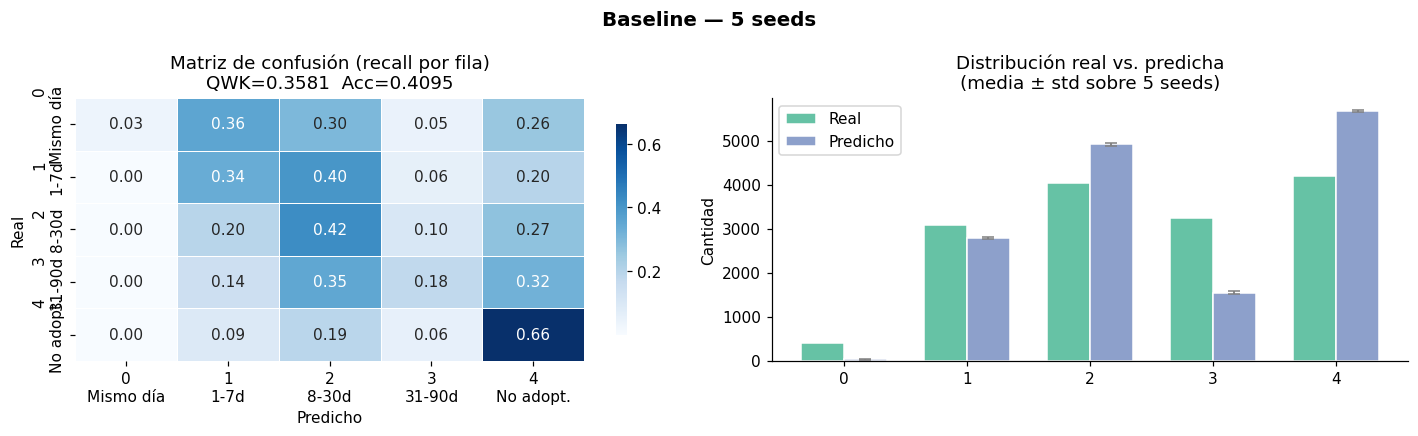

              precision    recall  f1-score   support

  0-MismoDía       0.50      0.03      0.06       410
  1-1ªSemana       0.37      0.34      0.35      3083
    2-1erMes       0.34      0.42      0.38      4029
 3-2do3erMes       0.40      0.18      0.25      3236
  4-NoAdopt.       0.49      0.66      0.56      4193

    accuracy                           0.41     14951
   macro avg       0.42      0.33      0.32     14951
weighted avg       0.41      0.41      0.39     14951



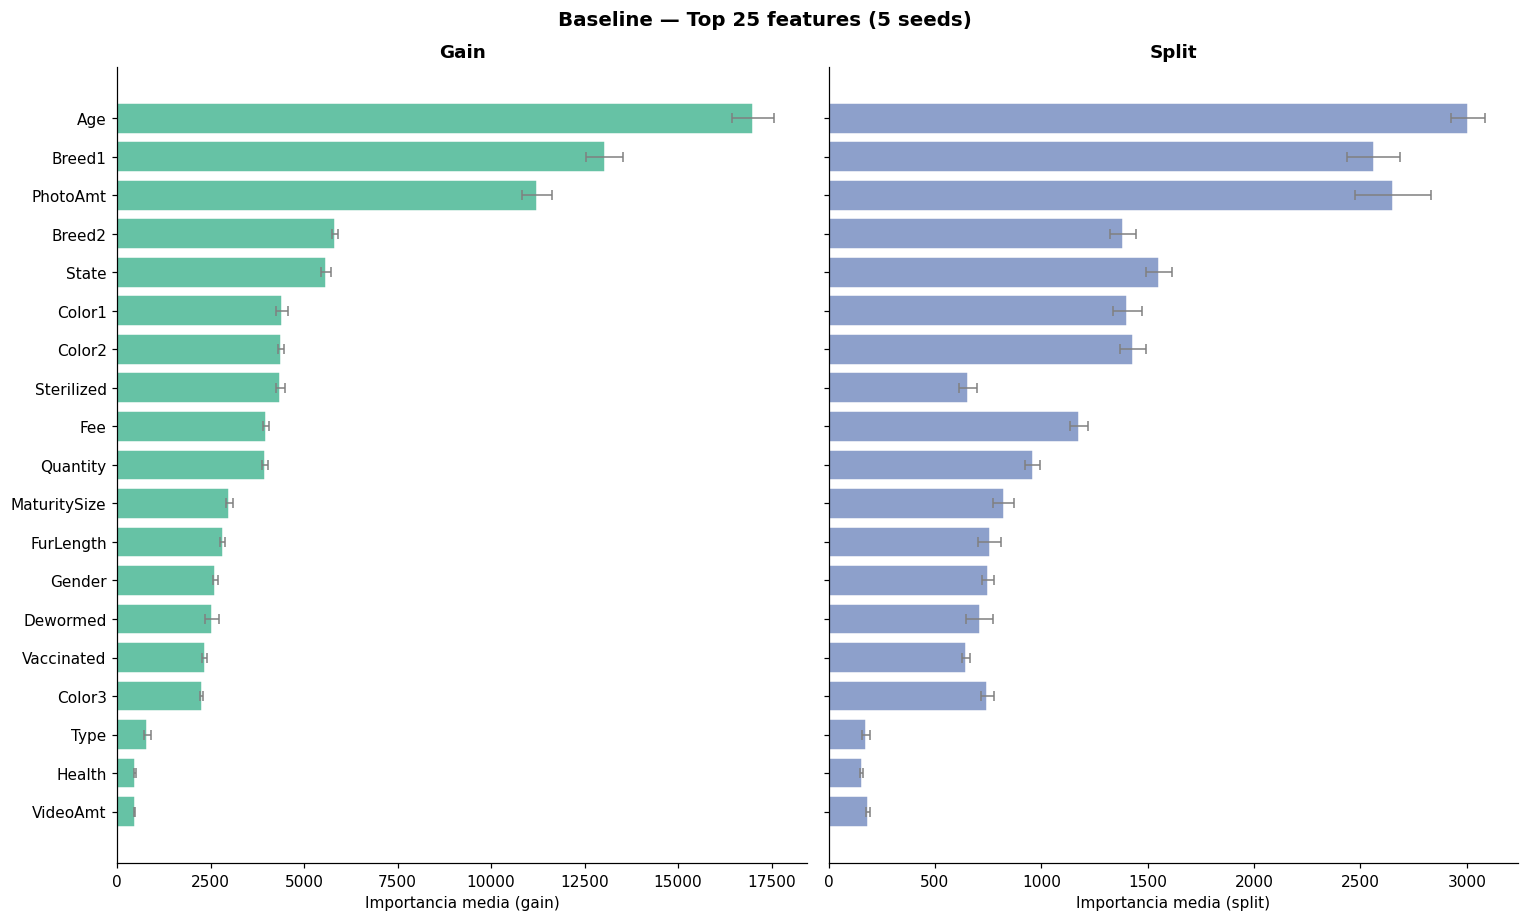

In [8]:
plot_results(y, [r['oof_preds'] for r in exp00a_baseline], title='Baseline — 5 seeds')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp00a_baseline])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Baseline — Top 25 features (5 seeds)')


El modelo base presenta un sesgo hacia las clases mayoritarias: tiende a etiquetar con los valores 2 y 4. No suele clasificar mascotas con rescates en el mismo día, pero cuando lo hace acierta en el 50% de los casos (precision).
Las tres variables más relevantes son Edad (donde los cachorros tienen mayor probabilidad de adopciones veloces), Raza principal (puede haber razas más demandadas que otras) y Cantidad de fotos (tal vez algún factor de ternura).

## 3b Baseline con definición de categóricas
Se evaluará como definición preliminar si utilizar el parámetro de cat_features de LGBM mejora la predicción.

In [9]:
categoricals = ['Type', 'Gender', 'Color1', 'Color2', 'Color3',
    'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized',
    'Health', 'State', 'Breed1', 'Breed2']

exp00b_baseline = []

for seed in SEEDS:
    r = run_cv(
        X=X_base,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp00b_baseline{seed}',
        verbose=False,  # para no saturar la salida
    )
    exp00b_baseline.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp00b_baseline, name='exp00b_baseline')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp00b_baseline]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")

delta(exp00b_baseline, exp00a_baseline)

Seed 310019: QWK = 0.3506 ± 0.0145
Seed 320009: QWK = 0.3590 ± 0.0181
Seed 330017: QWK = 0.3606 ± 0.0056
Seed 340007: QWK = 0.3546 ± 0.0160
Seed 350029: QWK = 0.3525 ± 0.0150

── Resumen sobre 5 semillas ──
QWK medio:  0.3555
QWK std:    0.0038
QWK rango:  [0.3506, 0.3606]
  Referencia : QWK = 0.3532 ± 0.0097  (n=25 folds)
  Nuevo      : QWK = 0.3555 ± 0.0150  (n=25 folds)
  ΔQWK       : +0.0022


0.0022263750801799764

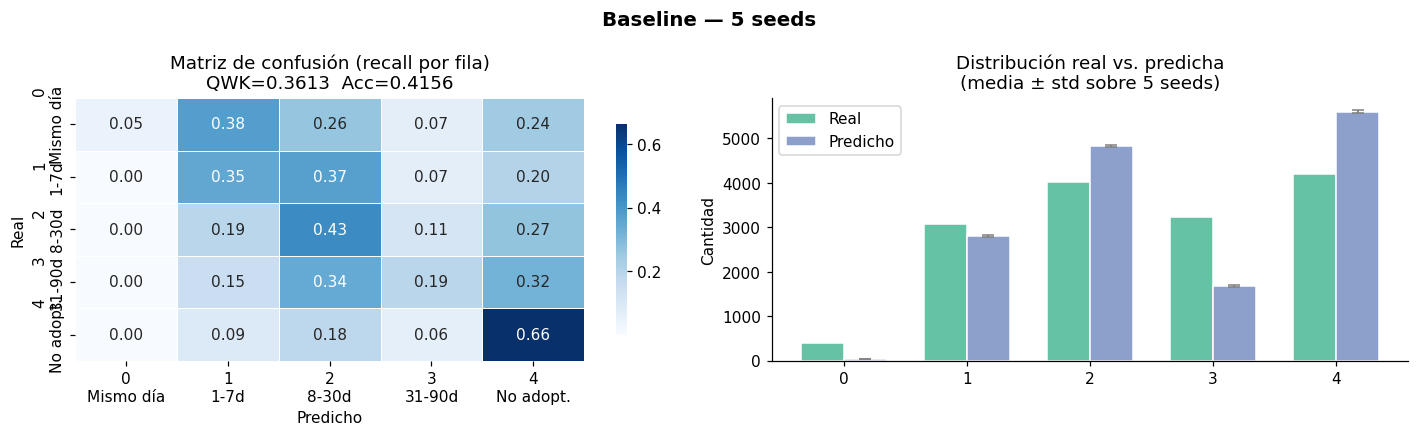

              precision    recall  f1-score   support

  0-MismoDía       0.54      0.05      0.09       410
  1-1ªSemana       0.38      0.35      0.36      3083
    2-1erMes       0.35      0.43      0.39      4029
 3-2do3erMes       0.39      0.19      0.26      3236
  4-NoAdopt.       0.49      0.66      0.57      4193

    accuracy                           0.42     14951
   macro avg       0.43      0.34      0.33     14951
weighted avg       0.41      0.42      0.40     14951



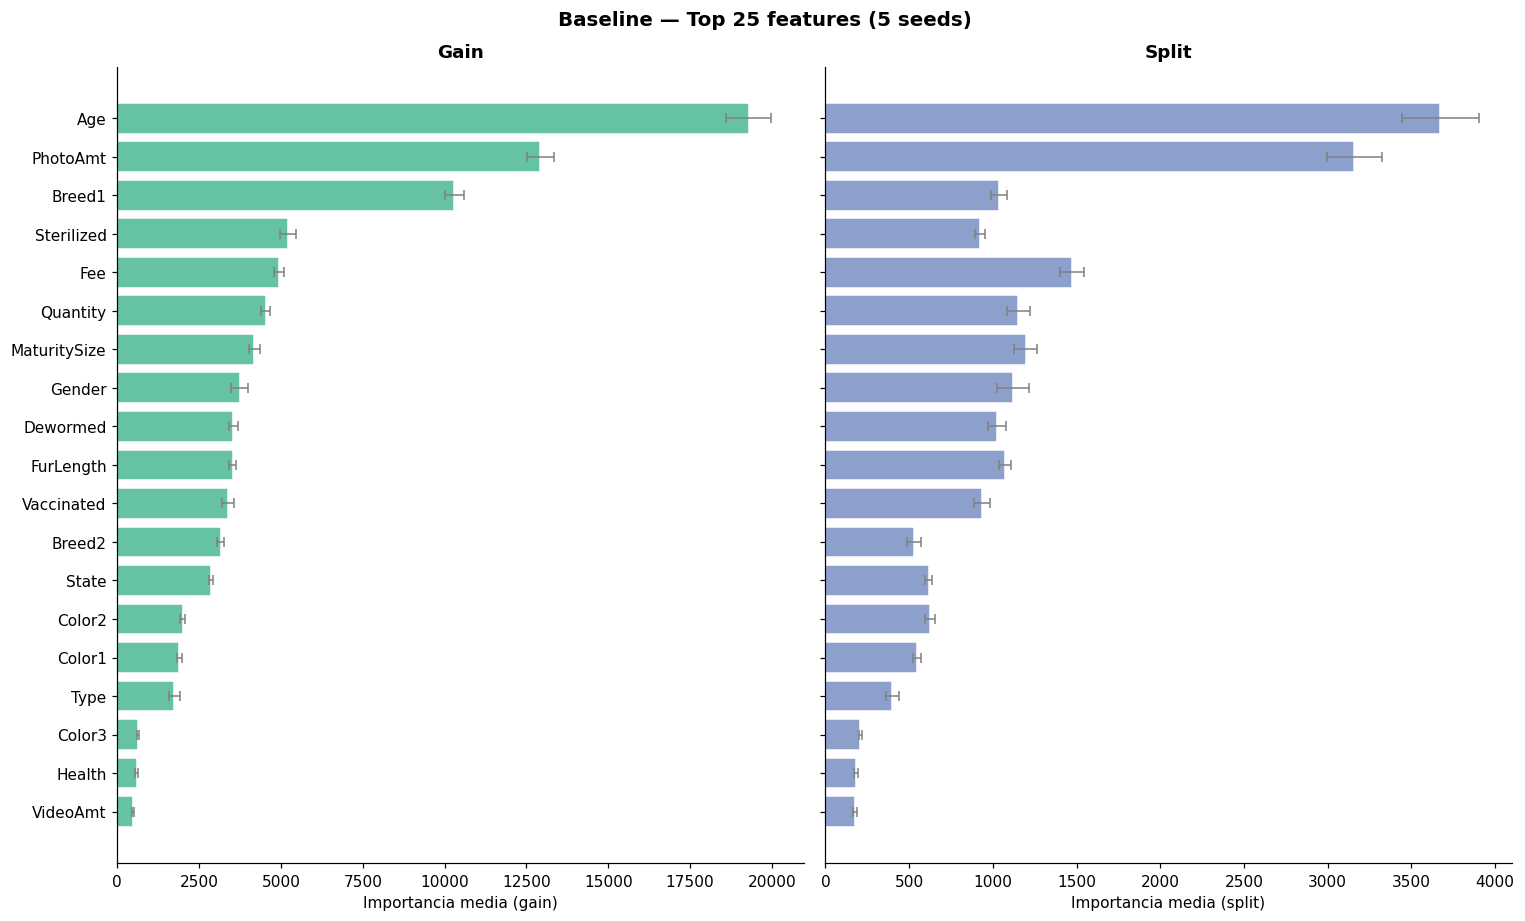

In [10]:
plot_results(y, [r['oof_preds'] for r in exp00b_baseline], title='Baseline — 5 seeds')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp00b_baseline])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Baseline — Top 25 features (5 seeds)')


Con una mejora leve en todas las métricas, y una disminución en el desvío estándar de los folds de CV, se observa que definir las variables categóricas según el parámetro de la librería de LGBM mejora la performance.
Las variables numéricas cobran más importancia dado que el modelo utiliza las categóricas con más eficiencia.

---
# 4. Feature Engineering iterativo

1. Se calculan las features **seguras** sobre todo el dataset `df_fe`
2. Se definen las features del experimento con `CURRENT_FEATURES_XX = CURRENT_FEATURES + [nuevas_features]`
3. Se llama a la función `run_cv(X, y, params, ...)` con los parámetros que correspondan
4. Si mejora → se actualiza `CURRENT_FEATURES = CURRENT_FEATURES_XX`

In [11]:
# ── Estado acumulado ──────────────────────────────────────────────────────────
# CURRENT_FEATURES es la lista de features del mejor experimento hasta ahora.
# Cada bloque propone CURRENT_FEATURES_XX y lo incorpora solo si mejora el QWK.
CURRENT_FEATURES = BASELINE_FEATURES.copy()
df_fe = df.copy()   # DataFrame de trabajo; acumula todas las features nuevas
best_result = exp00b_baseline  # resultado del mejor experimento hasta ahora

print('FE iterativo listo.')

FE iterativo listo.


## 4.1a Variables de Name y Description

Extracción de señales simples del texto:
- Si tiene o no Nombre y Descripción.
- La cantidad de caracteres del Nombre y la Descripción.
- La cantidad de palabras de la Descripción.
- Un ratio entre cantidad de caracteres y de palabras, con la expectativa de que palabras más largas implican descripciones más complejas/elaboradas.

In [12]:
def fun_exp41a_name_desc(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Señales de Name ───────────────────────────────────────────────────────
    df['HasName']    = df['Name'].notna().astype(int)
    df['NameLength'] = df['Name'].str.len().fillna(0)

    # ── Señales de Description ────────────────────────────────────────────────
    df['HasDesc']       = df['Description'].notna().astype(int)
    df['DescLength']    = df['Description'].str.len().fillna(0)
    df['DescWordCount'] = df['Description'].fillna('').str.split().str.len()
    df['DescRatio']     = df['DescLength'] / df['DescWordCount'].replace(0, np.nan)

    return df

df_fe = fun_exp41a_name_desc(df_fe)

NEW_VAR = ['HasName', 
          'NameLength', 
          'HasDesc', 
          'DescLength', 
          'DescWordCount', 
          'DescRatio']

CURRENT_FEATURES_41a = CURRENT_FEATURES + NEW_VAR
X_41a = df_fe[CURRENT_FEATURES_41a]

print(f'Features nuevas (4.1a): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41a)}')
print('\n' + '='*55)
print('EXPERIMENTO 1a: + Señales de Name y Description')
print('='*55)

exp41a_name_desc = []

for seed in SEEDS:
    r = run_cv(
        X=X_41a,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp41_name_desc{seed}',
        verbose=False, 
    )
    exp41a_name_desc.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41a_name_desc, name='exp41a_name_desc')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41a_name_desc]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41a_name_desc, best_result)

Features nuevas (4.1a): ['HasName', 'NameLength', 'HasDesc', 'DescLength', 'DescWordCount', 'DescRatio']
Total features: 25

EXPERIMENTO 1a: + Señales de Name y Description
Seed 310019: QWK = 0.3554 ± 0.0217
Seed 320009: QWK = 0.3609 ± 0.0125
Seed 330017: QWK = 0.3657 ± 0.0111
Seed 340007: QWK = 0.3603 ± 0.0171
Seed 350029: QWK = 0.3604 ± 0.0145

── Resumen sobre 5 semillas ──
QWK medio:  0.3606
QWK std:    0.0032
QWK rango:  [0.3554, 0.3657]
  Referencia : QWK = 0.3555 ± 0.0150  (n=25 folds)
  Nuevo      : QWK = 0.3606 ± 0.0162  (n=25 folds)
  ΔQWK       : +0.0051


0.005088606389478834

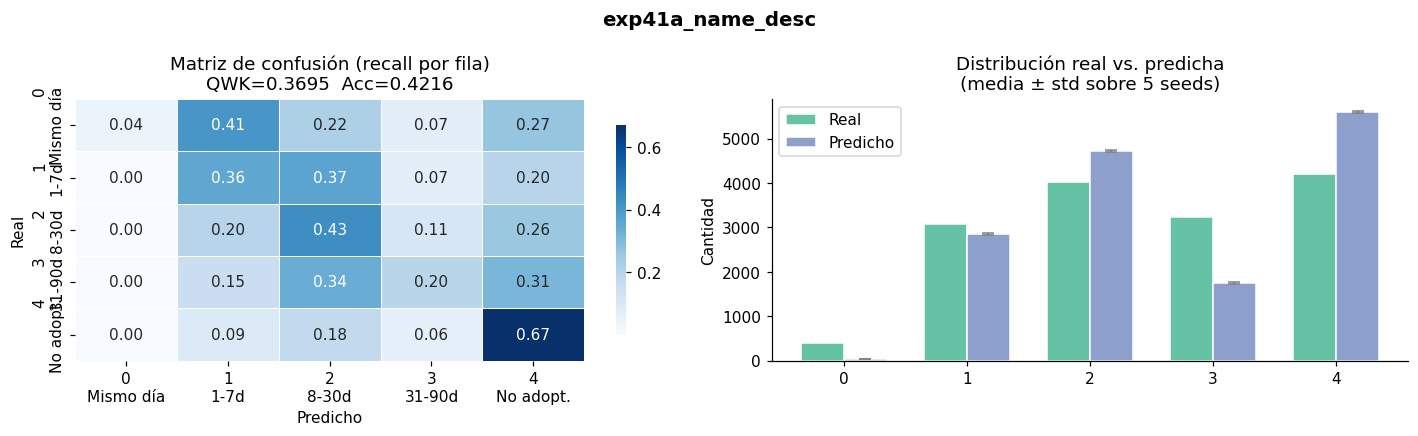

              precision    recall  f1-score   support

  0-MismoDía       0.62      0.04      0.07       410
  1-1ªSemana       0.37      0.36      0.37      3083
    2-1erMes       0.36      0.43      0.39      4029
 3-2do3erMes       0.40      0.20      0.26      3236
  4-NoAdopt.       0.50      0.67      0.58      4193

    accuracy                           0.42     14951
   macro avg       0.45      0.34      0.33     14951
weighted avg       0.42      0.42      0.40     14951



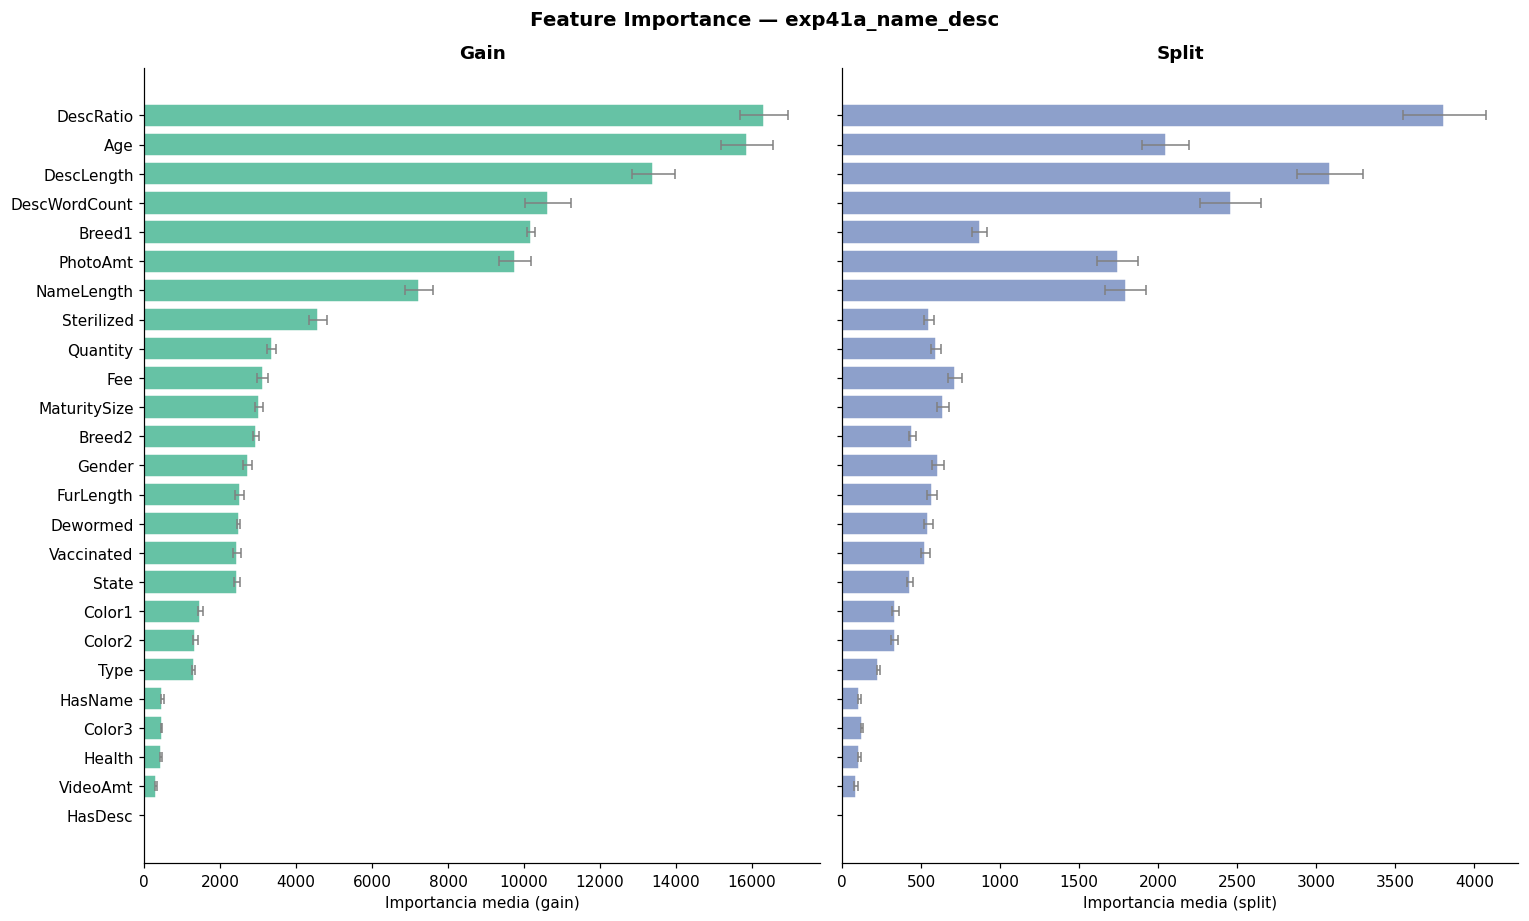

In [13]:
plot_results(y, [r['oof_preds'] for r in exp41a_name_desc], title='exp41a_name_desc')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp41a_name_desc])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp41a_name_desc')


El QWK mejora, aunque aumenta el desvío estándar lo que indica mayor inestabilidad entre folds. Sin embargo, hay tres variables que alcanzan el top 5 de Feature Importance según Ganancia y Split, todas derivadas de la Descripción.
Por el contrario, las variables que identifican nombres o descripciones vacíos no aportan mucho valor. Se realizará un segundo experimento quitando las variables de HasName y HasDesc para evaluar si esto mejora la estabilidad.

In [14]:
NEW_VAR = [#'HasName', 
          'NameLength', 
          #'HasDesc',
          'DescLength', 
          'DescWordCount', 
          'DescRatio']

CURRENT_FEATURES_41adesc = CURRENT_FEATURES + NEW_VAR
X_41adesc = df_fe[CURRENT_FEATURES_41adesc]

print(f'Features nuevas (4.1adesc): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41adesc)}')
print('\n' + '='*55)
print('EXPERIMENTO 1a: + Señales de Description')
print('='*55)

exp41a_desc = []

for seed in SEEDS:
    r = run_cv(
        X=X_41adesc,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp41a_desc{seed}',
        verbose=False,  # para no saturar la salida
    )
    exp41a_desc.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41a_desc, name='exp41a_desc')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41a_desc]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41a_desc, best_result)

Features nuevas (4.1adesc): ['NameLength', 'DescLength', 'DescWordCount', 'DescRatio']
Total features: 23

EXPERIMENTO 1a: + Señales de Description
Seed 310019: QWK = 0.3534 ± 0.0246
Seed 320009: QWK = 0.3582 ± 0.0133
Seed 330017: QWK = 0.3670 ± 0.0095
Seed 340007: QWK = 0.3539 ± 0.0188
Seed 350029: QWK = 0.3642 ± 0.0113

── Resumen sobre 5 semillas ──
QWK medio:  0.3593
QWK std:    0.0054
QWK rango:  [0.3534, 0.3670]
  Referencia : QWK = 0.3555 ± 0.0150  (n=25 folds)
  Nuevo      : QWK = 0.3593 ± 0.0173  (n=25 folds)
  ΔQWK       : +0.0039


0.003854293438740608

El QWK disminuye suavemente respecto del experimento original. Se incorporarán todas las variables derivadas de Nombre y Descripción.

In [15]:

CURRENT_FEATURES = CURRENT_FEATURES_41a
best_result = exp41a_name_desc

## 4.1b Variables sobre fotos y videos.


Transformación de las variables de PhotoAmt y VideoAmt:
- Si tiene Foto o Video.
- Una transformación logarítmica de las variables de PhotoAmt y VideoAmt, que presentan asimetría.

In [16]:
print(f'Asimetría de PhotoAmt: {df_fe["PhotoAmt"].skew():.4f}')
print(f'Asimetría de VideoAmt: {df_fe["VideoAmt"].skew():.4f}')

Asimetría de PhotoAmt: 2.8594
Asimetría de VideoAmt: 9.4450


In [17]:
def fun_exp41b_photo_vid(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['HasPhoto']    = (df['PhotoAmt'].fillna(0) > 0).astype(int)
    df['HasVideo']    = (df['VideoAmt'].fillna(0) > 0).astype(int)
    df['PhotoAmt_log'] = np.log1p(df['PhotoAmt'])
    df['VideoAmt_log'] = np.log1p(df['VideoAmt'])

    return df

df_fe = fun_exp41b_photo_vid(df_fe)

NEW_VAR = ['HasPhoto', 
          'HasVideo', 
          'PhotoAmt_log',
          'VideoAmt_log'
         ]

features_sin_originales = [f for f in CURRENT_FEATURES 
                            if f not in ['PhotoAmt', 
                                         'VideoAmt'
                                         ]]

CURRENT_FEATURES_41b_reemplazo = features_sin_originales + NEW_VAR
X_41brep = df_fe[CURRENT_FEATURES_41b_reemplazo]

print(f'Features nuevas (4.1b): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41b_reemplazo)}')
print('\n' + '='*55)
print('EXPERIMENTO 1b: + Videos y fotos con reemplazo')
print('='*55)


exp41b_photo_vid = []

for seed in SEEDS:
    r = run_cv(
        X=X_41brep,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp41b_photo_vid{seed}',
        verbose=False, 
    )
    exp41b_photo_vid.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41b_photo_vid, name='exp41b_photo_vid')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41b_photo_vid]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41b_photo_vid, best_result)

Features nuevas (4.1b): ['HasPhoto', 'HasVideo', 'PhotoAmt_log', 'VideoAmt_log']
Total features: 27

EXPERIMENTO 1b: + Videos y fotos con reemplazo
Seed 310019: QWK = 0.3599 ± 0.0168
Seed 320009: QWK = 0.3602 ± 0.0139
Seed 330017: QWK = 0.3640 ± 0.0113
Seed 340007: QWK = 0.3578 ± 0.0157
Seed 350029: QWK = 0.3588 ± 0.0090

── Resumen sobre 5 semillas ──
QWK medio:  0.3602
QWK std:    0.0021
QWK rango:  [0.3578, 0.3640]
  Referencia : QWK = 0.3606 ± 0.0162  (n=25 folds)
  Nuevo      : QWK = 0.3602 ± 0.0138  (n=25 folds)
  ΔQWK       : -0.0004


-0.0004042478081416334

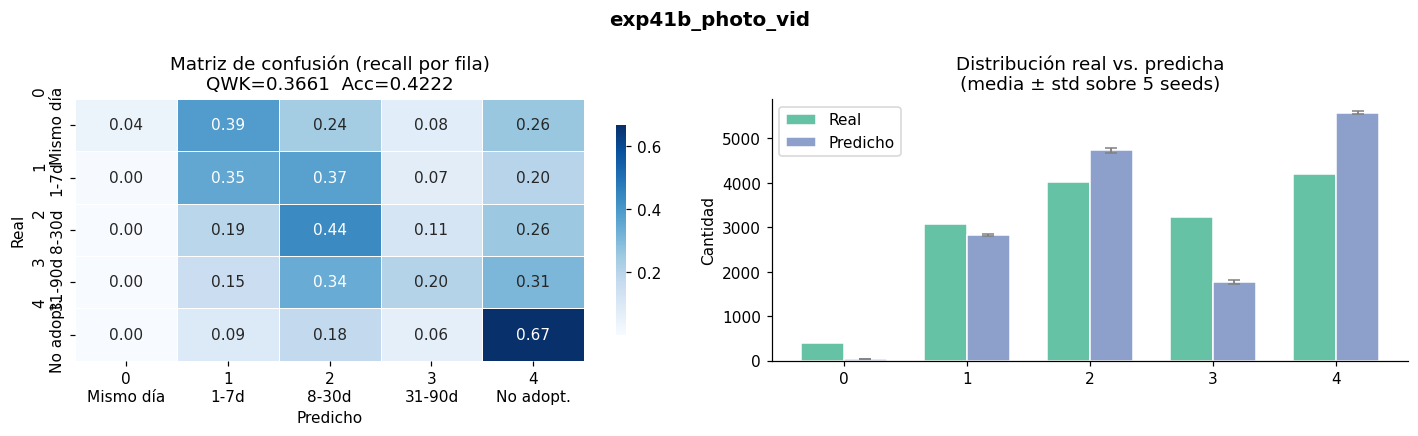

              precision    recall  f1-score   support

  0-MismoDía       0.47      0.04      0.07       410
  1-1ªSemana       0.37      0.35      0.36      3083
    2-1erMes       0.36      0.44      0.40      4029
 3-2do3erMes       0.40      0.20      0.27      3236
  4-NoAdopt.       0.50      0.67      0.57      4193

    accuracy                           0.42     14951
   macro avg       0.42      0.34      0.34     14951
weighted avg       0.42      0.42      0.40     14951



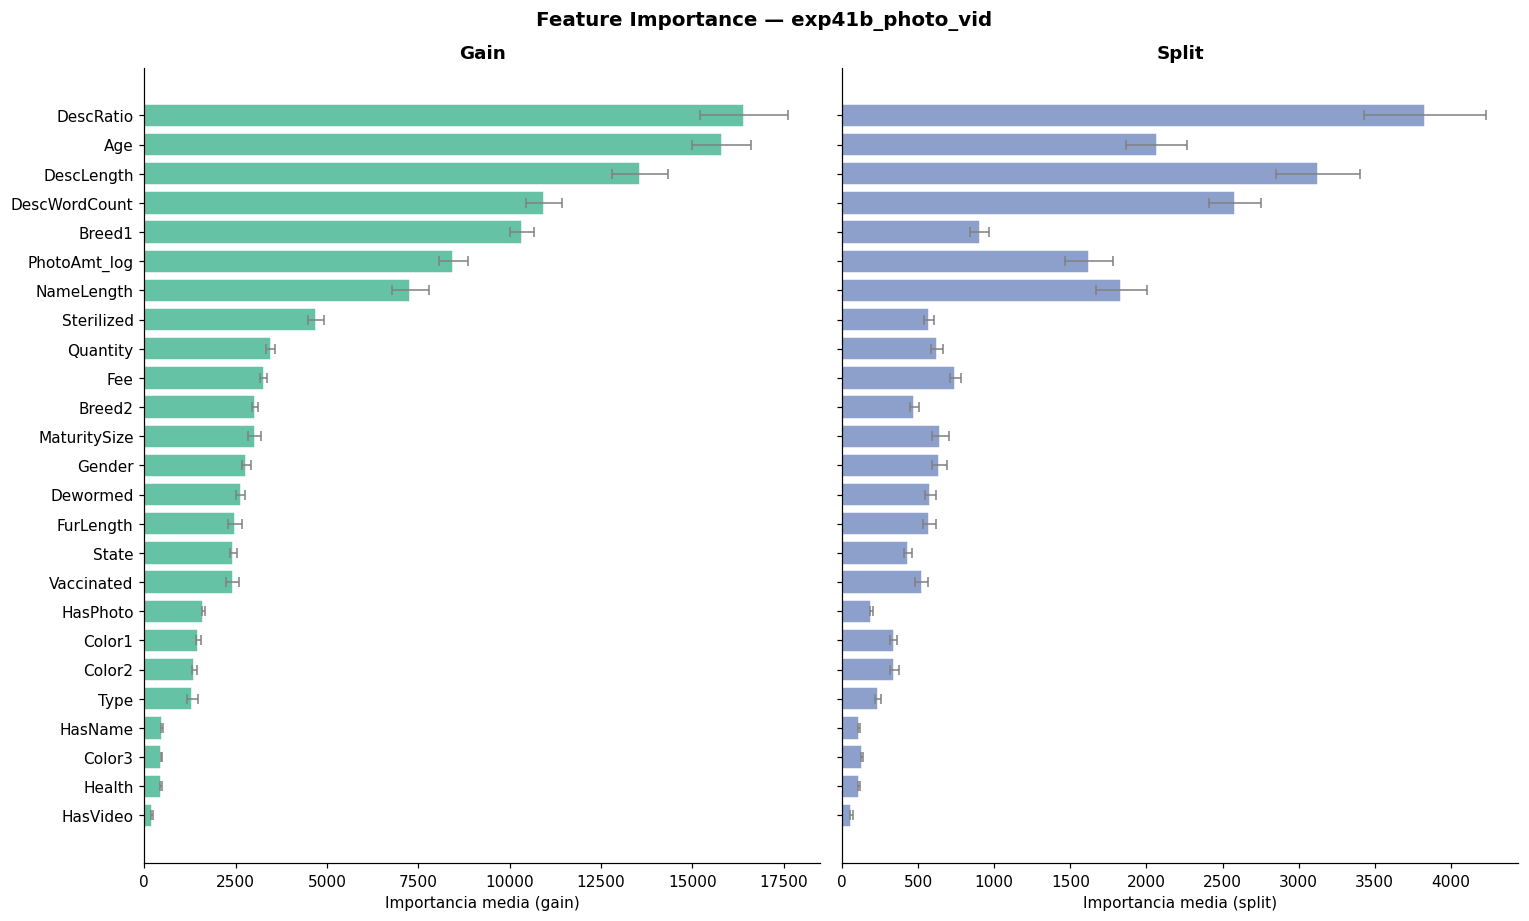

In [18]:
plot_results(y, [r['oof_preds'] for r in exp41b_photo_vid], title='exp41b_photo_vid')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp41b_photo_vid])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp41b_photo_vid')


Las transformaciones sobre estas variables no generan mejoras. Respecto de las flags (HasPhoto, HasVideo), LGBM realiza splits con umbrales de corte optimizados por ganancia, por lo que es de esperar que no mejoren las métricas. No se incorporarán.

## 4.1c Variables derivadas del Estado

La variable de Estado es una categórica con cardinalidad relativamente alta. Se incorpora información externa sobre esta variable para aportar contexto:
- Población en miles de cada uno de los Estados, según información del Departamento de Estadísticas de Malasia.[https://open.dosm.gov.my/data-catalogue/population_malaysia]. 
- Ingreso mediano de cada uno de los Estados, según el Departamento de Estadísticas de Malasia.[https://open.dosm.gov.my/data-catalogue/hh_income_state]
- Matrimonios absolutos por año y Rate de matrimonio por año de cada uno de los Estados. [https://open.dosm.gov.my/data-catalogue/marriages_state] 

In [19]:
malaysia_pop = pd.read_parquet('https://storage.dosm.gov.my/population/population_state.parquet')
#malaysia_pop = pd.read_parquet('/kaggle/input/datasets/tarmencello/state-metrics/population_state.parquet')
malaysia_pop = malaysia_pop[(malaysia_pop['ethnicity'] == 'overall') & 
                            (malaysia_pop['age'] == 'overall') & 
                            (malaysia_pop['sex'] == 'both') & 
                            (malaysia_pop['date'] == datetime.date(2022, 1, 1))][['state', 'population']]

malaysia_inc = pd.read_parquet('https://storage.dosm.gov.my/hies/hh_income_state.parquet')
#malaysia_inc = pd.read_parquet('/kaggle/input/datasets/tarmencello/state-metrics/hh_income_state.parquet')
malaysia_inc = malaysia_inc[malaysia_inc['date'] == datetime.date(2022, 1, 1)][['state', 'income_median']]

malaysia_mar = pd.read_parquet('https://storage.dosm.gov.my/demography/marriages_state.parquet')
#malaysia_mar = pd.read_parquet('/kaggle/input/datasets/tarmencello/state-metrics/marriages_state.parquet')
malaysia_mar = malaysia_mar[malaysia_mar['date'] == datetime.date(2022, 1, 1)]
malaysia_mar = malaysia_mar[['state', 'rate']].rename(columns={'rate': 'marriage_rate'})
malaysia_mar = malaysia_mar.groupby('state').sum()

El dataset del DOSM separa el Territorio Federal de Putrajaya para reportar las estadísticas. Sin embargo el dataset de etiquetas de PetFinder no lo incluye entre los Estados registrados. Por eso se incorporará al Estado de Selangor (usualmente se lo considera como parte debido a proximidad geográfica), recalculando las métricas con promedios ponderados por población.

In [20]:
malaysia_stats = malaysia_pop.merge(malaysia_inc, on='state').merge(malaysia_mar, on='state')
malaysia_stats = malaysia_stats.rename(columns = {'state' : 'StateName'})

mapping = {
    'W.P. Kuala Lumpur': 'Kuala Lumpur',
    'W.P. Labuan': 'Labuan',
    'W.P. Putrajaya': 'Selangor'
}

malaysia_stats['StateName'] = malaysia_stats['StateName'].replace(mapping)

malaysia_stats['w_income_median'] = malaysia_stats['income_median'] * malaysia_stats['population']
malaysia_stats['w_marriage_rate'] = malaysia_stats['marriage_rate'] * malaysia_stats['population']

agg_stats = malaysia_stats.groupby('StateName').agg({
    'population': 'sum',
    'w_income_median': 'sum',
    'w_marriage_rate': 'sum'
}).reset_index()

agg_stats['income_median'] = agg_stats['w_income_median'] / agg_stats['population']
agg_stats['marriage_rate'] = agg_stats['w_marriage_rate'] / agg_stats['population']

malaysia_stats = agg_stats[['StateName', 'population', 'income_median', 'marriage_rate']]

malaysia_stats = states.merge(malaysia_stats, on='StateName', how= 'outer')
print(malaysia_stats.sort_values('population', ascending=False))


    StateID        StateName  population  income_median  marriage_rate
13    41326         Selangor      7167.3    9984.191662      44.994316
0     41336            Johor      4028.3         6879.0      46.900000
11    41345            Sabah      3414.9         4577.0      33.800000
8     41330            Perak      2514.4         4494.0      49.600000
12    41342          Sarawak      2473.5         4978.0      49.000000
1     41325            Kedah      2163.1         4402.0      57.100000
3     41401     Kuala Lumpur      1961.2        10234.0      45.600000
2     41367         Kelantan      1830.6         3614.0      67.700000
10    41327     Pulau Pinang      1740.9         6502.0      44.300000
7     41335           Pahang      1614.3         4753.0      47.100000
6     41332  Negeri Sembilan      1207.9         5226.0      51.700000
14    41361       Terengganu      1186.6         5878.0      58.900000
5     41324           Melaka      1008.6         6210.0      49.800000
9     

In [21]:
def fun_exp41c_states(df: pd.DataFrame, malaysia_stats: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    stats_idx = malaysia_stats.set_index('StateID')
    df['StatePop']          = df['State'].map(stats_idx['population'].to_dict())
    df['StateIncomeMedian'] = df['State'].map(stats_idx['income_median'].to_dict())
    df['StateMarriageRate'] = df['State'].map(stats_idx['marriage_rate'].to_dict())

    return df

df_fe = fun_exp41c_states(df_fe, malaysia_stats)

NEW_VAR = ['StatePop', 
          'StateIncomeMedian',
          'StateMarriageRate'
         ]

CURRENT_FEATURES_41c = CURRENT_FEATURES + NEW_VAR
X_41c = df_fe[CURRENT_FEATURES_41c]

print(f'Features nuevas (4.1c): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41c)}')
print('\n' + '='*55)
print('EXPERIMENTO 1c: + Contexto de Estados')
print('='*55)


exp41c_states = []

for seed in SEEDS:
    r = run_cv(
        X=X_41c,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp41c_states{seed}',
        verbose=False,  
    )
    exp41c_states.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41c_states, name='exp41c_states')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41c_states]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41c_states, best_result)

Features nuevas (4.1c): ['StatePop', 'StateIncomeMedian', 'StateMarriageRate']
Total features: 28

EXPERIMENTO 1c: + Contexto de Estados
Seed 310019: QWK = 0.3663 ± 0.0218
Seed 320009: QWK = 0.3594 ± 0.0210
Seed 330017: QWK = 0.3634 ± 0.0065
Seed 340007: QWK = 0.3616 ± 0.0138
Seed 350029: QWK = 0.3562 ± 0.0099

── Resumen sobre 5 semillas ──
QWK medio:  0.3614
QWK std:    0.0034
QWK rango:  [0.3562, 0.3663]
  Referencia : QWK = 0.3606 ± 0.0162  (n=25 folds)
  Nuevo      : QWK = 0.3614 ± 0.0162  (n=25 folds)
  ΔQWK       : +0.0008


0.0008209416353481269

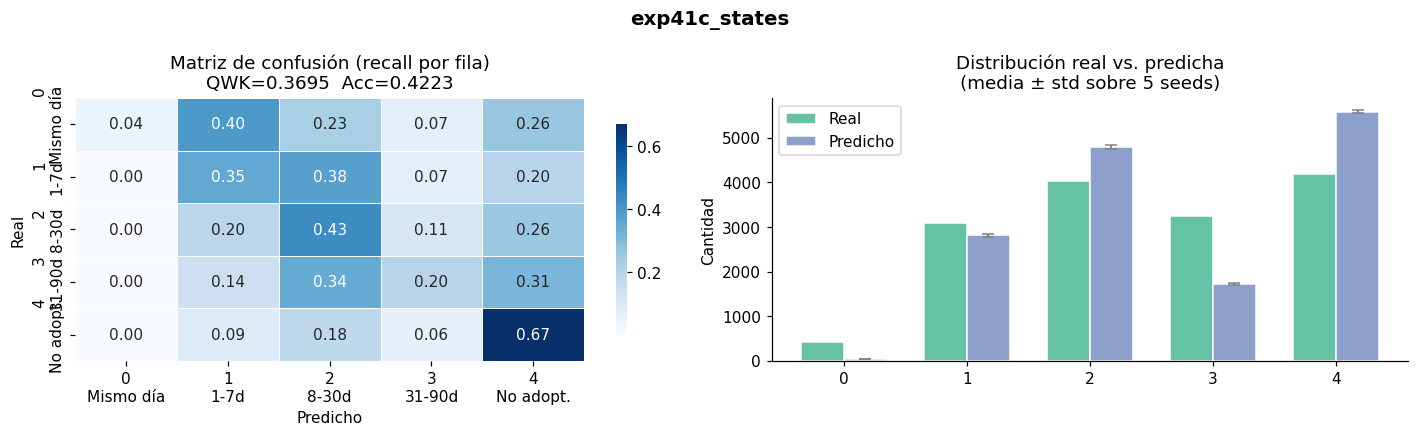

              precision    recall  f1-score   support

  0-MismoDía       0.55      0.04      0.07       410
  1-1ªSemana       0.38      0.35      0.36      3083
    2-1erMes       0.36      0.43      0.39      4029
 3-2do3erMes       0.41      0.20      0.27      3236
  4-NoAdopt.       0.50      0.67      0.58      4193

    accuracy                           0.42     14951
   macro avg       0.44      0.34      0.34     14951
weighted avg       0.42      0.42      0.40     14951



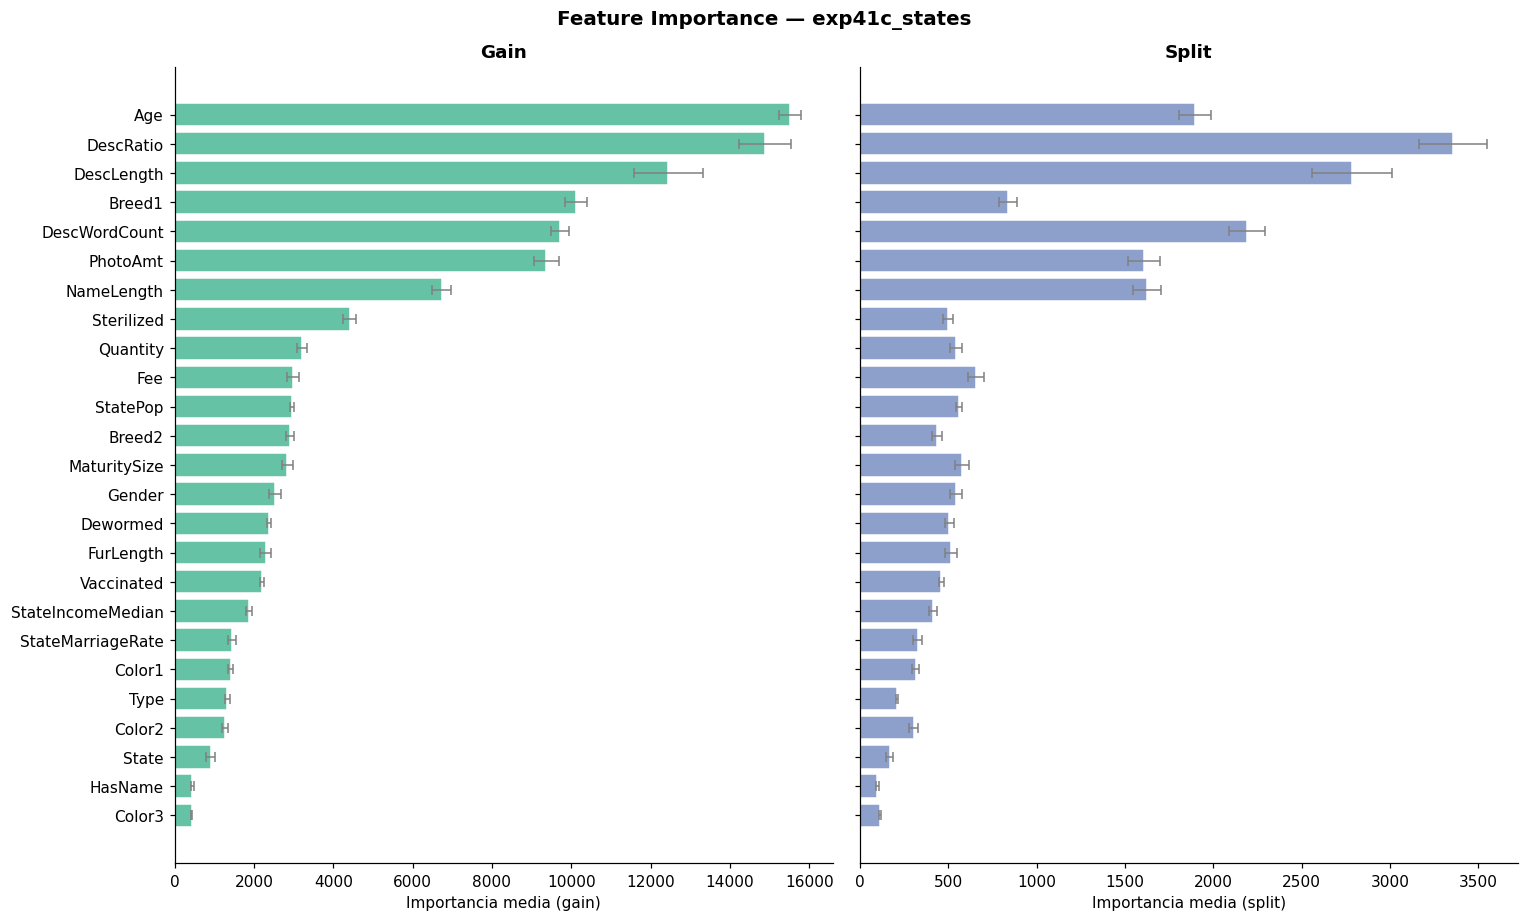

In [22]:
plot_results(y, [r['oof_preds'] for r in exp41c_states], title='exp41c_states')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp41c_states])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp41c_states')


Las variables que aportan contexto sobre los Estados en que se adoptan los animales parecen tener un ligero valor. Particularmente la variable que reporta la Población. Se realizaron experimentos aislando las variables, pero se observó que son complementarias entre sí.
Se replicará el experimento eliminando la variable de origen para identificar si la performance es mejor, o si las variables son complementarias.

In [23]:
features_sin_originales = [f for f in CURRENT_FEATURES
                            if f not in ['State']]

categoricals_sin_originales = [f for f in categoricals 
                            if f not in ['State']]


CURRENT_FEATURES_41c_reemplazo = features_sin_originales + NEW_VAR
X_41c_reemplazo = df_fe[CURRENT_FEATURES_41c_reemplazo]

print(f'Features nuevas (4.1c rep): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41c_reemplazo)}')
print('\n' + '='*55)
print('EXPERIMENTO 1c: + Contexto de Estados con reemplazo')
print('='*55)

exp41c_states_reemplazo = []

for seed in SEEDS:
    r = run_cv(
        X=X_41c_reemplazo,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals_sin_originales,
        experiment_name=f'exp41c_states{seed}',
        verbose=False,  
    )
    exp41c_states_reemplazo.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41c_states_reemplazo, name='exp41c_states_reemplazo')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41c_states_reemplazo]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41c_states_reemplazo, best_result)


Features nuevas (4.1c rep): ['StatePop', 'StateIncomeMedian', 'StateMarriageRate']
Total features: 27

EXPERIMENTO 1c: + Contexto de Estados con reemplazo
Seed 310019: QWK = 0.3597 ± 0.0203
Seed 320009: QWK = 0.3623 ± 0.0149
Seed 330017: QWK = 0.3643 ± 0.0082
Seed 340007: QWK = 0.3568 ± 0.0084
Seed 350029: QWK = 0.3575 ± 0.0043

── Resumen sobre 5 semillas ──
QWK medio:  0.3601
QWK std:    0.0029
QWK rango:  [0.3568, 0.3643]
  Referencia : QWK = 0.3606 ± 0.0162  (n=25 folds)
  Nuevo      : QWK = 0.3601 ± 0.0129  (n=25 folds)
  ΔQWK       : -0.0004


-0.000420178322350806

El aporte parece ser complementario. Se mantiene la variable original y se incorporan las contextuales.

In [24]:
CURRENT_FEATURES = CURRENT_FEATURES_41c
best_result = exp41c_states

## 4.1d Variables de características del animal

Se realizan transformaciones para generar:
- Flags de características como si es de 1 sólo color, de raza pura
- Si la publicación corresponde a un grupo de animales o a uno solo.

In [25]:
def fun_exp41d_animal(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['IsFree']     = (df['Fee'] == 0).astype(int)
    df['MixedBreed'] = (
        (df['Breed2Name'].notna() & (df['Breed1'] != df['Breed2'])) |
        (df['Breed1Name'] == 'Mixed Breed') |
        (df['Breed1Name'].str.contains('Domestic', na=False))
    ).astype(int)
    df['MixedColor'] = ((df['Color2'] != 0) & df['Color2'].notna()).astype(int)
    df['IsGroup']    = (df['Quantity'] > 1).astype(int)

    return df

df_fe = fun_exp41d_animal(df_fe)

NEW_VAR = ['IsFree', 
          'MixedBreed',
          'MixedColor',
          'IsGroup'
         ]

CURRENT_FEATURES_41d = CURRENT_FEATURES + NEW_VAR
X_41d = df_fe[CURRENT_FEATURES_41d]

print(f'Features nuevas (4.1d): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41d)}')
print('\n' + '='*55)
print('EXPERIMENTO 1d: + Características del animal')
print('='*55)


exp41d_animal = []

for seed in SEEDS:
    r = run_cv(
        X=X_41d,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp41d_animal{seed}',
        verbose=False,  
    )
    exp41d_animal.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41d_animal, name='exp41d_animal')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41d_animal]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41d_animal, best_result)

Features nuevas (4.1d): ['IsFree', 'MixedBreed', 'MixedColor', 'IsGroup']
Total features: 32

EXPERIMENTO 1d: + Características del animal
Seed 310019: QWK = 0.3604 ± 0.0266
Seed 320009: QWK = 0.3609 ± 0.0170
Seed 330017: QWK = 0.3600 ± 0.0087
Seed 340007: QWK = 0.3600 ± 0.0118
Seed 350029: QWK = 0.3569 ± 0.0115

── Resumen sobre 5 semillas ──
QWK medio:  0.3596
QWK std:    0.0014
QWK rango:  [0.3569, 0.3609]
  Referencia : QWK = 0.3614 ± 0.0162  (n=25 folds)
  Nuevo      : QWK = 0.3596 ± 0.0165  (n=25 folds)
  ΔQWK       : -0.0018


-0.0017605397844421278

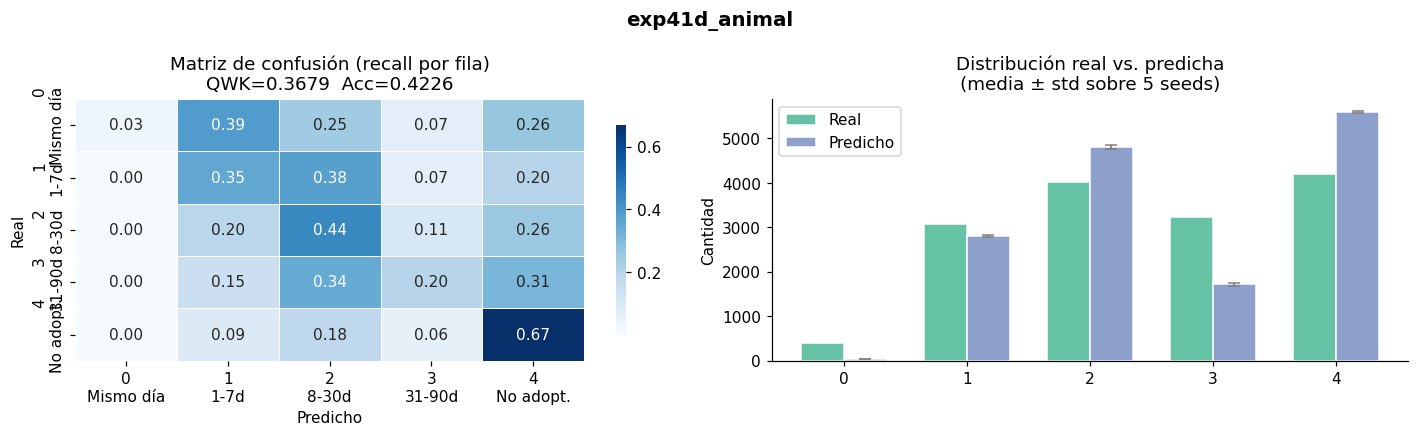

              precision    recall  f1-score   support

  0-MismoDía       0.50      0.03      0.06       410
  1-1ªSemana       0.38      0.35      0.36      3083
    2-1erMes       0.36      0.44      0.40      4029
 3-2do3erMes       0.41      0.20      0.27      3236
  4-NoAdopt.       0.50      0.67      0.57      4193

    accuracy                           0.42     14951
   macro avg       0.43      0.34      0.33     14951
weighted avg       0.42      0.42      0.40     14951



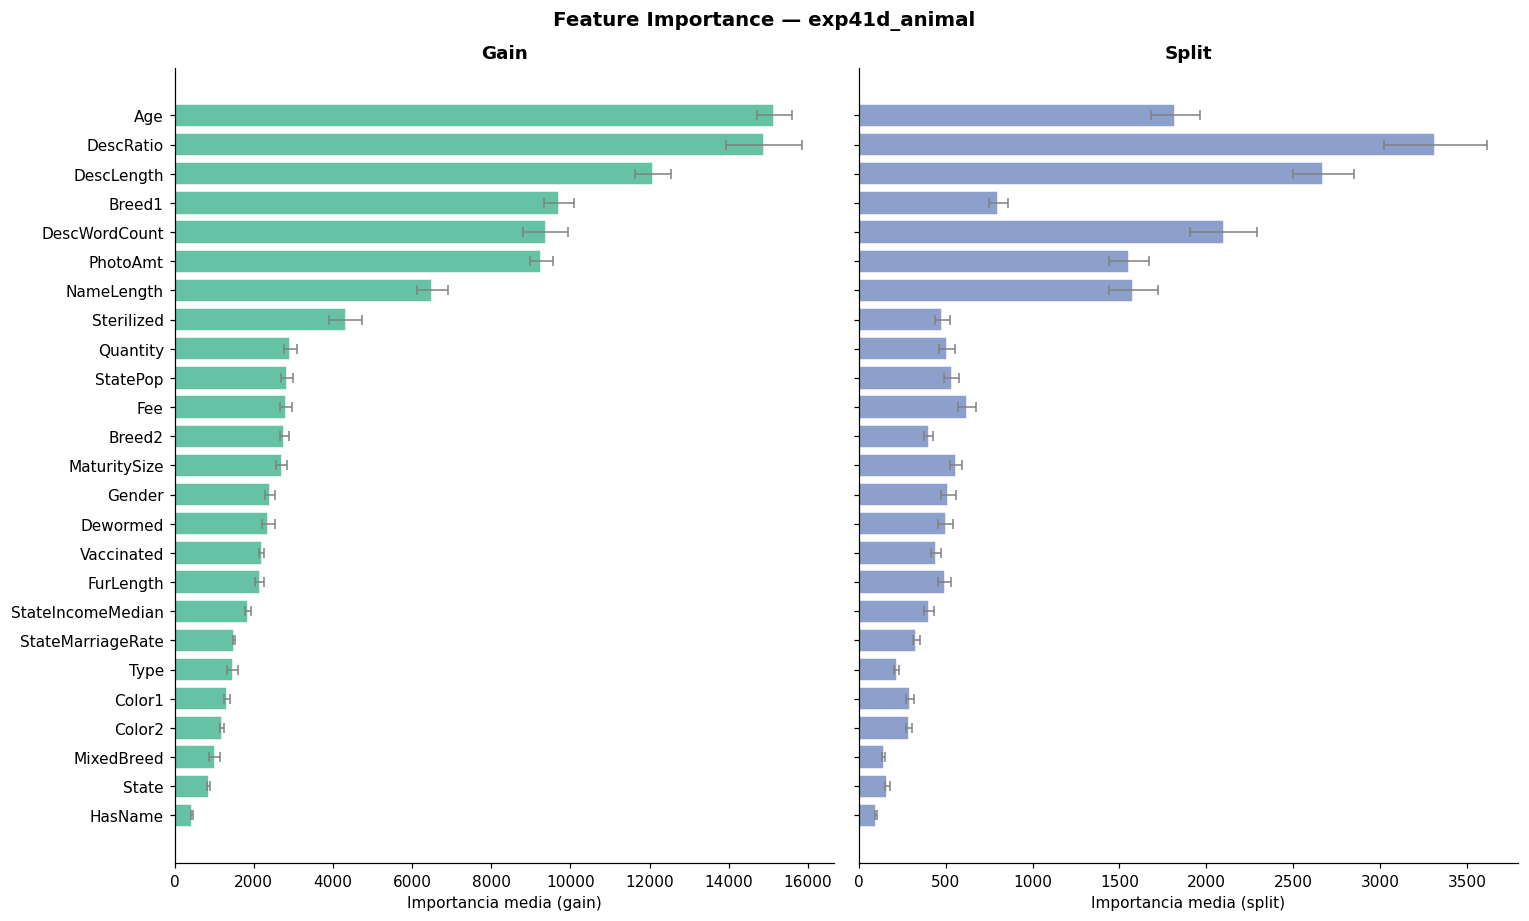

In [26]:
plot_results(y, [r['oof_preds'] for r in exp41d_animal], title='exp41d_animal')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp41d_animal])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp41d_animal')


Estas variables no mejoran la performance del modelo. Se analizarán los efectos de eliminar las variables de origen Breed2, Color2 y Color3.

In [27]:
NEW_VAR = ['MixedBreed',
          'MixedColor'
         ]

features_sin_originales = [f for f in CURRENT_FEATURES
                            if f not in ['Breed2', 'Color2', 'Color3']]

categoricals_sin_originales = [f for f in categoricals 
                            if f not in ['Breed2', 'Color2', 'Color3']]

CURRENT_FEATURES_41d_reemplazo = features_sin_originales + NEW_VAR
X_41d_reemplazo = df_fe[CURRENT_FEATURES_41d_reemplazo]

print(f'Features nuevas (4.1d): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41d_reemplazo)}')
print('\n' + '='*55)
print('EXPERIMENTO 1d: + Características del animal')
print('='*55)

exp41d_animal_rep = []

for seed in SEEDS:
    r = run_cv(
        X=X_41d_reemplazo,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals_sin_originales,
        experiment_name=f'exp41d_animal_rep{seed}',
        verbose=False,  
    )
    exp41d_animal_rep.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41d_animal_rep, name='exp41d_animal_rep')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41d_animal_rep]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41d_animal_rep, exp41d_animal)

Features nuevas (4.1d): ['MixedBreed', 'MixedColor']
Total features: 27

EXPERIMENTO 1d: + Características del animal
Seed 310019: QWK = 0.3568 ± 0.0275
Seed 320009: QWK = 0.3578 ± 0.0080
Seed 330017: QWK = 0.3573 ± 0.0122
Seed 340007: QWK = 0.3559 ± 0.0163
Seed 350029: QWK = 0.3558 ± 0.0156

── Resumen sobre 5 semillas ──
QWK medio:  0.3567
QWK std:    0.0008
QWK rango:  [0.3558, 0.3578]
  Referencia : QWK = 0.3596 ± 0.0165  (n=25 folds)
  Nuevo      : QWK = 0.3567 ± 0.0172  (n=25 folds)
  ΔQWK       : -0.0029


-0.0029055171064138463

Tampoco mejoran el modelo al eliminar las variables de origen.

## 4.1e Variables relativas a la salud del animal
Las transformaciones buscan:
- Dicotomizar la información de si el animal fue Vacunado o no, Desparasitado o no, y Esterilizado o no (donde Sí = 1 y No / No sabe = 0)
- Generar un Score de salud general, identificando las características del animal.

In [28]:
# ── Score de salud combinado ──────────────────────────────────────────────────
# Vaccinated/Dewormed/Sterilized: 1=Sí, 2=No, 3=No sabe
# Health: 1=Sano, 2=Lesión leve, 3=Lesión grave, 0=No especificado

def fun_exp41e_health(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['VaccYes']   = (df['Vaccinated'] == 1).astype(int)
    df['DewormYes'] = (df['Dewormed']   == 1).astype(int)
    df['SterYes']   = (df['Sterilized'] == 1).astype(int)
    df['Healthy']   = (df['Health']     == 1).astype(int)

    health_map = {0: np.nan, 1: 1.0, 2: 0.5, 3: 0.0}
    df['HealthScore'] = (
        (df['VaccYes'] + df['DewormYes'] + df['SterYes']) / 3 * 0.4
    ) + (df['Health'].replace(health_map) * 0.6)

    return df

df_fe = fun_exp41e_health(df_fe)

NEW_VAR = ['VaccYes', 
          'DewormYes',
          'SterYes',
          'HealthScore',
          'Healthy'
         ]

CURRENT_FEATURES_41e = CURRENT_FEATURES + NEW_VAR
X_41e = df_fe[CURRENT_FEATURES_41e]

print(f'Features nuevas (4.1e): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41e)}')
print('\n' + '='*55)
print('EXPERIMENTO 1e: + Salud del animal')
print('='*55)


exp41e_health = []

for seed in SEEDS:
    r = run_cv(
        X=X_41e,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp41e_health{seed}',
        verbose=False,  
    )
    exp41e_health.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41e_health, name='exp41e_health')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41e_health]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41e_health, best_result)

Features nuevas (4.1e): ['VaccYes', 'DewormYes', 'SterYes', 'HealthScore', 'Healthy']
Total features: 33

EXPERIMENTO 1e: + Salud del animal
Seed 310019: QWK = 0.3631 ± 0.0169
Seed 320009: QWK = 0.3603 ± 0.0179
Seed 330017: QWK = 0.3594 ± 0.0076
Seed 340007: QWK = 0.3578 ± 0.0150
Seed 350029: QWK = 0.3633 ± 0.0118

── Resumen sobre 5 semillas ──
QWK medio:  0.3608
QWK std:    0.0021
QWK rango:  [0.3578, 0.3633]
  Referencia : QWK = 0.3614 ± 0.0162  (n=25 folds)
  Nuevo      : QWK = 0.3608 ± 0.0145  (n=25 folds)
  ΔQWK       : -0.0006


-0.0005989551140749838

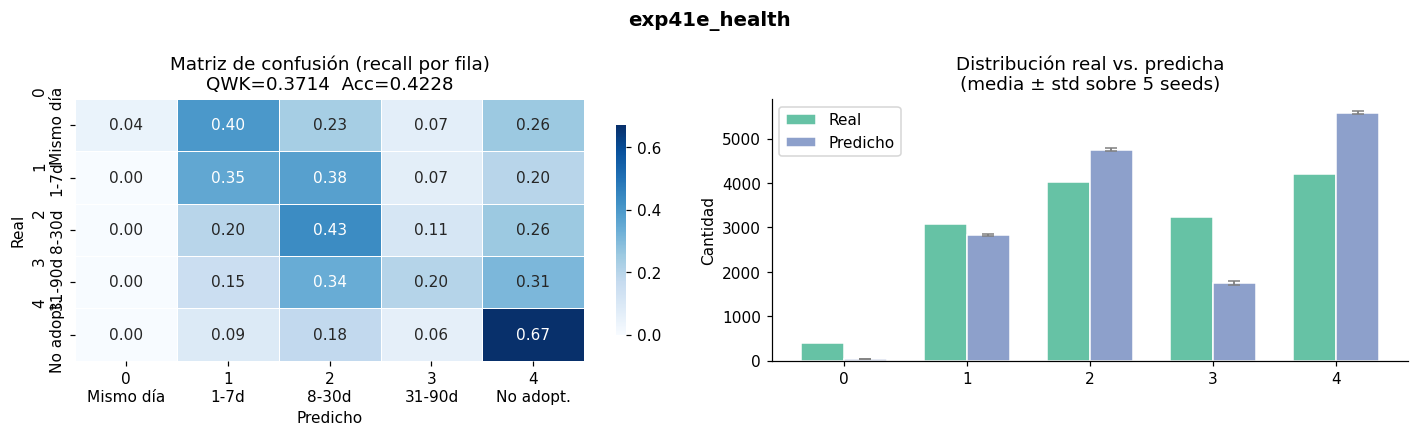

              precision    recall  f1-score   support

  0-MismoDía       0.62      0.04      0.08       410
  1-1ªSemana       0.37      0.35      0.36      3083
    2-1erMes       0.36      0.43      0.39      4029
 3-2do3erMes       0.41      0.20      0.27      3236
  4-NoAdopt.       0.51      0.67      0.58      4193

    accuracy                           0.42     14951
   macro avg       0.45      0.34      0.34     14951
weighted avg       0.42      0.42      0.40     14951



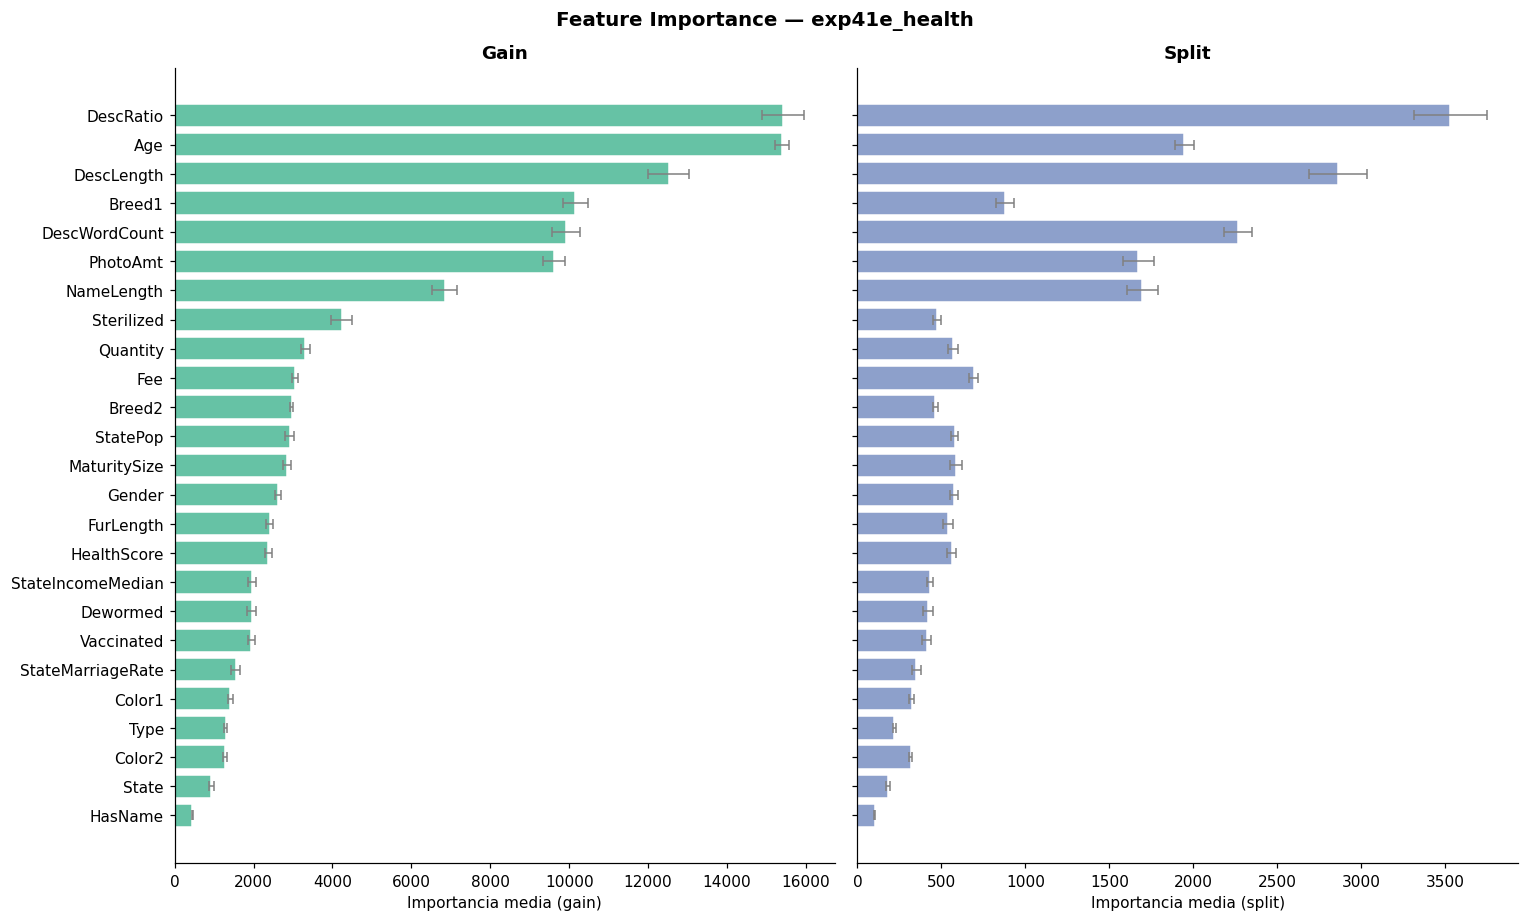

In [29]:
plot_results(y, [r['oof_preds'] for r in exp41e_health], title='exp41e_health')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp41e_health])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp41e_health')


No se observa un efecto al incorporar estas nuevas features. Se evalúa el mismo experimento pero eliminando las variables origen del modelo.

In [30]:
NEW_VAR = ['VaccYes', 
          'DewormYes',
          'SterYes',
          'HealthScore',
          'Healthy'
         ]

features_sin_originales = [f for f in CURRENT_FEATURES 
                            if f not in ['Vaccinated', 
                                         'Dewormed', 
                                         'Sterilized', 
                                         'Health']]

categoricals_sin_originales = [f for f in categoricals 
                            if f not in ['Vaccinated', 'Dewormed', 'Sterilized', 'Health']]


CURRENT_FEATURES_41e_reemplazo = features_sin_originales + NEW_VAR
X_41erep = df_fe[CURRENT_FEATURES_41e_reemplazo]

print(f'Features nuevas (4.1e): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41e_reemplazo)}')
print('\n' + '='*55)
print('EXPERIMENTO 1e: + Salud del animal con reemplazo')
print('='*55)

exp41e_health_rep = []

for seed in SEEDS:
    r = run_cv(
        X=X_41erep,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals_sin_originales,
        experiment_name=f'exp41e_health_rep{seed}',
        verbose=False,  
    )
    exp41e_health_rep.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41e_health_rep, name='exp41e_health_rep')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41e_health_rep]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41e_health_rep, best_result)

Features nuevas (4.1e): ['VaccYes', 'DewormYes', 'SterYes', 'HealthScore', 'Healthy']
Total features: 29

EXPERIMENTO 1e: + Salud del animal con reemplazo
Seed 310019: QWK = 0.3619 ± 0.0253
Seed 320009: QWK = 0.3571 ± 0.0180
Seed 330017: QWK = 0.3635 ± 0.0078
Seed 340007: QWK = 0.3578 ± 0.0164
Seed 350029: QWK = 0.3621 ± 0.0093

── Resumen sobre 5 semillas ──
QWK medio:  0.3605
QWK std:    0.0025
QWK rango:  [0.3571, 0.3635]
  Referencia : QWK = 0.3614 ± 0.0162  (n=25 folds)
  Nuevo      : QWK = 0.3605 ± 0.0168  (n=25 folds)
  ΔQWK       : -0.0009


-0.0009128253334230729

Tampoco mejoran el modelo al eliminar las variables de origen.

## 4.1f Variables normalizadas por Quantity
Muchas publicaciones responden a más de un animal.
Se buscará normalizar las variables de Photo Amount, Video Amount y Fee para calcular el promedio por Quantity.

In [31]:
def fun_exp41f_quantity(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['PhotoAmt_per_pet']  = df['PhotoAmt']  / df['Quantity']
    df['VideoAmt_per_pet']  = df['VideoAmt']  / df['Quantity']
    df['Fee_per_pet']       = df['Fee']        / df['Quantity']

    return df

df_fe = fun_exp41f_quantity(df_fe)

NEW_VAR = ['PhotoAmt_per_pet', 
           'VideoAmt_per_pet', 
           'Fee_per_pet', 
           'IsGroup'
           ]


features_sin_originales = [f for f in CURRENT_FEATURES 
                            if f not in ['PhotoAmt', 
                                         'VideoAmt',
                                         'Fee',
                                         #'Quantity'
                                         ]]

CURRENT_FEATURES_41f_quantity = features_sin_originales + NEW_VAR
X_41f_quantity = df_fe[CURRENT_FEATURES_41f_quantity]

print(f'Features nuevas (4.1f): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41f_quantity)}')
print('\n' + '='*55)
print('EXPERIMENTO 1f: + Transformaciones según Quantity')
print('='*55)


exp41f_quantity = []

for seed in SEEDS:
    r = run_cv(
        X=X_41f_quantity,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp41f_quantity{seed}',
        verbose=False, 
    )
    exp41f_quantity.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41f_quantity, name='exp41f_quantity')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41f_quantity]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41f_quantity, best_result)

Features nuevas (4.1f): ['PhotoAmt_per_pet', 'VideoAmt_per_pet', 'Fee_per_pet', 'IsGroup']
Total features: 29

EXPERIMENTO 1f: + Transformaciones según Quantity
Seed 310019: QWK = 0.3576 ± 0.0191
Seed 320009: QWK = 0.3597 ± 0.0155
Seed 330017: QWK = 0.3581 ± 0.0065
Seed 340007: QWK = 0.3533 ± 0.0178
Seed 350029: QWK = 0.3548 ± 0.0111

── Resumen sobre 5 semillas ──
QWK medio:  0.3567
QWK std:    0.0023
QWK rango:  [0.3533, 0.3597]
  Referencia : QWK = 0.3614 ± 0.0162  (n=25 folds)
  Nuevo      : QWK = 0.3567 ± 0.0149  (n=25 folds)
  ΔQWK       : -0.0047


-0.004693897210415576

Estas transformaciones no tienen un efecto positivo sobre el modelo.

## 4.1g Completud del perfil
Se analizará si el nivel de completud del perfil es una señal relevante. Se busca identificar si mayores esfuerzos a la hora de armar la publicación pueden mejorar la velocidad de adopción.

In [32]:
def fun_exp41g_completity(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['profile_completeness'] = (
    (df['Name'].notna() & (df['Name'] != '')).astype(int) +
    (df['PhotoAmt'] > 0).astype(int) +
    #(df['VideoAmt'] > 0).astype(int) +
    (df['Description'].str.len() > 40).astype(int) +
    (df['Vaccinated'] != 3).astype(int) +
    (df['Dewormed'] != 3).astype(int) +
    (df['Sterilized'] != 3).astype(int) +
    (df['Health'] != 0).astype(int)
    ) / 7
    

    return df

df_fe = fun_exp41g_completity(df_fe)

NEW_VAR = ['profile_completeness']

CURRENT_FEATURES_41g_completity = CURRENT_FEATURES + NEW_VAR
X_41g_completity = df_fe[CURRENT_FEATURES_41g_completity]

print(f'Features nuevas (4.1g): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41g_completity)}')
print('\n' + '='*55)
print('EXPERIMENTO 1g: + Completitud del perfil')
print('='*55)


exp41g_completity = []

for seed in SEEDS:
    r = run_cv(
        X=X_41g_completity,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp41g_completity{seed}',
        verbose=False, 
    )
    exp41g_completity.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp41g_completity, name='exp41g_completity')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp41g_completity]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp41g_completity, best_result)

Features nuevas (4.1g): ['profile_completeness']
Total features: 29

EXPERIMENTO 1g: + Completitud del perfil
Seed 310019: QWK = 0.3578 ± 0.0234
Seed 320009: QWK = 0.3676 ± 0.0151
Seed 330017: QWK = 0.3597 ± 0.0118
Seed 340007: QWK = 0.3600 ± 0.0175
Seed 350029: QWK = 0.3624 ± 0.0113

── Resumen sobre 5 semillas ──
QWK medio:  0.3615
QWK std:    0.0034
QWK rango:  [0.3578, 0.3676]
  Referencia : QWK = 0.3614 ± 0.0162  (n=25 folds)
  Nuevo      : QWK = 0.3615 ± 0.0168  (n=25 folds)
  ΔQWK       : +0.0002


0.00015140819869180477

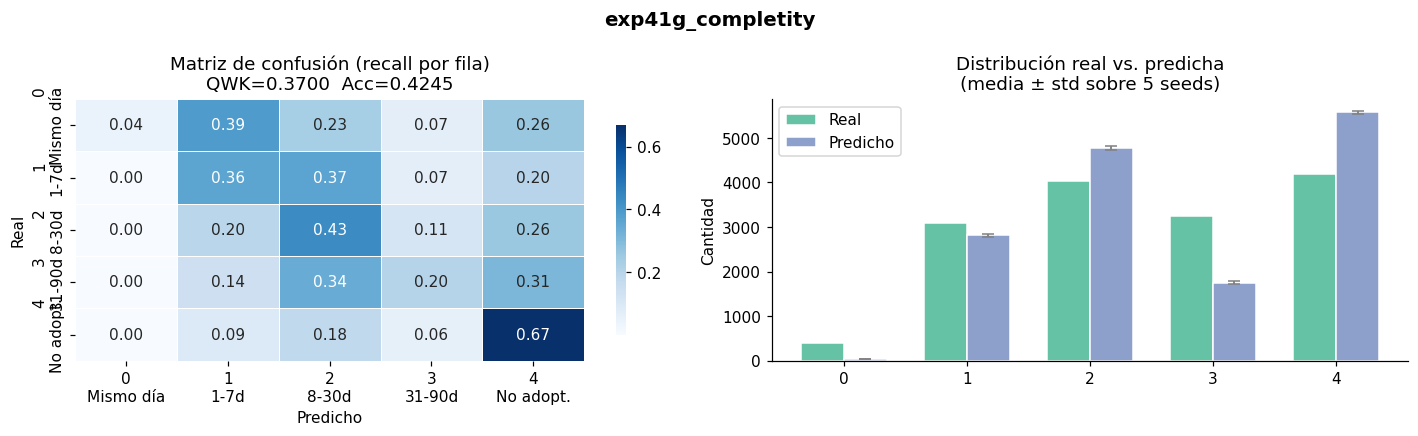

              precision    recall  f1-score   support

  0-MismoDía       0.56      0.04      0.08       410
  1-1ªSemana       0.38      0.36      0.37      3083
    2-1erMes       0.36      0.43      0.39      4029
 3-2do3erMes       0.41      0.20      0.27      3236
  4-NoAdopt.       0.50      0.67      0.58      4193

    accuracy                           0.42     14951
   macro avg       0.44      0.34      0.34     14951
weighted avg       0.42      0.42      0.41     14951



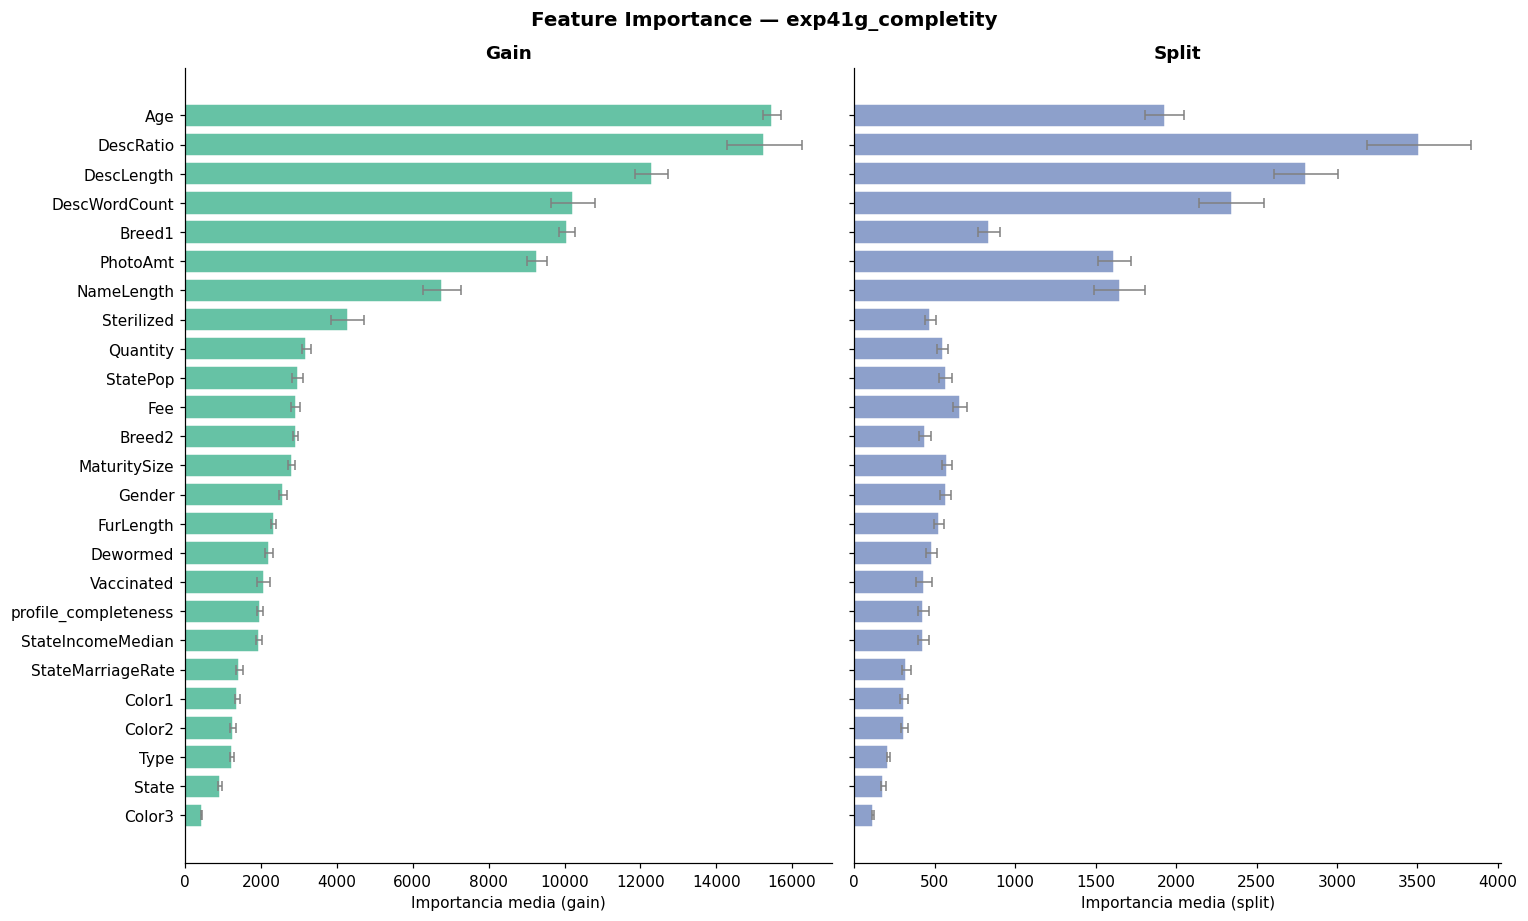

In [33]:
plot_results(y, [r['oof_preds'] for r in exp41g_completity], title='exp41g_completity')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp41g_completity])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp41g_completity')


Esta variable mejora la predicción, aunque aumenta la inestabilidad en la evaluación. Se incorpora, pero se evaluará sobre el modelo final si mantenerla.

In [34]:
CURRENT_FEATURES = CURRENT_FEATURES_41g_completity
best_result = exp41g_completity

## 4.2 Transformaciones de variables numéricas

Se aplicarán logaritmos naturales a las variables numéricas Age, Fee y Quantity. Esto busca reducir la asimetría de estas variables para evaluar si mejora la relación con la variable objetivo.

In [35]:
print(f"Asimetría de Age: {stats.skew(df_fe['Age'])} - Positiva")
print(f"Asimetría de Fee: {stats.skew(df_fe['Fee'])} - Positiva")
print(f"Asimetría de Quantity: {stats.skew(df_fe['Quantity'])} - Positiva")


Asimetría de Age: 3.757481299846114 - Positiva
Asimetría de Fee: 8.90852287722458 - Positiva
Asimetría de Quantity: 4.599774000948044 - Positiva


In [36]:
# ── Transformaciones de skewness ──────────────────────────────────────────────
def fun_exp42_logs(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['Age_log'] = np.log1p(df['Age'])
    df['Fee_log'] = np.log1p(df['Fee'])
    df['Qty_log'] = np.log1p(df['Quantity'])

    return df

df_fe = fun_exp42_logs(df_fe)

NEW_NUM = ['Age_log',
          'Fee_log',
          'Qty_log']

CURRENT_FEATURES_42 = CURRENT_FEATURES + NEW_NUM
X_42 = df_fe[CURRENT_FEATURES_42]

print(f'Features nuevas (4.2): {NEW_NUM}')
print(f'Total features: {len(CURRENT_FEATURES_42)}')
print('\n' + '='*55)
print('EXPERIMENTO 2: + Transformaciones numéricas')
print('='*55)

exp42_logs = []

for seed in SEEDS:
    r = run_cv(
        X=X_42,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp42_logs{seed}',
        verbose=False,  
    )
    exp42_logs.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp42_logs, name='exp42_logs')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp42_logs]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp42_logs, best_result)

Features nuevas (4.2): ['Age_log', 'Fee_log', 'Qty_log']
Total features: 32

EXPERIMENTO 2: + Transformaciones numéricas
Seed 310019: QWK = 0.3584 ± 0.0288
Seed 320009: QWK = 0.3582 ± 0.0154
Seed 330017: QWK = 0.3596 ± 0.0132
Seed 340007: QWK = 0.3600 ± 0.0199
Seed 350029: QWK = 0.3573 ± 0.0086

── Resumen sobre 5 semillas ──
QWK medio:  0.3587
QWK std:    0.0010
QWK rango:  [0.3573, 0.3600]
  Referencia : QWK = 0.3615 ± 0.0168  (n=25 folds)
  Nuevo      : QWK = 0.3587 ± 0.0185  (n=25 folds)
  ΔQWK       : -0.0028


-0.002824790461289195

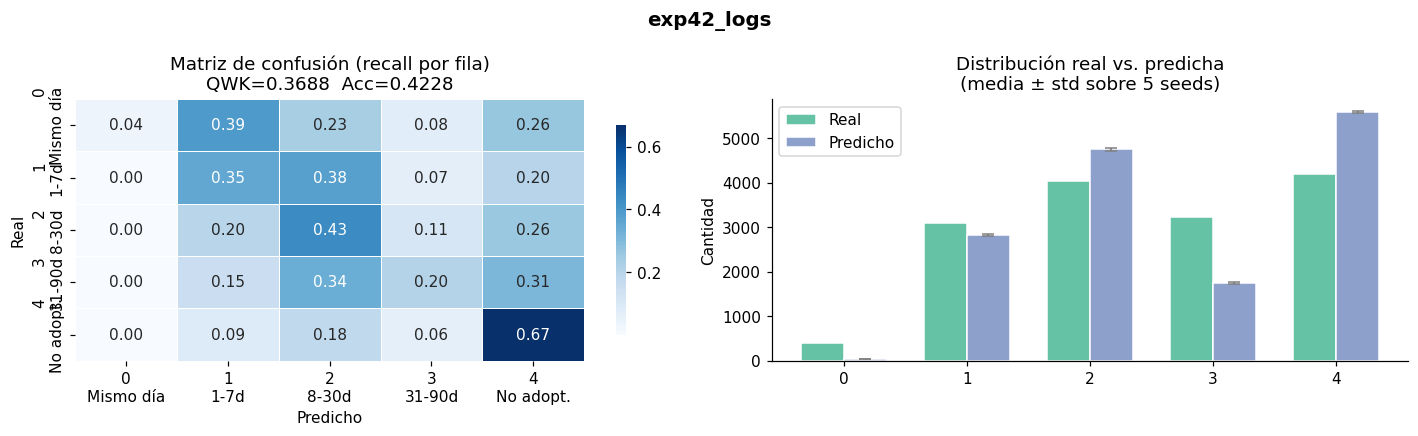

              precision    recall  f1-score   support

  0-MismoDía       0.50      0.04      0.07       410
  1-1ªSemana       0.38      0.35      0.37      3083
    2-1erMes       0.36      0.43      0.39      4029
 3-2do3erMes       0.41      0.20      0.27      3236
  4-NoAdopt.       0.50      0.67      0.57      4193

    accuracy                           0.42     14951
   macro avg       0.43      0.34      0.34     14951
weighted avg       0.42      0.42      0.40     14951



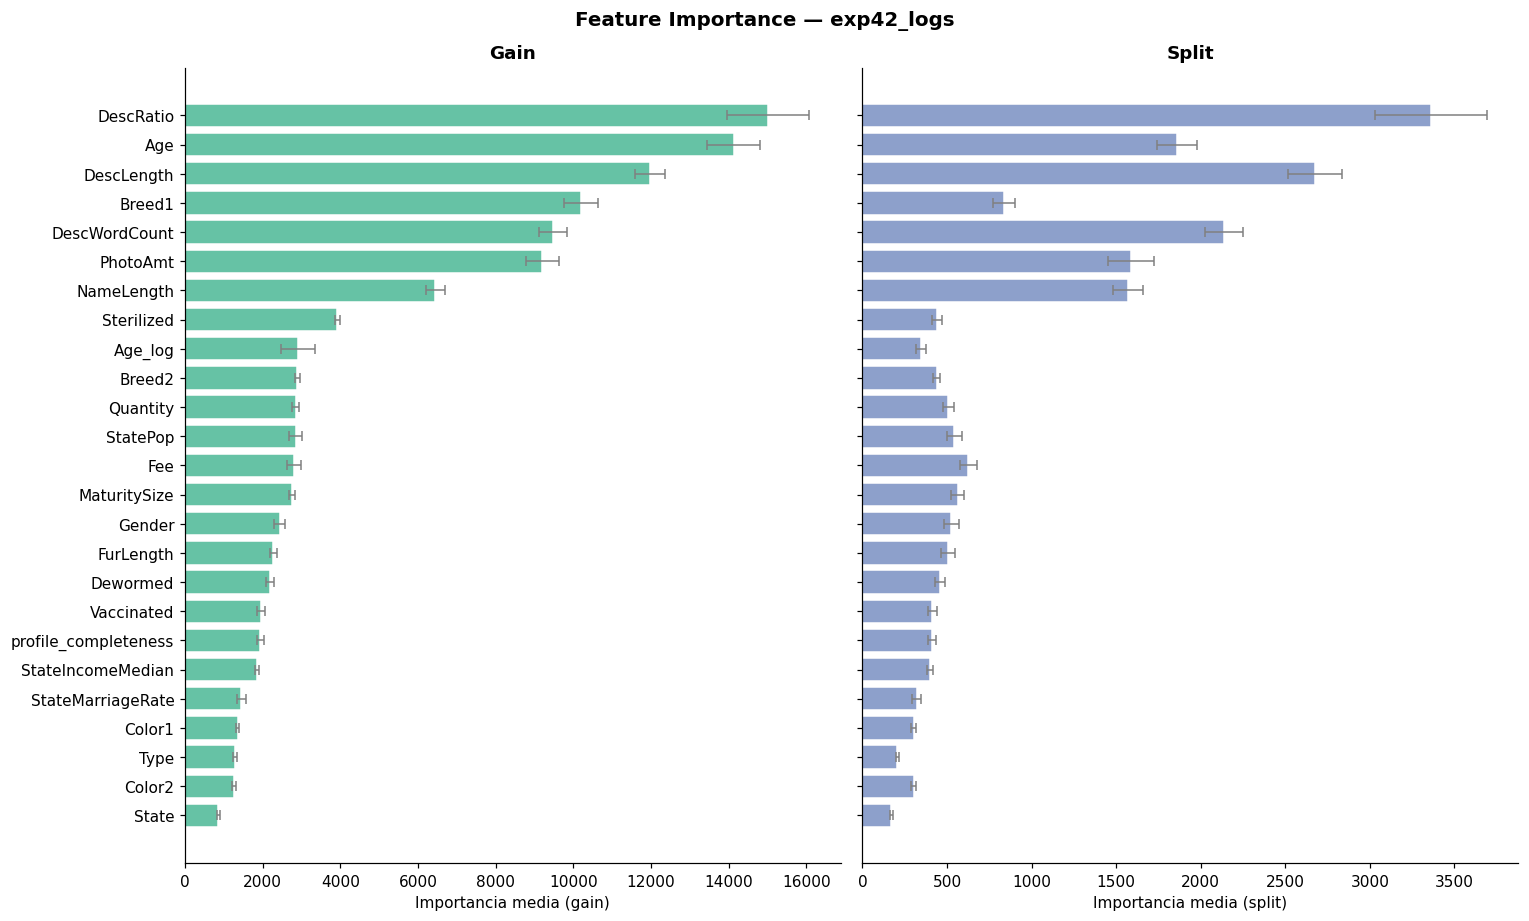

In [37]:
plot_results(y, [r['oof_preds'] for r in exp42_logs], title='exp42_logs')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp42_logs])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp42_logs')


Si bien no aporta mejoras en QWK, las métricas parecen tener valor en el Feature Importance. Se evalúa el mismo modelo pero eliminando las variables de origen.

In [38]:
NEW_NUM = ['Age_log',
          'Fee_log',
          'Qty_log'
          ]

features_sin_originales = [f for f in CURRENT_FEATURES 
                            if f not in ['Age', 
                                         'Fee', 
                                         'Quantity'
                            ]]

CURRENT_FEATURES_42_reemplazo = features_sin_originales + NEW_NUM
X_42rep = df_fe[CURRENT_FEATURES_42_reemplazo]

print(f'Features nuevas (4.2): {NEW_NUM}')
print(f'Total features: {len(CURRENT_FEATURES_42_reemplazo)}')
print('\n' + '='*55)
print('EXPERIMENTO 2: + Logaritmos con reemplazo')
print('='*55)

exp42_logs_rep = []

for seed in SEEDS:
    r = run_cv(
        X=X_42rep,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp42_logs_rep{seed}',
        verbose=False,  
    )
    exp42_logs_rep.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp42_logs_rep, name='exp42_logs_rep')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp42_logs_rep]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp42_logs_rep, best_result)

Features nuevas (4.2): ['Age_log', 'Fee_log', 'Qty_log']
Total features: 29

EXPERIMENTO 2: + Logaritmos con reemplazo
Seed 310019: QWK = 0.3577 ± 0.0260
Seed 320009: QWK = 0.3588 ± 0.0141
Seed 330017: QWK = 0.3595 ± 0.0130
Seed 340007: QWK = 0.3623 ± 0.0199
Seed 350029: QWK = 0.3597 ± 0.0118

── Resumen sobre 5 semillas ──
QWK medio:  0.3596
QWK std:    0.0015
QWK rango:  [0.3577, 0.3623]
  Referencia : QWK = 0.3615 ± 0.0168  (n=25 folds)
  Nuevo      : QWK = 0.3596 ± 0.0178  (n=25 folds)
  ΔQWK       : -0.0019


-0.0019448570159385503

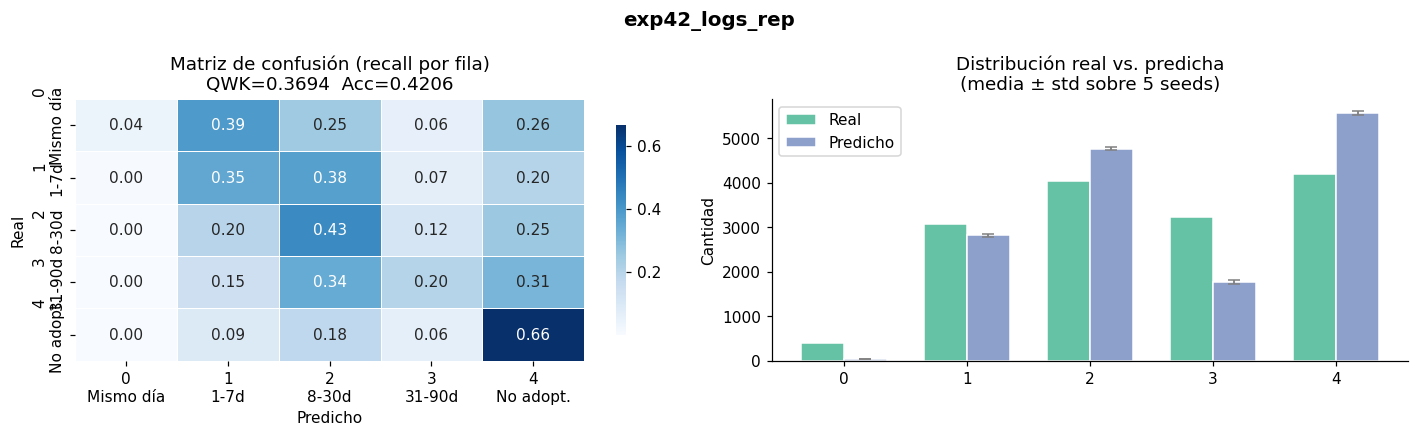

              precision    recall  f1-score   support

  0-MismoDía       0.50      0.04      0.08       410
  1-1ªSemana       0.38      0.35      0.36      3083
    2-1erMes       0.36      0.43      0.39      4029
 3-2do3erMes       0.41      0.20      0.27      3236
  4-NoAdopt.       0.50      0.66      0.57      4193

    accuracy                           0.42     14951
   macro avg       0.43      0.34      0.33     14951
weighted avg       0.42      0.42      0.40     14951



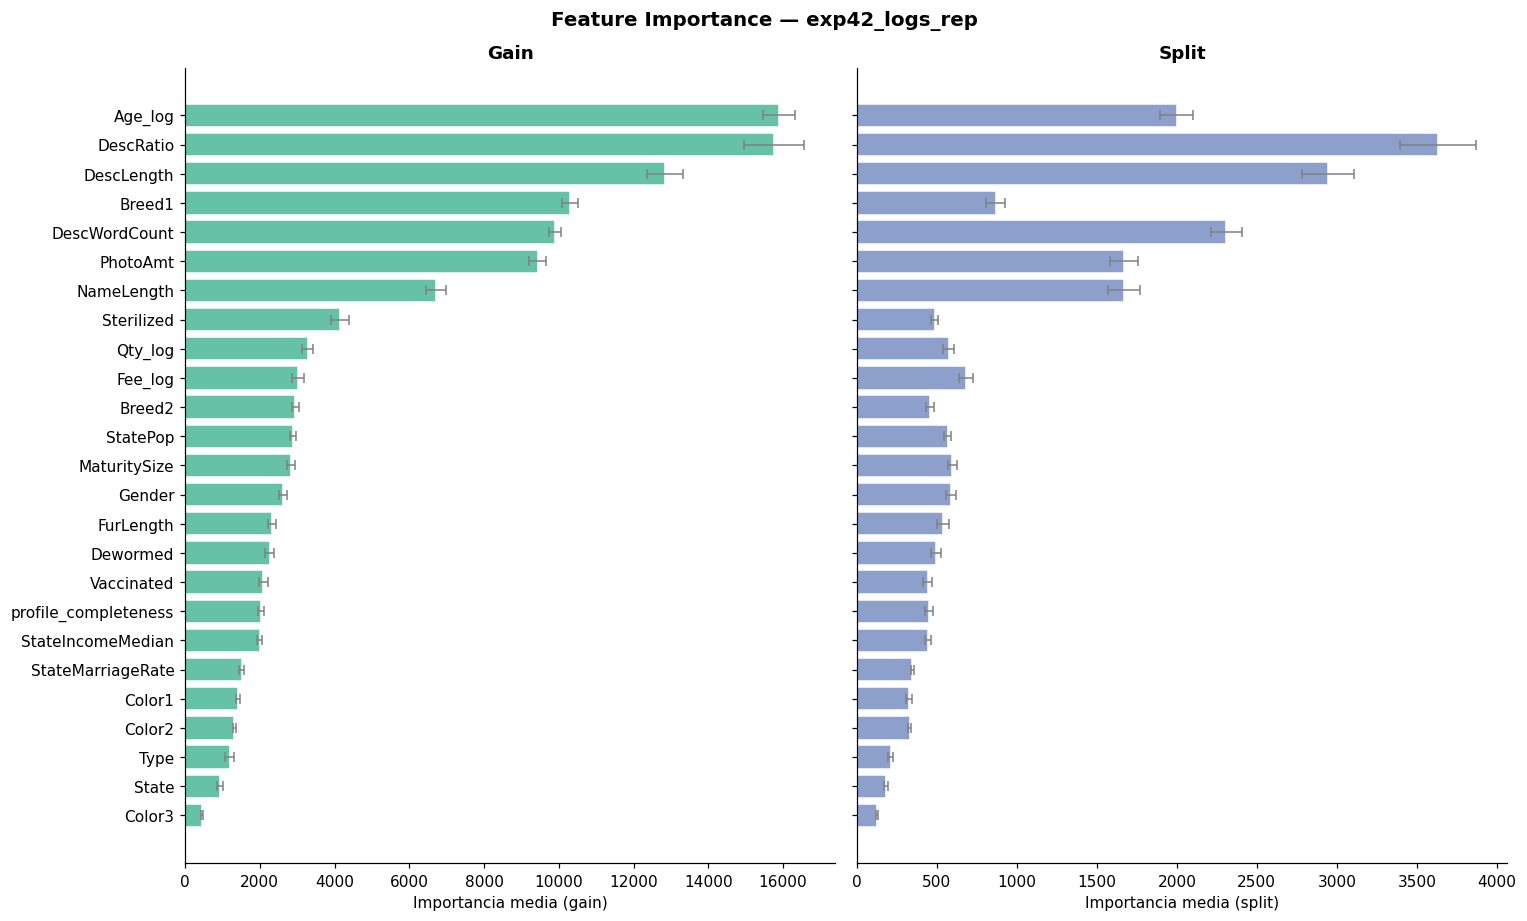

In [39]:
plot_results(y, [r['oof_preds'] for r in exp42_logs_rep], title='exp42_logs_rep')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp42_logs_rep])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp42_logs_rep')


La única variable que parece mejorar al convertirse a logaritmo natural es Fee. Se incorpora esta variable sin su original.

In [40]:
NEW_NUM = [#'Age_log',
          'Fee_log',
          #'Qty_log'
          ]

features_sin_originales = [f for f in CURRENT_FEATURES 
                            if f not in [#'Age', 
                                         'Fee', 
                                         #'Quantity'
                            ]]

CURRENT_FEATURES_42_fee = features_sin_originales + NEW_NUM
X_42fee = df_fe[CURRENT_FEATURES_42_fee]

print(f'Features nuevas (4.2): {NEW_NUM}')
print(f'Total features: {len(CURRENT_FEATURES_42_fee)}')
print('\n' + '='*55)
print('EXPERIMENTO 2: + Logaritmos con reemplazo')
print('='*55)

exp42_logs_fee = []

for seed in SEEDS:
    r = run_cv(
        X=X_42fee,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp42_logs_fee{seed}',
        verbose=False,  
    )
    exp42_logs_fee.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp42_logs_fee, name='exp42_logs_fee')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp42_logs_fee]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp42_logs_fee, best_result)

Features nuevas (4.2): ['Fee_log']
Total features: 29

EXPERIMENTO 2: + Logaritmos con reemplazo
Seed 310019: QWK = 0.3565 ± 0.0228
Seed 320009: QWK = 0.3662 ± 0.0169
Seed 330017: QWK = 0.3630 ± 0.0086
Seed 340007: QWK = 0.3636 ± 0.0170
Seed 350029: QWK = 0.3631 ± 0.0144

── Resumen sobre 5 semillas ──
QWK medio:  0.3625
QWK std:    0.0032
QWK rango:  [0.3565, 0.3662]
  Referencia : QWK = 0.3615 ± 0.0168  (n=25 folds)
  Nuevo      : QWK = 0.3625 ± 0.0169  (n=25 folds)
  ΔQWK       : +0.0010


0.0009772717569639933

In [41]:
CURRENT_FEATURES = CURRENT_FEATURES_42_fee
best_result = exp42_logs_fee

## 4.2.b Discretización de Age
Para generar categorías de cachorros - jóvenes - adultos - seniors, se diseñarán criterios específicos por tipo de animal, edad y tamaño

In [42]:

def fun_exp42b_bins_simple(df: pd.DataFrame) -> pd.DataFrame:
    df['age_stage'] = pd.cut(
        df['Age'],
        bins=[-1, 2, 8, 24, float('inf')],
        labels=[0, 1, 2, 3]
    ).astype(int)
    return df


df_fe = fun_exp42b_bins_simple(df_fe)

NEW_NUM = ['age_stage']
features_sin_originales = [f for f in CURRENT_FEATURES 
                            if f not in ['Age',
                            ]]

CURRENT_FEATURES_42b = features_sin_originales + NEW_NUM
X_42b = df_fe[CURRENT_FEATURES_42b]

print(f'Features nuevas (4.2): {NEW_NUM}')
print(f'Total features: {len(CURRENT_FEATURES_42b)}')
print('\n' + '='*55)
print('EXPERIMENTO 2: + Discretizaciones')
print('='*55)

exp42b_bins = []

for seed in SEEDS:
    r = run_cv(
        X=X_42b,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals + ['age_stage'],
        experiment_name=f'exp42b_bins{seed}',
        verbose=False,  
    )
    exp42b_bins.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp42b_bins, name='exp42b_bins')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp42b_bins]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp42b_bins, best_result)

Features nuevas (4.2): ['age_stage']
Total features: 29

EXPERIMENTO 2: + Discretizaciones
Seed 310019: QWK = 0.3411 ± 0.0174
Seed 320009: QWK = 0.3406 ± 0.0173
Seed 330017: QWK = 0.3504 ± 0.0077
Seed 340007: QWK = 0.3436 ± 0.0163
Seed 350029: QWK = 0.3341 ± 0.0231

── Resumen sobre 5 semillas ──
QWK medio:  0.3420
QWK std:    0.0053
QWK rango:  [0.3341, 0.3504]
  Referencia : QWK = 0.3625 ± 0.0169  (n=25 folds)
  Nuevo      : QWK = 0.3420 ± 0.0179  (n=25 folds)
  ΔQWK       : -0.0205


-0.020541699521542667

Pero esto no parece tener efecto. La variable Age es más informativa, el modelo de LGBM tiene la capacidad de generar los cortes necesarios.

## 4.3 Features de interacción

Multiplicaciones entre features. Se busca identificar interacciones entre variables que puedan ser explicativas de la variable objetivo, optimizando los cortes que realiza el algoritmo. 

In [43]:
def fun_exp43_interactions(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['Type_x_Age']    = df['Type']    * df['Age']
    df['Type_x_IsFree'] = df['Type']    * df['IsFree']
    df['Age_x_IsFree']  = df['Age']     * df['IsFree']
    df['Fee_x_Photo']   = df['Fee']     * df['PhotoAmt']
    df['Age_x_Photo']   = df['Age']     * df['PhotoAmt']
    df['Health_x_Type'] = df['Health']  * df['Type']
    df['Type_x_Mixed']  = df['Type']    * df['MixedBreed']

    return df

df_fe = fun_exp43_interactions(df_fe)

NEW_INT = ['Type_x_Age', 
           'Type_x_IsFree', 
           'Age_x_IsFree',
           'Fee_x_Photo', 
           'Age_x_Photo', 
           'Health_x_Type', 
           'Type_x_Mixed'
          ]

CURRENT_FEATURES_43 = CURRENT_FEATURES + NEW_INT
X_43 = df_fe[CURRENT_FEATURES_43]

print(f'Features nuevas (4.3): {NEW_INT}')
print(f'Total features: {len(CURRENT_FEATURES_43)}')
print('\n' + '='*55)
print('EXPERIMENTO 3: + Interacciones')
print('='*55)

exp43_interactions = []

for seed in SEEDS:
    r = run_cv(
        X=X_43,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'exp43_interactions{seed}',
        verbose=False,  
    )
    exp43_interactions.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp43_interactions, name='exp43_interactions')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp43_interactions]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp43_interactions, best_result)

Features nuevas (4.3): ['Type_x_Age', 'Type_x_IsFree', 'Age_x_IsFree', 'Fee_x_Photo', 'Age_x_Photo', 'Health_x_Type', 'Type_x_Mixed']
Total features: 36

EXPERIMENTO 3: + Interacciones
Seed 310019: QWK = 0.3639 ± 0.0209
Seed 320009: QWK = 0.3655 ± 0.0137
Seed 330017: QWK = 0.3687 ± 0.0087
Seed 340007: QWK = 0.3574 ± 0.0139
Seed 350029: QWK = 0.3594 ± 0.0128

── Resumen sobre 5 semillas ──
QWK medio:  0.3630
QWK std:    0.0041
QWK rango:  [0.3574, 0.3687]
  Referencia : QWK = 0.3625 ± 0.0169  (n=25 folds)
  Nuevo      : QWK = 0.3630 ± 0.0151  (n=25 folds)
  ΔQWK       : +0.0005


0.000470657864146129

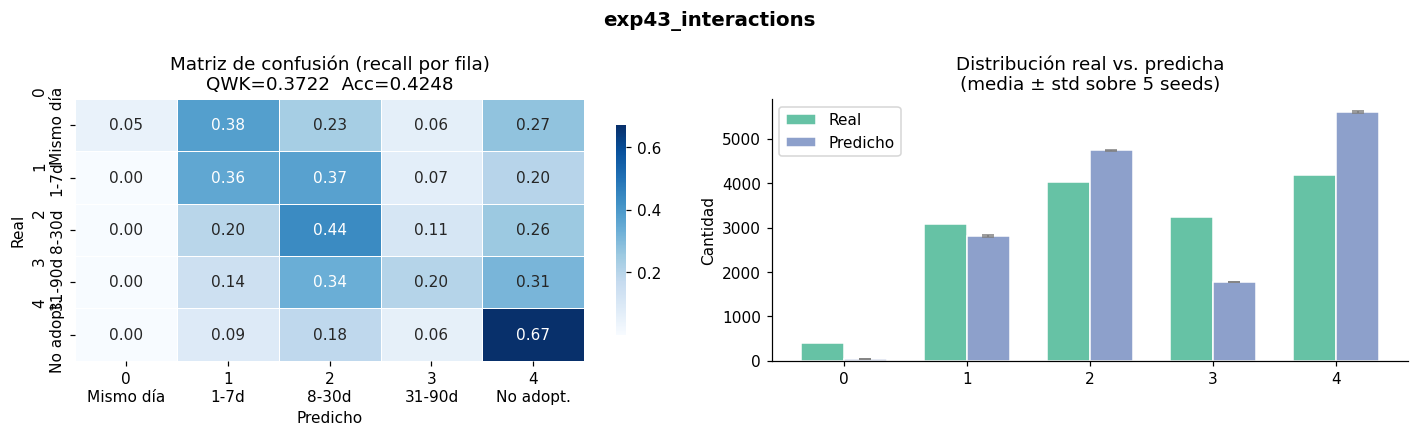

              precision    recall  f1-score   support

  0-MismoDía       0.48      0.05      0.09       410
  1-1ªSemana       0.38      0.36      0.37      3083
    2-1erMes       0.36      0.44      0.40      4029
 3-2do3erMes       0.41      0.20      0.27      3236
  4-NoAdopt.       0.50      0.67      0.58      4193

    accuracy                           0.42     14951
   macro avg       0.43      0.34      0.34     14951
weighted avg       0.42      0.42      0.41     14951



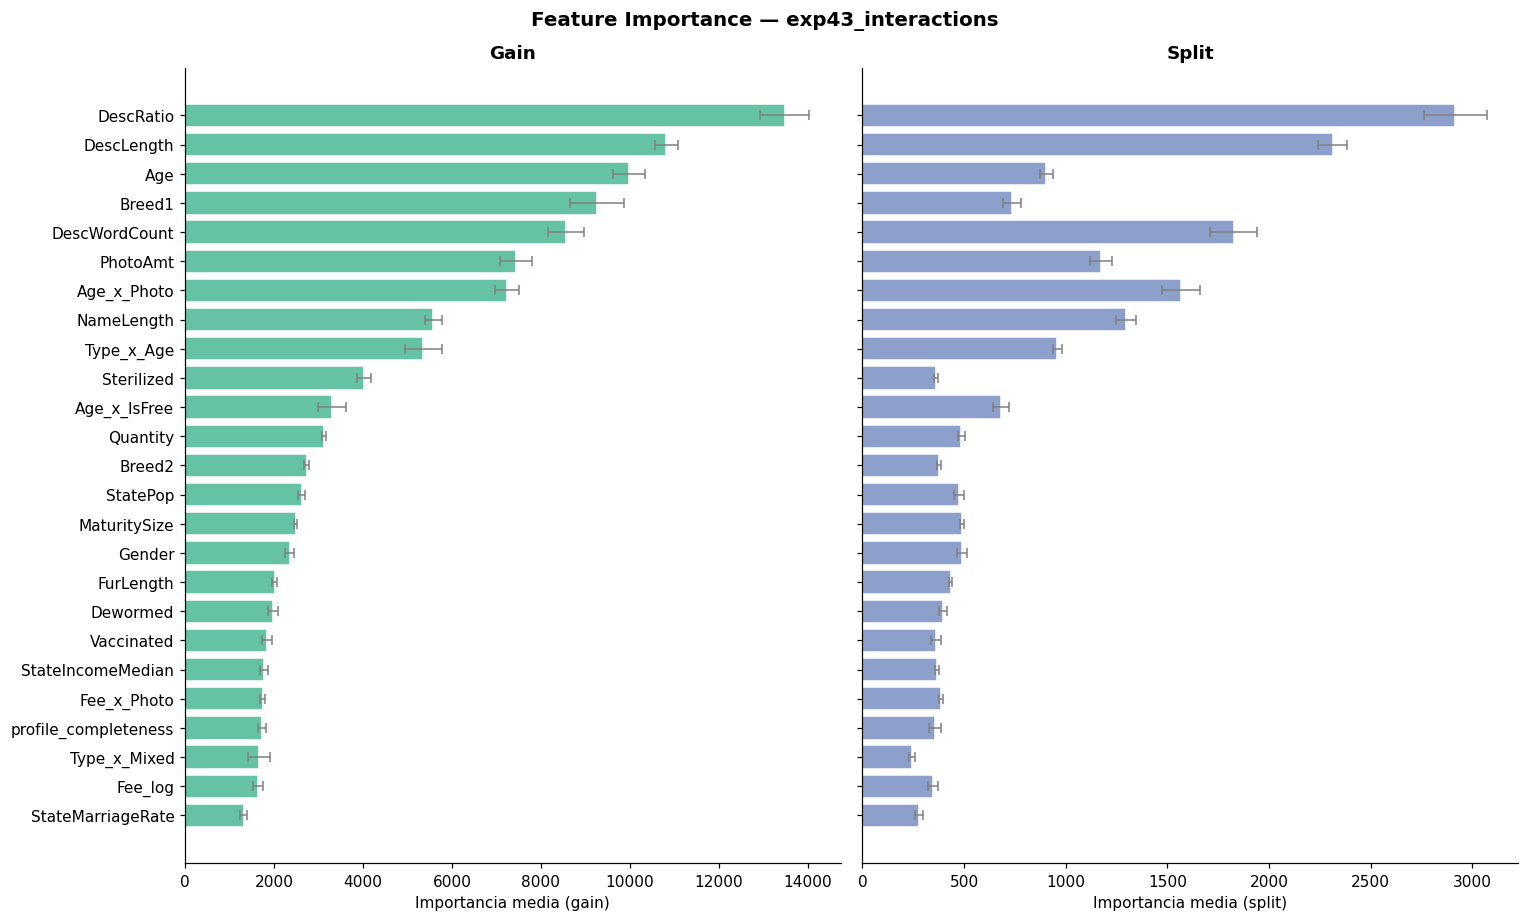

In [44]:
plot_results(y, [r['oof_preds'] for r in exp43_interactions], title='exp43_interactions')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp43_interactions])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp43_interactions')


Estas features parecen generar interferencia, el árbol logra capturar las relaciones sin necesidad de incorporarlas en cruces de variables. Particularmente se observa con Age, que es utilizada en varios cruces y la variable original pierde mucho peso. Dado que el QWK no aumenta y que crece la variabilidad, no se incorporarán estas variables.

## 4.4a Aggregations por RescuerID
Estadísticas de comportamiento del rescatista: se genererará una columna que identifique, dentro de cada fold del proceso de Cross-validation, si el rescatista es nuevo (es decir, si sólo hay una publicación de ese rescatista dentro del fold) o no. Como esta variable es dicotómica y no estadística, no se aplicará smoothing.

In [45]:
# ── Definición de las aggregations ────────────────────────────────────────────
# Formato: {columna_de_agrupación: {nombre_nueva_col: (col_fuente, función)}}
AGG_RESCUER = {
    'RescuerID': {
        'resc_is_new' : ('RescuerID',  lambda x: int(len(x) == 1)),
    }
}

AGG_SMOOTHING = {
    'RescuerID': 0
}

# RescuerID debe estar en X para que run_cv pueda agrupar
AUX_COLS = ['RescuerID']
CURRENT_FEATURES_44a = CURRENT_FEATURES
X_44a = df_fe[CURRENT_FEATURES_44a + AUX_COLS]

print('Features que se generarán dentro del fold:')
print([k for v in AGG_RESCUER.values() for k in v.keys()])
print(f'\nTotal features en X (incl. RescuerID auxiliar): {len(CURRENT_FEATURES_44a)}')
print('\n' + '='*55)
print('EXPERIMENTO 4a: + Aggregations por rescatista')
print('='*55)

exp44a_aggregations = []

for seed in SEEDS:
    r = run_cv(
        X=X_44a,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,       # rescatistas con <n publicaciones tiran a la media
        aux_cols=AUX_COLS, 
        experiment_name=f'exp44a_aggregations{seed}',
        verbose=False,  
    )
    exp44a_aggregations.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp44a_aggregations, name='exp44a_aggregations')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp44a_aggregations]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp44a_aggregations, best_result)

Features que se generarán dentro del fold:
['resc_is_new']

Total features en X (incl. RescuerID auxiliar): 29

EXPERIMENTO 4a: + Aggregations por rescatista
Seed 310019: QWK = 0.3720 ± 0.0159
Seed 320009: QWK = 0.3701 ± 0.0142
Seed 330017: QWK = 0.3725 ± 0.0120
Seed 340007: QWK = 0.3769 ± 0.0134
Seed 350029: QWK = 0.3761 ± 0.0130

── Resumen sobre 5 semillas ──
QWK medio:  0.3735
QWK std:    0.0026
QWK rango:  [0.3701, 0.3769]
  Referencia : QWK = 0.3625 ± 0.0169  (n=25 folds)
  Nuevo      : QWK = 0.3735 ± 0.0140  (n=25 folds)
  ΔQWK       : +0.0110


0.011003599741441716

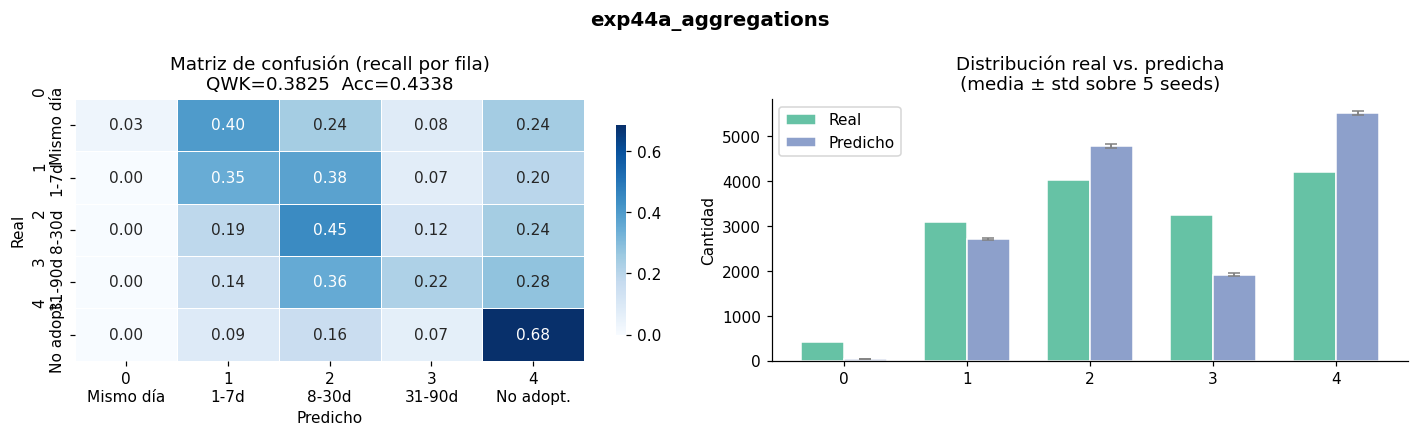

              precision    recall  f1-score   support

  0-MismoDía       0.57      0.03      0.06       410
  1-1ªSemana       0.38      0.35      0.36      3083
    2-1erMes       0.37      0.45      0.40      4029
 3-2do3erMes       0.41      0.22      0.29      3236
  4-NoAdopt.       0.53      0.68      0.59      4193

    accuracy                           0.43     14951
   macro avg       0.45      0.35      0.34     14951
weighted avg       0.43      0.43      0.42     14951



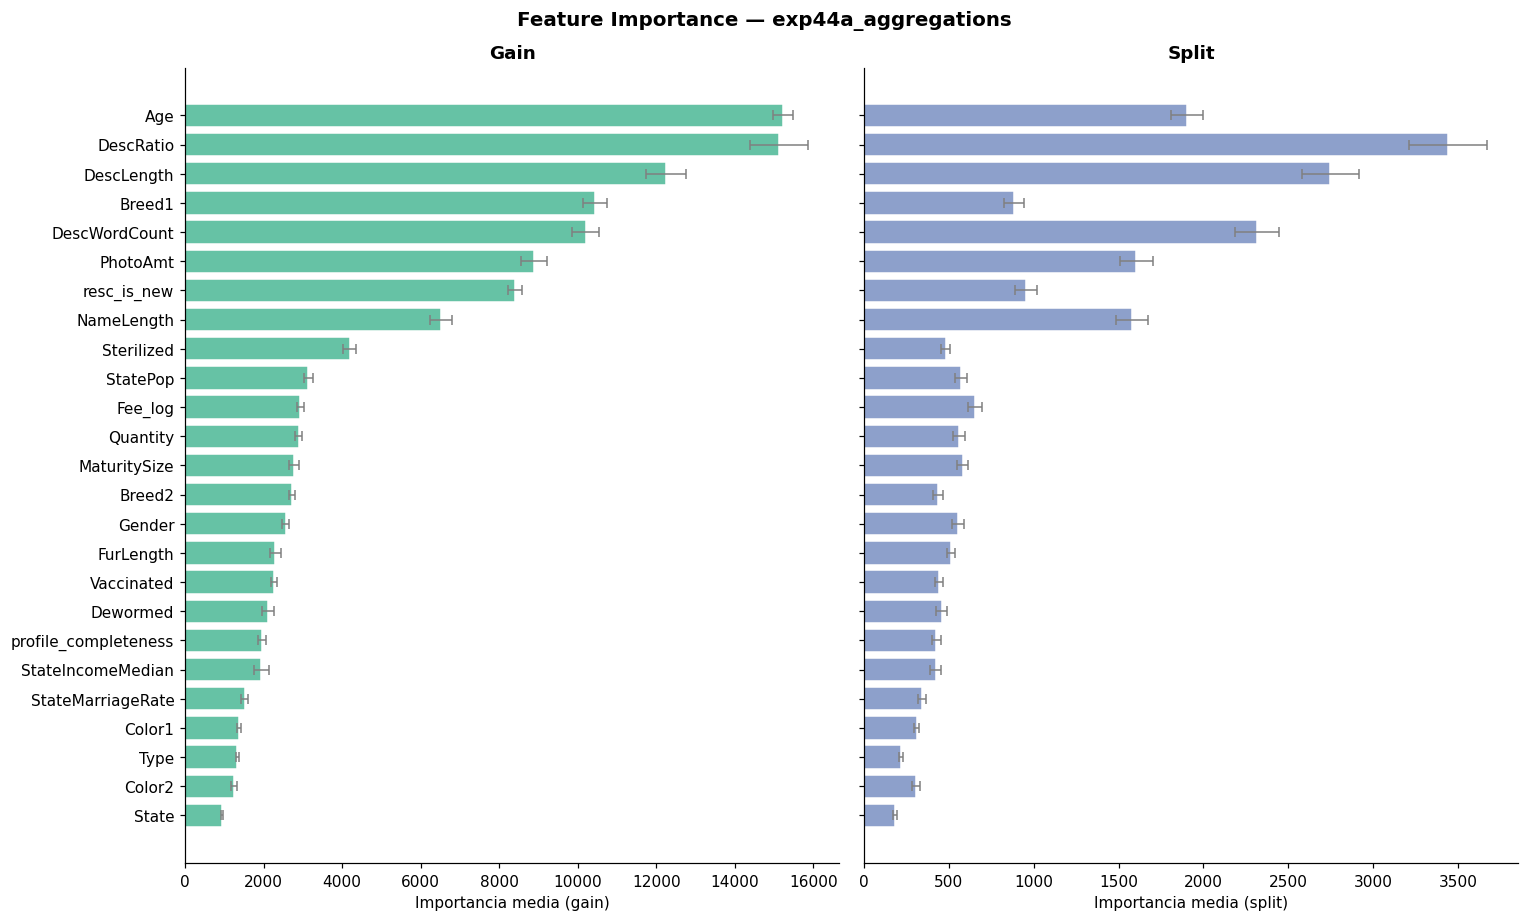

In [46]:
plot_results(y, [r['oof_preds'] for r in exp44a_aggregations], title='exp44a_aggregations')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp44a_aggregations])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp44a_aggregations')


Las variables agregadas a partir del Rescatista parecen cobrar mucha importancia. Esto puede deberse a que capturan información valiosa que correlaciona con la variable target, aunque también puede ser Leakage encubierto.
Para evaluar si este experimento genera Leakage directo, se realizará un experimento aleatorizando la variable target y evaluando el desempeño del modelo para identificar una memorización de falsos patrones.

In [47]:
# ── Test de leakage para aggregations ────────────────────────────────────────
# Si hay leakage, un target aleatorio también va a "mejorar" con las aggregations
# porque las estadísticas del grupo van a correlacionar con el target shuffleado

y_shuffled = y.sample(frac=1, random_state=SEED).reset_index(drop=True)


exp44a_aggregations_shuffled = []

for seed in SEEDS:
    r = run_cv(
        X=X_44a,
        y=y_shuffled,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,       # rescatistas con <n publicaciones tiran a la media
        aux_cols=AUX_COLS, 
        experiment_name=f'exp44a_aggregations_shuffled{seed}',
        verbose=False,  
    )
    exp44a_aggregations_shuffled.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp44a_aggregations_shuffled, name='exp44a_aggregations_shuffled')

baseline_shuffled = []
for seed in SEEDS:
    r = run_cv(
        X=X_base,
        y=y_shuffled,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        experiment_name=f'baseline_shuffled{seed}',
        verbose=False,  
    )
    baseline_shuffled.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(baseline_shuffled, name='baseline_shuffled')

# Resumen final
print(f'\nQWK baseline con target real:     {np.mean([r['qwk_mean'] for r in exp00b_baseline]):.4f} ± {np.std([r['qwk_mean'] for r in exp00b_baseline]):.4f}')
print(f'QWK baseline con target shuffle:  {np.mean([r['qwk_mean'] for r in baseline_shuffled]):.4f} ± {np.std([r['qwk_mean'] for r in baseline_shuffled]):.4f}')
print(f'QWK rescuer agg con target real:  {np.mean([r['qwk_mean'] for r in exp44a_aggregations]):.4f} ± {np.std([r['qwk_mean'] for r in exp44a_aggregations]):.4f}')
print(f'QWK rescuer agg con target shuffle: {np.mean([r['qwk_mean'] for r in exp44a_aggregations_shuffled]):.4f} ± {np.std([r['qwk_mean'] for r in exp44a_aggregations_shuffled]):.4f}')

Seed 310019: QWK = 0.0021 ± 0.0051
Seed 320009: QWK = 0.0039 ± 0.0051
Seed 330017: QWK = -0.0029 ± 0.0087
Seed 340007: QWK = 0.0040 ± 0.0036
Seed 350029: QWK = 0.0125 ± 0.0075
Seed 310019: QWK = 0.0006 ± 0.0025
Seed 320009: QWK = 0.0060 ± 0.0044
Seed 330017: QWK = 0.0032 ± 0.0018
Seed 340007: QWK = 0.0042 ± 0.0071
Seed 350029: QWK = 0.0034 ± 0.0019

QWK baseline con target real:     0.3555 ± 0.0038
QWK baseline con target shuffle:  0.0035 ± 0.0017
QWK rescuer agg con target real:  0.3735 ± 0.0026
QWK rescuer agg con target shuffle: 0.0039 ± 0.0050


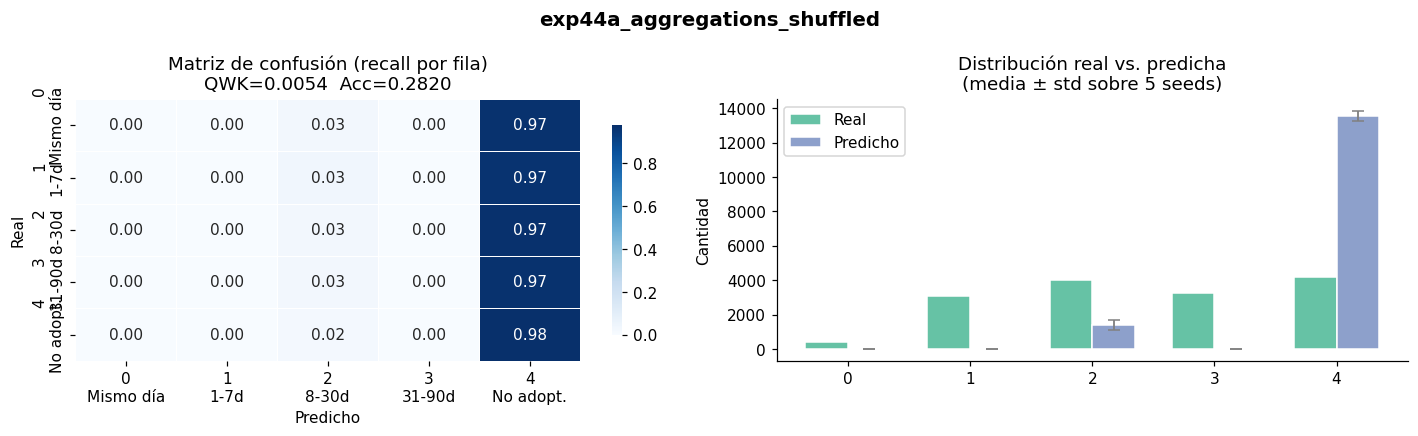

c:\Users\carte\miniconda3\envs\ldi2\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\carte\miniconda3\envs\ldi2\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\carte\miniconda3\envs\ldi2\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

              precision    recall  f1-score   support

  0-MismoDía       0.00      0.00      0.00       410
  1-1ªSemana       0.00      0.00      0.00      3083
    2-1erMes       0.27      0.03      0.05      4029
 3-2do3erMes       0.00      0.00      0.00      3236
  4-NoAdopt.       0.28      0.98      0.44      4193

    accuracy                           0.28     14951
   macro avg       0.11      0.20      0.10     14951
weighted avg       0.15      0.28      0.14     14951



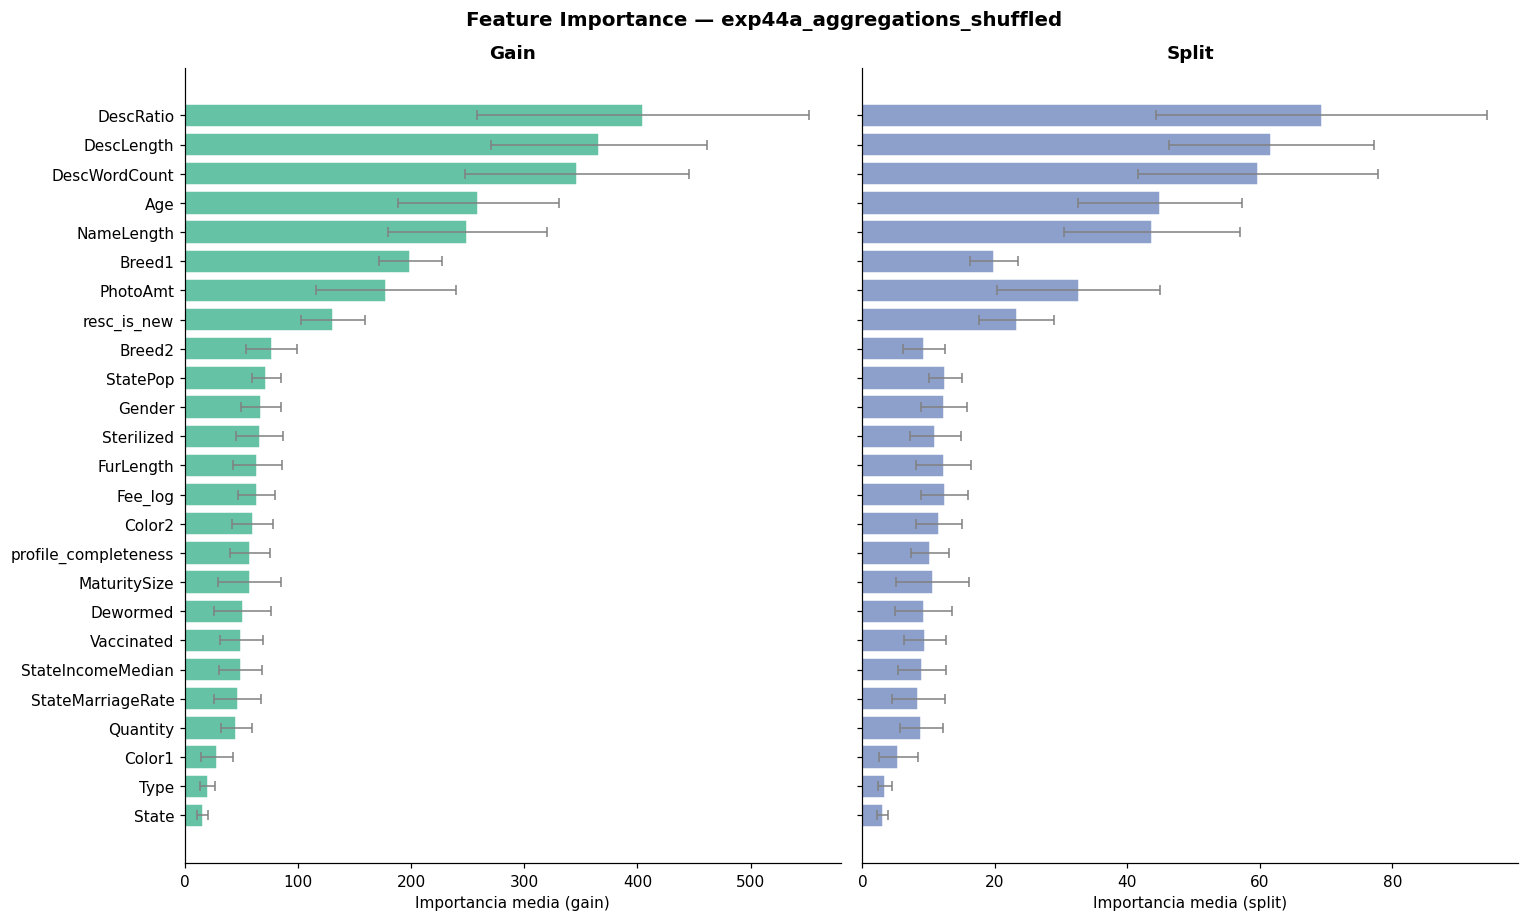

In [48]:
plot_results(y, [r['oof_preds'] for r in exp44a_aggregations_shuffled], title='exp44a_aggregations_shuffled')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp44a_aggregations_shuffled])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp44a_aggregations_shuffled')


El QWK se desploma, y las variables de agregación de RescuerID no destacan frente a otras. Se incorporará la feature.

In [49]:
CURRENT_FEATURES = CURRENT_FEATURES_44a
best_result = exp44a_aggregations

## 4.4b Aggregations por Breed

Estadísticas de comportamiento de la raza: edad promedio, frecuencia, precio.

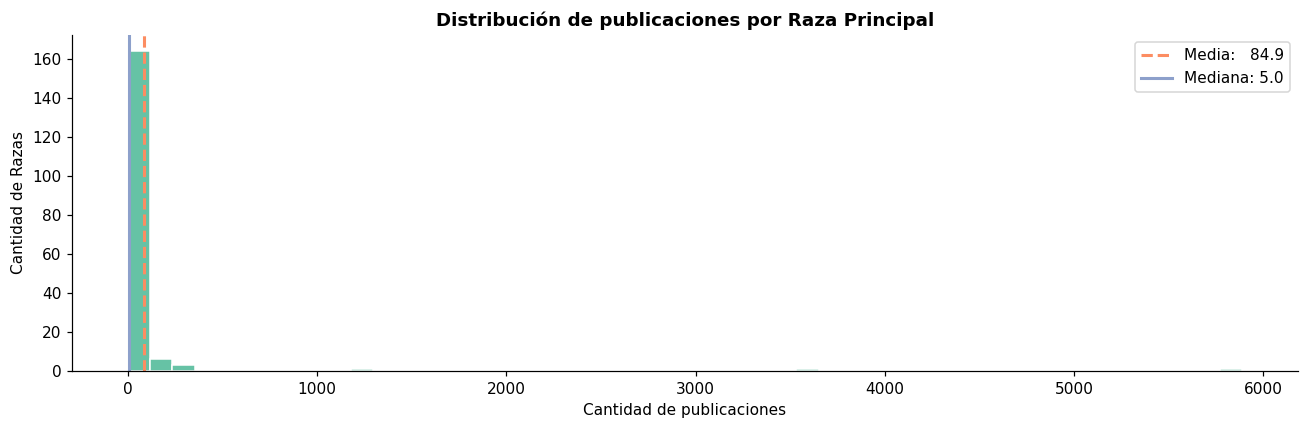

Total razas únicas: 176
Media:                    84.9
Mediana:                  5.0
Máximo:                   5888
% con 1 sola publicación: 19.3%
% con ≤2 publicaciones:   34.7%
% con ≤5 publicaciones:   56.2%
% con ≤10 publicaciones:  66.5%
% con ≤20 publicaciones:  75.0%
% con ≤50 publicaciones:  85.8%


In [50]:
# ── Distribución de frecuencias por RescuerID ─────────────────────────────────
freq_rescuer = df_fe['Breed1'].value_counts()

media   = freq_rescuer.mean()
mediana = freq_rescuer.median()

fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(freq_rescuer.values, bins=50, color=PALETTE[0], edgecolor='white')

ax.axvline(media,   color=PALETTE[1], linewidth=2, linestyle='--', label=f'Media:   {media:.1f}')
ax.axvline(mediana, color=PALETTE[2], linewidth=2, linestyle='-',  label=f'Mediana: {mediana:.1f}')

ax.set_title('Distribución de publicaciones por Raza Principal', fontweight='bold')
ax.set_xlabel('Cantidad de publicaciones')
ax.set_ylabel('Cantidad de Razas')
ax.legend()

plt.tight_layout()
plt.show()

# ── Resumen estadístico ───────────────────────────────────────────────────────
print(f'Total razas únicas: {len(freq_rescuer):,}')
print(f'Media:                    {media:.1f}')
print(f'Mediana:                  {mediana:.1f}')
print(f'Máximo:                   {freq_rescuer.max()}')
print(f'% con 1 sola publicación: {(freq_rescuer == 1).mean()*100:.1f}%')
print(f'% con ≤2 publicaciones:   {(freq_rescuer <= 2).mean()*100:.1f}%')
print(f'% con ≤5 publicaciones:   {(freq_rescuer <= 5).mean()*100:.1f}%')
print(f'% con ≤10 publicaciones:  {(freq_rescuer <= 10).mean()*100:.1f}%')
print(f'% con ≤20 publicaciones:  {(freq_rescuer <= 20).mean()*100:.1f}%')
print(f'% con ≤50 publicaciones:  {(freq_rescuer <= 50).mean()*100:.1f}%')

In [51]:
# ── Definición de las aggregations ────────────────────────────────────────────
# Formato: {columna_de_agrupación: {nombre_nueva_col: (col_fuente, función)}}
AGG_BREED = {
    'Breed1': {
        'breed_median_age'    : ('Age',      'median'),
        'breed_median_fee'    : ('Fee',      'median'),
        'breed_frecuency' : ('Breed1', 'count')
    }
}

AGG_E44b = {**AGG_RESCUER, **AGG_BREED}

AGG_SMOOTHING = {
    'RescuerID': 0,
    'Breed1':    10
}

# RescuerID debe estar en X para que run_cv pueda agrupar
AUX_COLS_44b = ['RescuerID', 'Fee']
CURRENT_FEATURES_44b = CURRENT_FEATURES
X_44b = df_fe[CURRENT_FEATURES_44b + AUX_COLS_44b]

print('Features que se generarán dentro del fold:')
print([k for v in AGG_E44b.values() for k in v.keys()])
print(f'\nTotal features en X (incl. RescuerID auxiliar): {len(CURRENT_FEATURES_44b)}')
print('\n' + '='*55)
print('EXPERIMENTO 4b: + Aggregations por raza')
print('='*55)

categoricals_4b = [f for f in categoricals if f not in ['Breed1']]

exp44b_breed_agg = []
for seed in SEEDS:
    r = run_cv(
        X=X_44b,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals_4b,
        agg_config=AGG_E44b,
        agg_smoothing=AGG_SMOOTHING,       # razas con <n publicaciones tiran a la media
        aux_cols=AUX_COLS_44b,
        experiment_name=f'exp44b_breed_agg{seed}',
        verbose=False,  
    )
    exp44b_breed_agg.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp44b_breed_agg, name='exp44b_breed_agg')
delta(exp44b_breed_agg, best_result)


Features que se generarán dentro del fold:
['resc_is_new', 'breed_median_age', 'breed_median_fee', 'breed_frecuency']

Total features en X (incl. RescuerID auxiliar): 29

EXPERIMENTO 4b: + Aggregations por raza
Seed 310019: QWK = 0.3625 ± 0.0069
Seed 320009: QWK = 0.3596 ± 0.0143
Seed 330017: QWK = 0.3599 ± 0.0153
Seed 340007: QWK = 0.3663 ± 0.0030
Seed 350029: QWK = 0.3536 ± 0.0088
  Referencia : QWK = 0.3735 ± 0.0140  (n=25 folds)
  Nuevo      : QWK = 0.3604 ± 0.0115  (n=25 folds)
  ΔQWK       : -0.0131


-0.01311994932772742

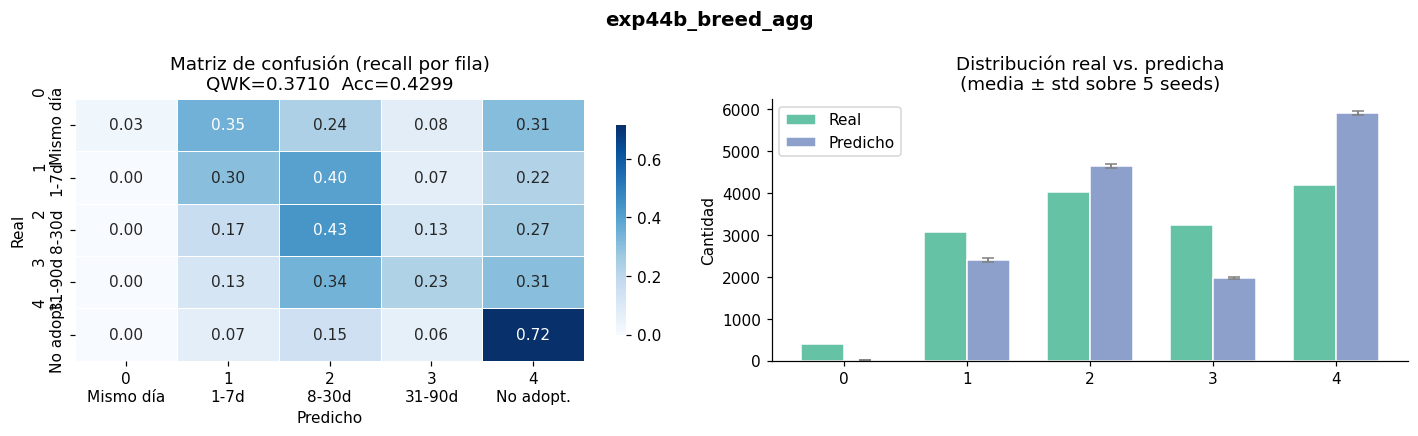

              precision    recall  f1-score   support

  0-MismoDía       0.48      0.03      0.06       410
  1-1ªSemana       0.38      0.30      0.34      3083
    2-1erMes       0.36      0.43      0.40      4029
 3-2do3erMes       0.41      0.23      0.29      3236
  4-NoAdopt.       0.51      0.72      0.60      4193

    accuracy                           0.43     14951
   macro avg       0.43      0.34      0.34     14951
weighted avg       0.42      0.43      0.41     14951



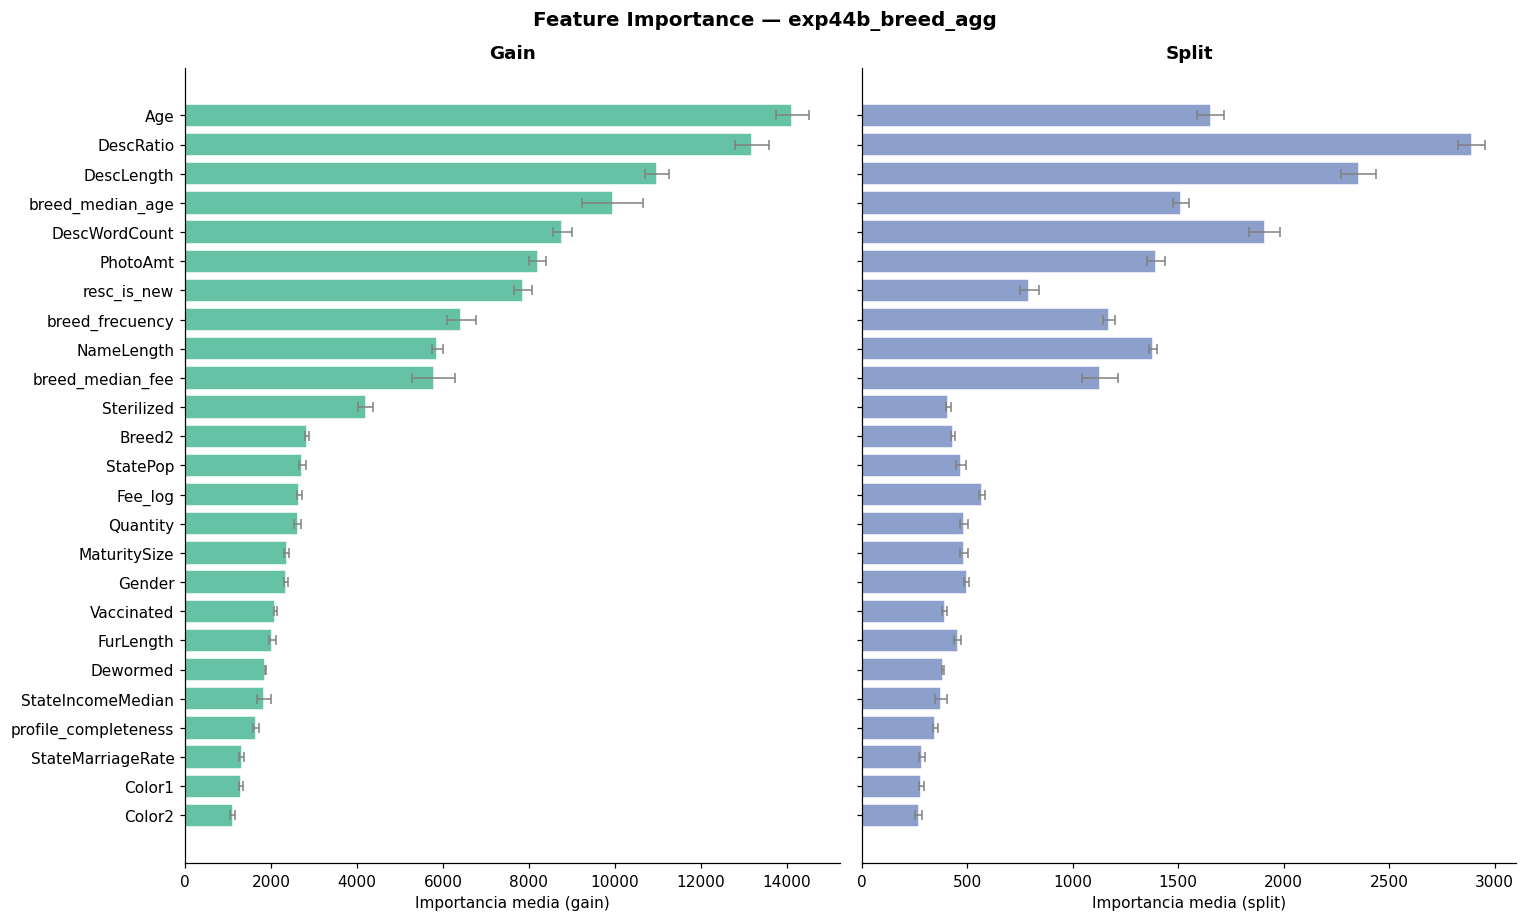

In [52]:
plot_results(y, [r['oof_preds'] for r in exp44b_breed_agg], title='exp44b_breed_agg')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp44b_breed_agg])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp44b_breed_agg')


Al excluir del modelo la variable cruda Breed1, el modelo pierde mucha fuerza que no se equipara con las variables incorporadas.
Por el momento no se incluirán.

## 4.5 Target Encoding

Variables de alta cardinalidad (`Breed1`) codificadas
con la media suavizada del target.

**Anti-leakage:** el parámetro `te_cols` le indica a `run_cv` que calcule
el encoding dentro de cada fold usando solo `y_tr`. El suavizado
hace que categorías con pocas observaciones tiren hacia la media global,
reduciendo el riesgo de overfitting en categorías raras.

In [53]:
TE_COLS = ['Breed1']

X_45 = df_fe[CURRENT_FEATURES + AUX_COLS]   

print(f'Columnas a encodear: {TE_COLS}')
print(f'Columnas generadas dentro del fold: {[c+"_te" for c in TE_COLS]}')
print('\n' + '='*55)
print('EXPERIMENTO 5: + Target Encoding (Breed1)')
print('='*55)

exp45_te = []
for seed in SEEDS:
    r = run_cv(
        X=X_45,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        agg_config=AGG_RESCUER,       
        agg_smoothing=AGG_SMOOTHING,     
        te_cols=TE_COLS,      
        te_smoothing='auto',
        aux_cols=AUX_COLS, 
        experiment_name=f'exp45_te{seed}',
        verbose=False,  
    )
    exp45_te.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp45_te, name='exp45_te')
delta(exp45_te, best_result)

Columnas a encodear: ['Breed1']
Columnas generadas dentro del fold: ['Breed1_te']

EXPERIMENTO 5: + Target Encoding (Breed1)
Seed 310019: QWK = 0.3704 ± 0.0168
Seed 320009: QWK = 0.3729 ± 0.0144
Seed 330017: QWK = 0.3692 ± 0.0139
Seed 340007: QWK = 0.3782 ± 0.0190
Seed 350029: QWK = 0.3688 ± 0.0116
  Referencia : QWK = 0.3735 ± 0.0140  (n=25 folds)
  Nuevo      : QWK = 0.3719 ± 0.0157  (n=25 folds)
  ΔQWK       : -0.0016


-0.0016116985811598372

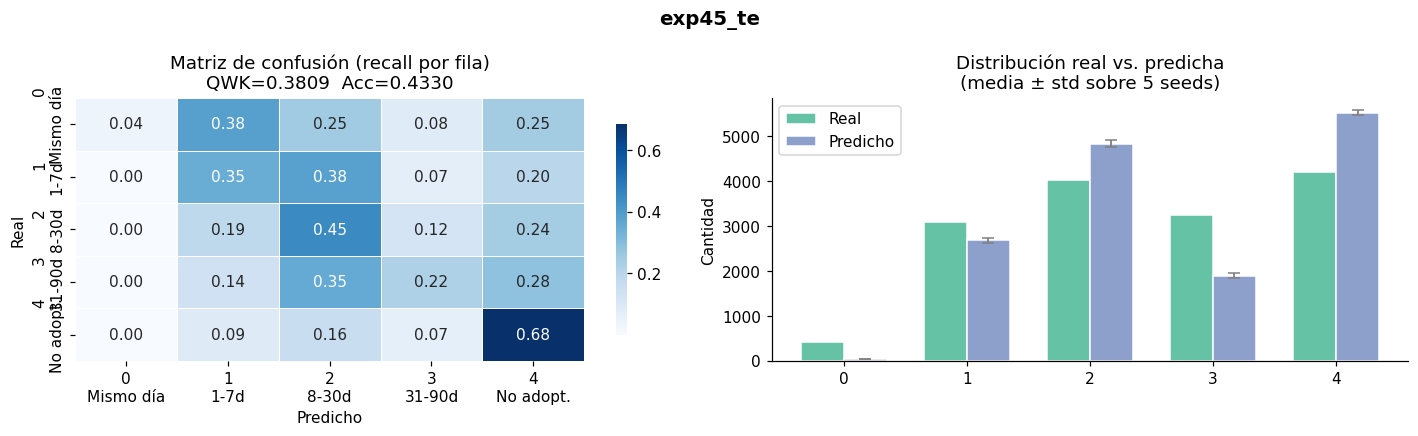

              precision    recall  f1-score   support

  0-MismoDía       0.54      0.04      0.07       410
  1-1ªSemana       0.38      0.35      0.36      3083
    2-1erMes       0.37      0.45      0.40      4029
 3-2do3erMes       0.42      0.22      0.29      3236
  4-NoAdopt.       0.52      0.68      0.59      4193

    accuracy                           0.43     14951
   macro avg       0.44      0.35      0.34     14951
weighted avg       0.43      0.43      0.41     14951



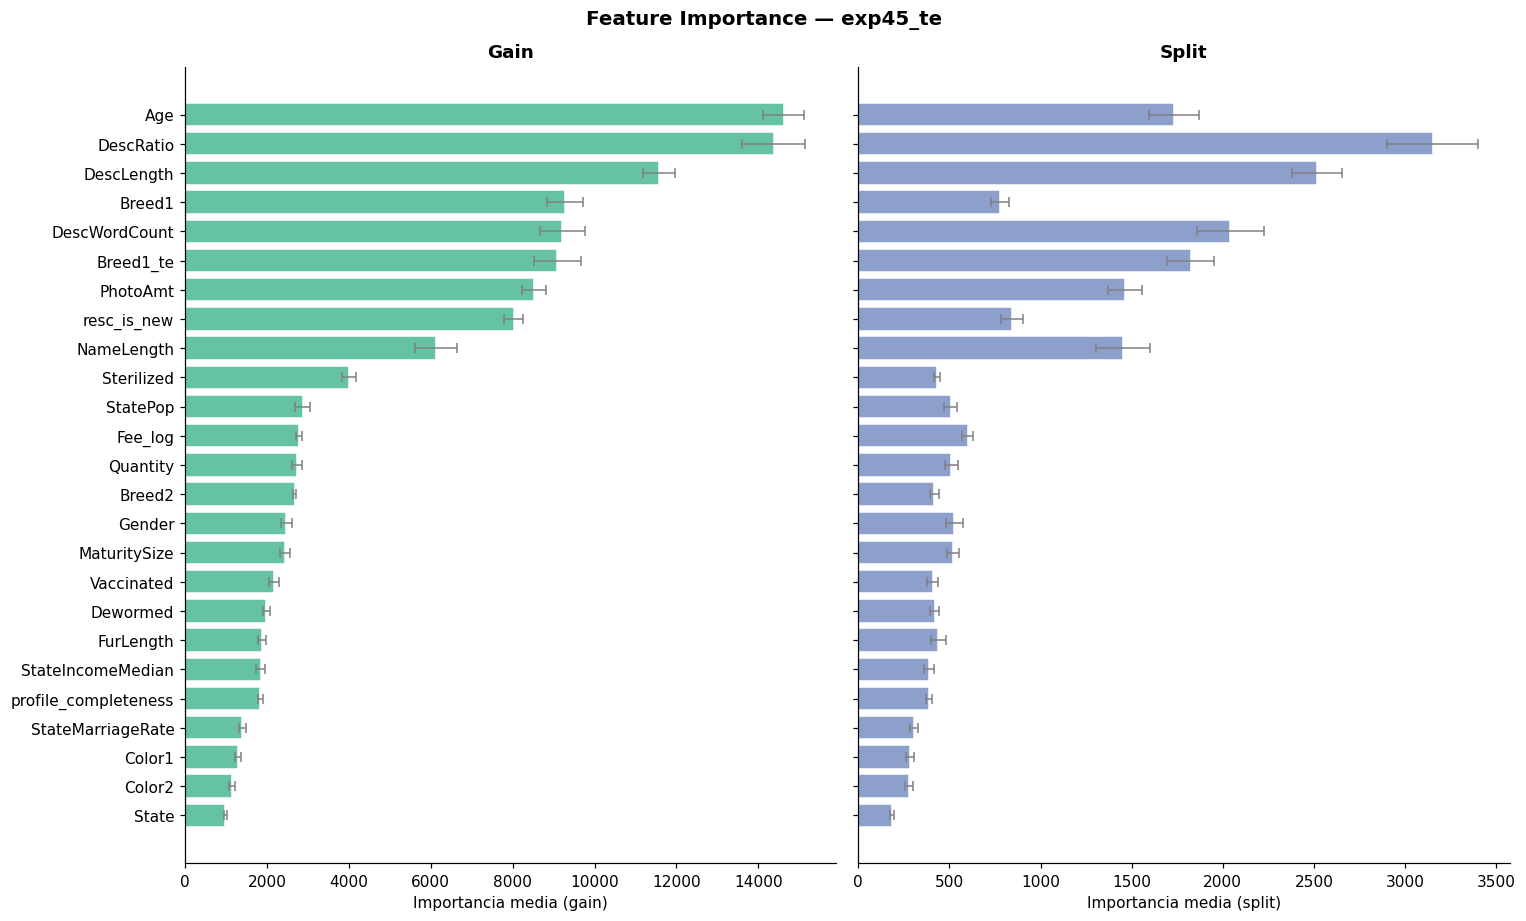

In [54]:
plot_results(y, [r['oof_preds'] for r in exp45_te], title='exp45_te')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp45_te])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp45_te')


---
# 5 Análisis de texto

## 5.1 Análisis de emociones a través de lexicon - NLTK
Se utilizará la librería NLTK para identificar el sentimiento de la Descripción a través de Lexicon.

In [55]:
def limpiar_para_vader(texto: str) -> str:
    if not texto or not isinstance(texto, str):
        return "."
    texto = unicodedata.normalize("NFKC", texto)
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)
    texto = re.sub(r'@\w+|#\w+', '', texto)
    texto = re.sub(r'[\x00-\x1f\x7f-\x9f]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto if texto else "."

df_fe['DescriptionClean'] = (
    df_fe['Description']
    .fillna('')
    .str.strip()
    .apply(limpiar_para_vader) 
    .str[:512]                 
)

sia = SentimentIntensityAnalyzer()

def vader_sentiment(texto):
    if not texto:
        return None, None, None, None
    scores = sia.polarity_scores(texto)
    return scores['pos'], scores['neg'], scores['neu'], scores['compound']

(df_fe['vader_pos'],
 df_fe['vader_neg'],
 df_fe['vader_neu'],
 df_fe['vader_compound']) = zip(*df_fe['DescriptionClean'].apply(vader_sentiment))

def vader_label(compound):
    if compound is None:
        return None
    if compound >= 0.05:
        return 'POS'
    elif compound <= -0.05:
        return 'NEG'
    else:
        return 'NEU'

df_fe['vader_label'] = df_fe['vader_compound'].apply(vader_label)

Vemos algunos ejemplos para asegurar que la categorización sea correcta.
El modelo tiene alguna dificultad para identificar los negativos. Los casos neutrales tienden a ser descripciones muy cortas, muy técnicas o en otro idioma.

In [56]:
print(f'Distribución de Sentiment (Vader): {df_fe["vader_label"].value_counts(dropna=False)}')

# Ejemplos de Sentiment Positivo
pos_examples = df_fe[df_fe['vader_label'] == 'POS']['DescriptionClean'].head(10)
for i, texto in enumerate(pos_examples):
    print(f"\n--- Ejemplo POS {i+1} ---")
    print(texto)

# Ejemplos de Sentiment Neutro
neu_examples = df_fe[df_fe['vader_label'] == 'NEU']['DescriptionClean'].head(10)
for i, texto in enumerate(neu_examples):
    print(f"\n--- Ejemplo NEU {i+1} ---")
    print(texto)

# Ejemplos de Sentiment Negativo
neg_examples = df_fe[df_fe['vader_label'] == 'NEG']['DescriptionClean'].head(10)
for i, texto in enumerate(neg_examples):
    print(f"\n--- Ejemplo NEG {i+1} ---")
    print(texto)

Distribución de Sentiment (Vader): vader_label
POS    12859
NEU     1310
NEG      782
Name: count, dtype: int64

--- Ejemplo POS 1 ---
Ollie was rescued from the construction site behind my house. He is quite the manja type and loves to play. He makes a good companion and playmate for young children. He is quite the handsome chap with a distinct mark on his face like a beauty mark.

--- Ejemplo POS 2 ---
This puppy rescued from DBKL pound last wednesday, and been sent to vet for check out. Pls give this lovely puppy a loving home if you can.

--- Ejemplo POS 3 ---
He is cute and fun to be with.

--- Ejemplo POS 4 ---
Leo is a 1 year old male cat and has been a very sweet cat. He likes to lick you so if you are ticklish be prepared ! Cookie is an almost carbon copy of Leo. They have been together for a long time and i hope the adopter could adopt them both. They like to sit next to you, lie down asking for you to pet them. Very manja cats. I had to let them go since the neighbours were 

In [57]:
label_map = {'POS': 1, 'NEU': 0, 'NEG': -1}
df_fe['vader_label_enc'] = df_fe['vader_label'].map(label_map)

NEW_INT = ['vader_label_enc']
CURRENT_FEATURES_51 = CURRENT_FEATURES + NEW_INT
X_51 = df_fe[CURRENT_FEATURES_51 + AUX_COLS ]
categoricals_51 = categoricals + NEW_INT

print(f'Features nuevas (5.1): {NEW_INT}')
print(f'Total features: {len(CURRENT_FEATURES_51)}')
print('\n' + '='*55)
print('EXPERIMENTO 5.1: + Sentiment Analysis (Lexicon)')
print('='*55)

exp51_sentiment_lexicon = []

for seed in SEEDS:
    r = run_cv(
        X=X_51,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals_51,
        #te_cols=TE_COLS,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,       # rescatistas con <n publicaciones tiran a la media
        aux_cols=AUX_COLS, 
        experiment_name=f'exp51_sentiment_lexicon{seed}',
        verbose=False,  
    )
    exp51_sentiment_lexicon.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp51_sentiment_lexicon, name='exp51_sentiment_lexicon')
delta(exp51_sentiment_lexicon, best_result)

Features nuevas (5.1): ['vader_label_enc']
Total features: 30

EXPERIMENTO 5.1: + Sentiment Analysis (Lexicon)
Seed 310019: QWK = 0.3703 ± 0.0187
Seed 320009: QWK = 0.3678 ± 0.0159
Seed 330017: QWK = 0.3724 ± 0.0122
Seed 340007: QWK = 0.3789 ± 0.0168
Seed 350029: QWK = 0.3703 ± 0.0154
  Referencia : QWK = 0.3735 ± 0.0140  (n=25 folds)
  Nuevo      : QWK = 0.3719 ± 0.0164  (n=25 folds)
  ΔQWK       : -0.0016


-0.001564272239456932

Dado que la categorización puede haber tenido algunos errores, se realizará un nuevo experimento tomando la variable de probabilidad de ser Positivo

In [58]:

NEW_INT = [#'vader_pos',
           'vader_neg']
CURRENT_FEATURES_51b = CURRENT_FEATURES + AUX_COLS + NEW_INT
X_51b = df_fe[CURRENT_FEATURES_51b]

print(f'Features nuevas (5.1): {NEW_INT}')
print(f'Total features: {len(CURRENT_FEATURES_51b)}')
print('\n' + '='*55)
print('EXPERIMENTO 5.1b: + Sentiment Analysis (Lexicon)')
print('='*55)

exp51b_sentiment_lexicon = []

for seed in SEEDS:
    r = run_cv(
        X=X_51b,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        #te_cols=TE_COLS,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,       # rescatistas con <n publicaciones tiran a la media
        aux_cols=AUX_COLS, 
        experiment_name=f'exp51b_sentiment_lexicon{seed}',
        verbose=False,  
    )
    exp51b_sentiment_lexicon.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp51b_sentiment_lexicon, name='exp51b_sentiment_lexicon')
delta(exp51b_sentiment_lexicon, best_result)

Features nuevas (5.1): ['vader_neg']
Total features: 31

EXPERIMENTO 5.1b: + Sentiment Analysis (Lexicon)
Seed 310019: QWK = 0.3672 ± 0.0242
Seed 320009: QWK = 0.3784 ± 0.0144
Seed 330017: QWK = 0.3718 ± 0.0069
Seed 340007: QWK = 0.3749 ± 0.0190
Seed 350029: QWK = 0.3767 ± 0.0163
  Referencia : QWK = 0.3735 ± 0.0140  (n=25 folds)
  Nuevo      : QWK = 0.3738 ± 0.0176  (n=25 folds)
  ΔQWK       : +0.0003


0.00026496200942666137

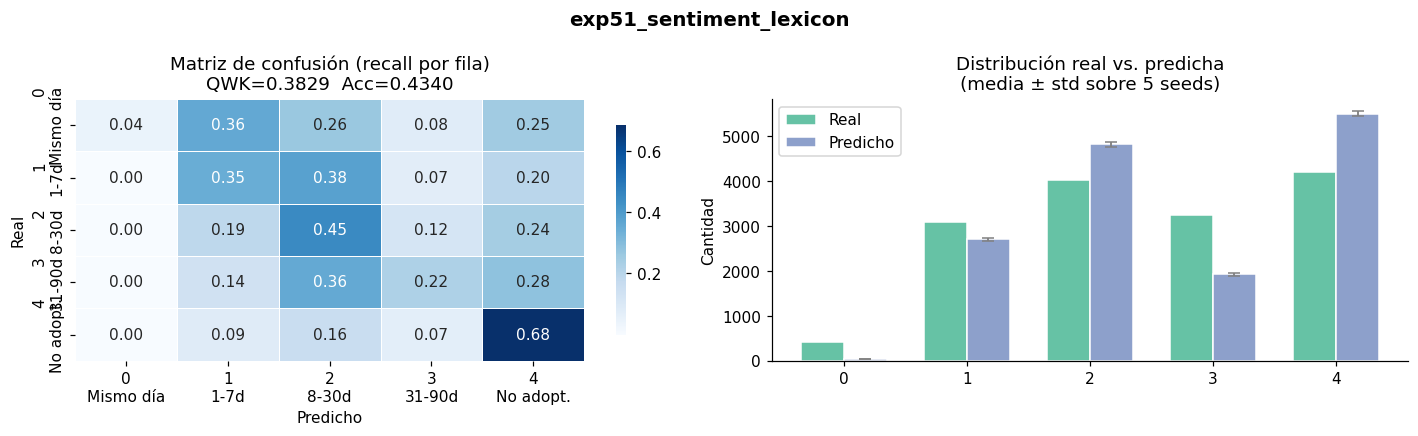

              precision    recall  f1-score   support

  0-MismoDía       0.60      0.04      0.08       410
  1-1ªSemana       0.38      0.35      0.36      3083
    2-1erMes       0.37      0.45      0.40      4029
 3-2do3erMes       0.41      0.22      0.29      3236
  4-NoAdopt.       0.52      0.68      0.59      4193

    accuracy                           0.43     14951
   macro avg       0.46      0.35      0.35     14951
weighted avg       0.43      0.43      0.42     14951



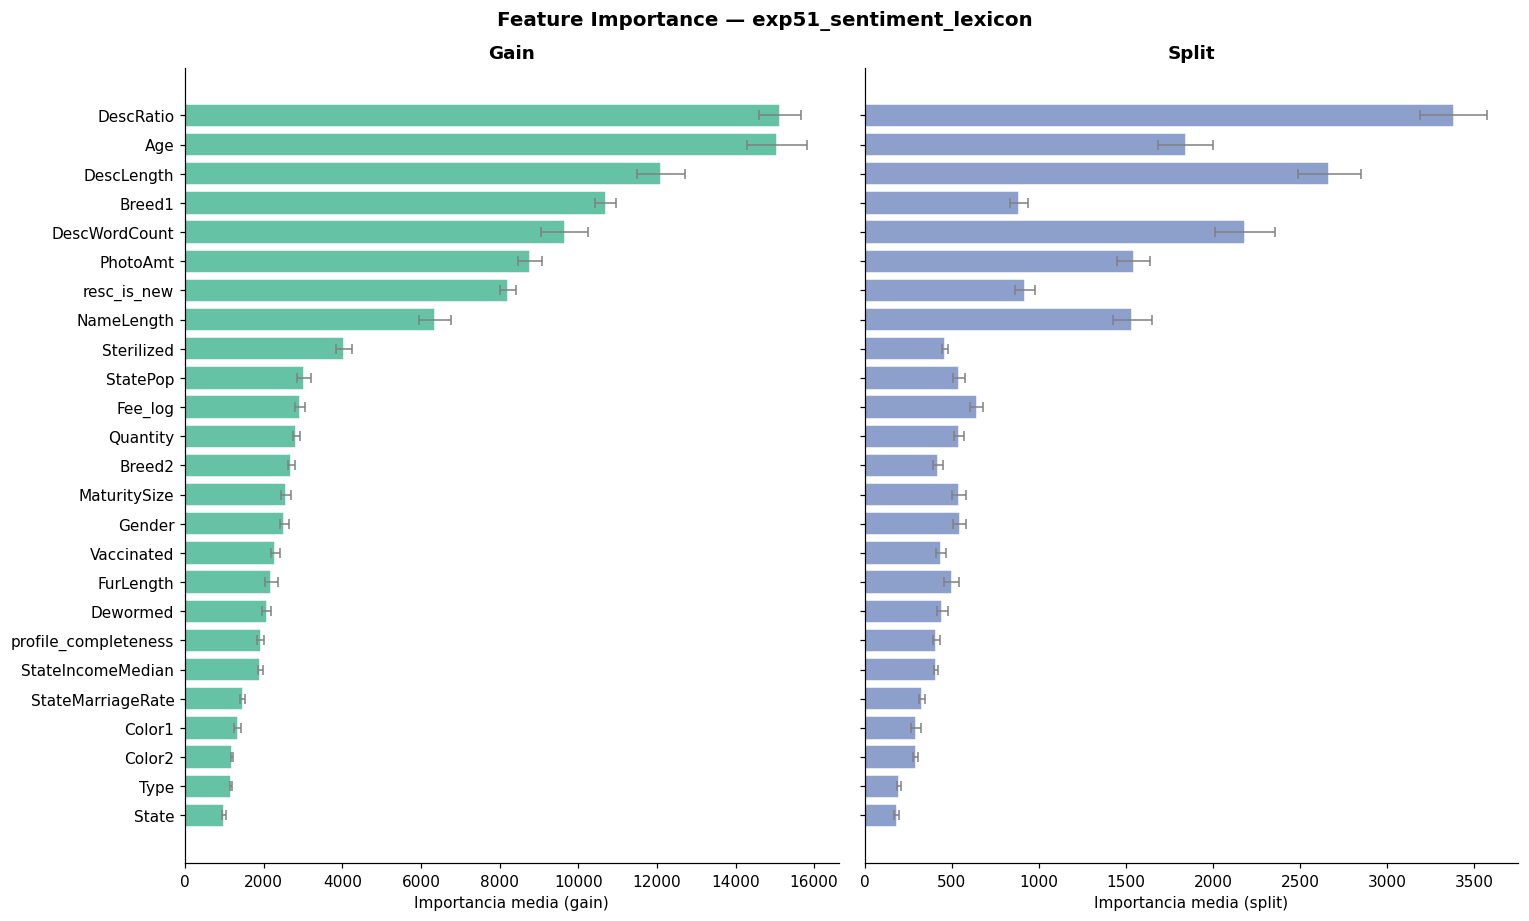

In [59]:
plot_results(y, [r['oof_preds'] for r in exp51_sentiment_lexicon], title='exp51_sentiment_lexicon')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp51_sentiment_lexicon])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp51_sentiment_lexicon')


La feature de sentimiento negativo aporta en QWK, pero aumenta la inestabilidad. Se aplicarán otras técnicas de análisis de texto y se decidirá la incorporación de las features según el efecto que tengan combinadas.

## 5.2 Análisis de emociones a través de transformers - Pysentimiento
Se utilizará la librería Pysentimiento que permite identificar emociones a través de transformers.

In [ ]:
# --- Configuración ---
BATCH_SIZE = 32
CHECKPOINT_DIR = 'checkpoints_petfinder'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

pet_ids = df_fe['PetID'].tolist()
texts_transformer = (                                    # para pysentimiento
    df_fe['Description']
    .fillna('.')
    .apply(lambda t: re.sub(r'\s+', ' ', unicodedata.normalize("NFKC", str(t))).strip() or '.')
    .str[:512]
    .tolist()
)

In [61]:
# --- Función con checkpoints por PetID ---
def procesar_con_checkpoints(analyzer, pet_ids, texts, task_name, batch_size=32):
    checkpoint_pkl = os.path.join(CHECKPOINT_DIR, f"text_transformer_{task_name}_train.pkl")

    # Cargar checkpoint si existe
    if os.path.exists(checkpoint_pkl):
        try:
            with open(checkpoint_pkl, 'rb') as f:
                results_dict = pickle.load(f)
            print(f"⚡ Checkpoint encontrado: {len(results_dict)} PetIDs ya procesados. Retomando...")
        except (EOFError, pickle.UnpicklingError):
            print("⚠️ Checkpoint corrupto, empezando desde cero...")
            results_dict = {}
    else:
        results_dict = {}
        print("🚀 Empezando desde cero...")

    # Filtrar solo los PetIDs que faltan procesar
    pendientes = [(pid, txt) for pid, txt in zip(pet_ids, texts) if pid not in results_dict]
    print(f"📋 Pendientes: {len(pendientes)} | Ya procesados: {len(results_dict)}")

    for i in tqdm(range(0, len(pendientes), batch_size), desc=task_name):
        batch_items  = pendientes[i:i + batch_size]
        batch_ids    = [item[0] for item in batch_items]
        batch_texts  = [item[1] if item[1] else "." for item in batch_items]

        try:
            batch_results = analyzer.predict(batch_texts)
            for pid, result in zip(batch_ids, batch_results):
                results_dict[pid] = result
        except Exception as e:
            print(f"\n⚠️ Error en batch {i}: {e}. Procesando uno por uno...")
            for pid, text in zip(batch_ids, batch_texts):
                try:
                    results_dict[pid] = analyzer.predict(text)
                except:
                    results_dict[pid] = None

        # Guardado atómico cada 10 batches
        if (i // batch_size) % 10 == 0:
            tmp_file = checkpoint_pkl + '.tmp'
            with open(tmp_file, 'wb') as f:
                pickle.dump(results_dict, f)
            os.replace(tmp_file, checkpoint_pkl)

    # Guardado final atómico
    tmp_file = checkpoint_pkl + '.tmp'
    with open(tmp_file, 'wb') as f:
        pickle.dump(results_dict, f)
    os.replace(tmp_file, checkpoint_pkl)

    print(f"✓ Total procesados: {len(results_dict)}")
    return results_dict

In [62]:
# --- Emociones ---
print("Cargando modelo de emociones...")
emotion_analyzer = create_analyzer(task="emotion", lang="en")

print("Procesando emociones...")
emotion_results_dict = procesar_con_checkpoints(
    analyzer=emotion_analyzer,
    pet_ids=pet_ids,
    texts=texts_transformer,
    task_name="emotion"
)

# Detectar emociones disponibles dinámicamente
_sample = emotion_analyzer.predict("test")
emotions = list(_sample.probas.keys())
print(f"Emociones detectadas: {emotions}")

# Asignar al dataframe por PetID (seguro ante reordenamientos)
df_fe['emotion_label'] = df_fe['PetID'].map(
    lambda pid: emotion_results_dict[pid].output if emotion_results_dict.get(pid) else None
)
for emo in emotions:
    df_fe[f'emotion_{emo}'] = df_fe['PetID'].map(
        lambda pid: emotion_results_dict[pid].probas.get(emo, 0) if emotion_results_dict.get(pid) else None
    )

print("✓ Emociones asignadas al dataframe")

# Definir el mapa de emociones
emotion_map = {
    'others': 0,
    'joy': 1,
    'sadness': 2,
    'anger': 3,
    'fear': 4,
    'surprise': 5,
    'disgust': 6
}

# Aplicar a la columna
df_fe['emotion_label_encoded'] = df_fe['emotion_label'].map(emotion_map)

Cargando modelo de emociones...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1936.11it/s]


Procesando emociones...
⚡ Checkpoint encontrado: 14951 PetIDs ya procesados. Retomando...
📋 Pendientes: 0 | Ya procesados: 14951


emotion: 0it [00:00, ?it/s]


✓ Total procesados: 14951
Emociones detectadas: ['others', 'joy', 'sadness', 'anger', 'surprise', 'disgust', 'fear']
✓ Emociones asignadas al dataframe


El modelo tiene dificultades para identificar la emoción principal de la gran mayoría de descripciones, ya que categoriza 12679 como 'Otros'. Cuando define una emoción, parece identificarla bien.


In [63]:
print(f'Distribución de Emociones: {df_fe["emotion_label_encoded"].value_counts(dropna=False)}')

# Ejemplos de Emociones
other_examples = df_fe[df_fe['emotion_label_encoded'] == 0]['DescriptionClean'].head(5)
for i, texto in enumerate(other_examples):
    print(f"\n--- Ejemplo OTHER {i+1} ---")
    print(texto)

# Ejemplos de Emociones
joy_examples = df_fe[df_fe['emotion_label_encoded'] == 1]['DescriptionClean'].head(5)
for i, texto in enumerate(joy_examples):
    print(f"\n--- Ejemplo JOY {i+1} ---")
    print(texto)

# Ejemplos de Emociones
sadness_examples = df_fe[df_fe['emotion_label_encoded'] == 2]['DescriptionClean'].head(5)
for i, texto in enumerate(sadness_examples):
    print(f"\n--- Ejemplo SADNESS {i+1} ---")
    print(texto)

# Ejemplos de Emociones
anger_examples = df_fe[df_fe['emotion_label_encoded'] == 3]['DescriptionClean'].head(5)
for i, texto in enumerate(anger_examples):
    print(f"\n--- Ejemplo ANGER {i+1} ---")
    print(texto)

Distribución de Emociones: emotion_label_encoded
0    12656
1     1487
2      614
4      123
6       48
5       15
3        8
Name: count, dtype: int64

--- Ejemplo OTHER 1 ---
Ollie was rescued from the construction site behind my house. He is quite the manja type and loves to play. He makes a good companion and playmate for young children. He is quite the handsome chap with a distinct mark on his face like a beauty mark.

--- Ejemplo OTHER 2 ---
went to teluk kumba kuanthai restaurant saw this female puppies alone by the beach.. Adopters must vaccinate, spay and keep puppy indoors/fenced Call/WhatsApp: Address: teluk kumba

--- Ejemplo OTHER 3 ---
I found Pup with 2 other brothers who were abandoned and were in terrible condition. He is the is doing great now and is looking for a home. He is suspected only 6 weeks old and we will be taking them for the first round of shots this week. I will pre-pay a vet for the remaining shots and vaccinations all the you have to do is take him ther

In [64]:


NEW_INT = ['emotion_label_encoded']
CURRENT_FEATURES_52 = CURRENT_FEATURES + NEW_INT
X_52 = df_fe[CURRENT_FEATURES_52 + AUX_COLS]
categoricals_52 = categoricals + NEW_INT

print(f'Features nuevas (5.2): {NEW_INT}')
print(f'Total features: {len(CURRENT_FEATURES_52)}')
print('\n' + '='*55)
print('EXPERIMENTO 5.2: + Emotion Analysis (Transformers)')
print('='*55)

exp52_emotion = []

for seed in SEEDS:
    r = run_cv(
        X=X_52,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals_52,
        #te_cols=TE_COLS,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,       
        aux_cols=AUX_COLS, 
        experiment_name=f'exp52_emotion{seed}',
        verbose=False,  
    )
    exp52_emotion.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp52_emotion, name='exp52_emotion')
delta(exp52_emotion, best_result)

Features nuevas (5.2): ['emotion_label_encoded']
Total features: 30

EXPERIMENTO 5.2: + Emotion Analysis (Transformers)
Seed 310019: QWK = 0.3710 ± 0.0177
Seed 320009: QWK = 0.3801 ± 0.0151
Seed 330017: QWK = 0.3701 ± 0.0121
Seed 340007: QWK = 0.3792 ± 0.0153
Seed 350029: QWK = 0.3709 ± 0.0134
  Referencia : QWK = 0.3735 ± 0.0140  (n=25 folds)
  Nuevo      : QWK = 0.3743 ± 0.0155  (n=25 folds)
  ΔQWK       : +0.0007


0.000743117301631957

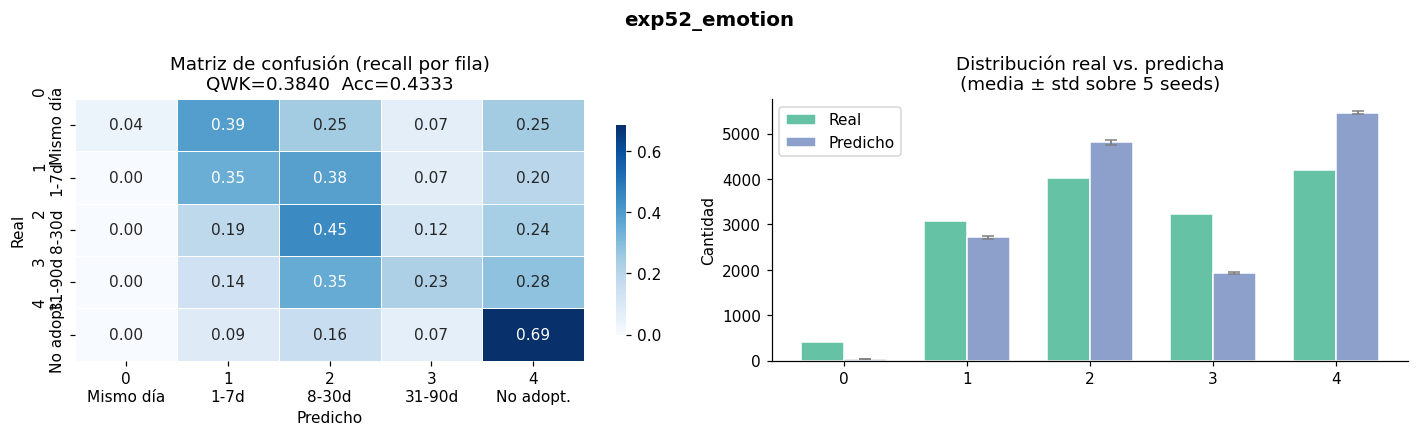

              precision    recall  f1-score   support

  0-MismoDía       0.65      0.04      0.08       410
  1-1ªSemana       0.38      0.35      0.36      3083
    2-1erMes       0.37      0.45      0.40      4029
 3-2do3erMes       0.41      0.23      0.29      3236
  4-NoAdopt.       0.53      0.69      0.60      4193

    accuracy                           0.43     14951
   macro avg       0.47      0.35      0.35     14951
weighted avg       0.43      0.43      0.42     14951



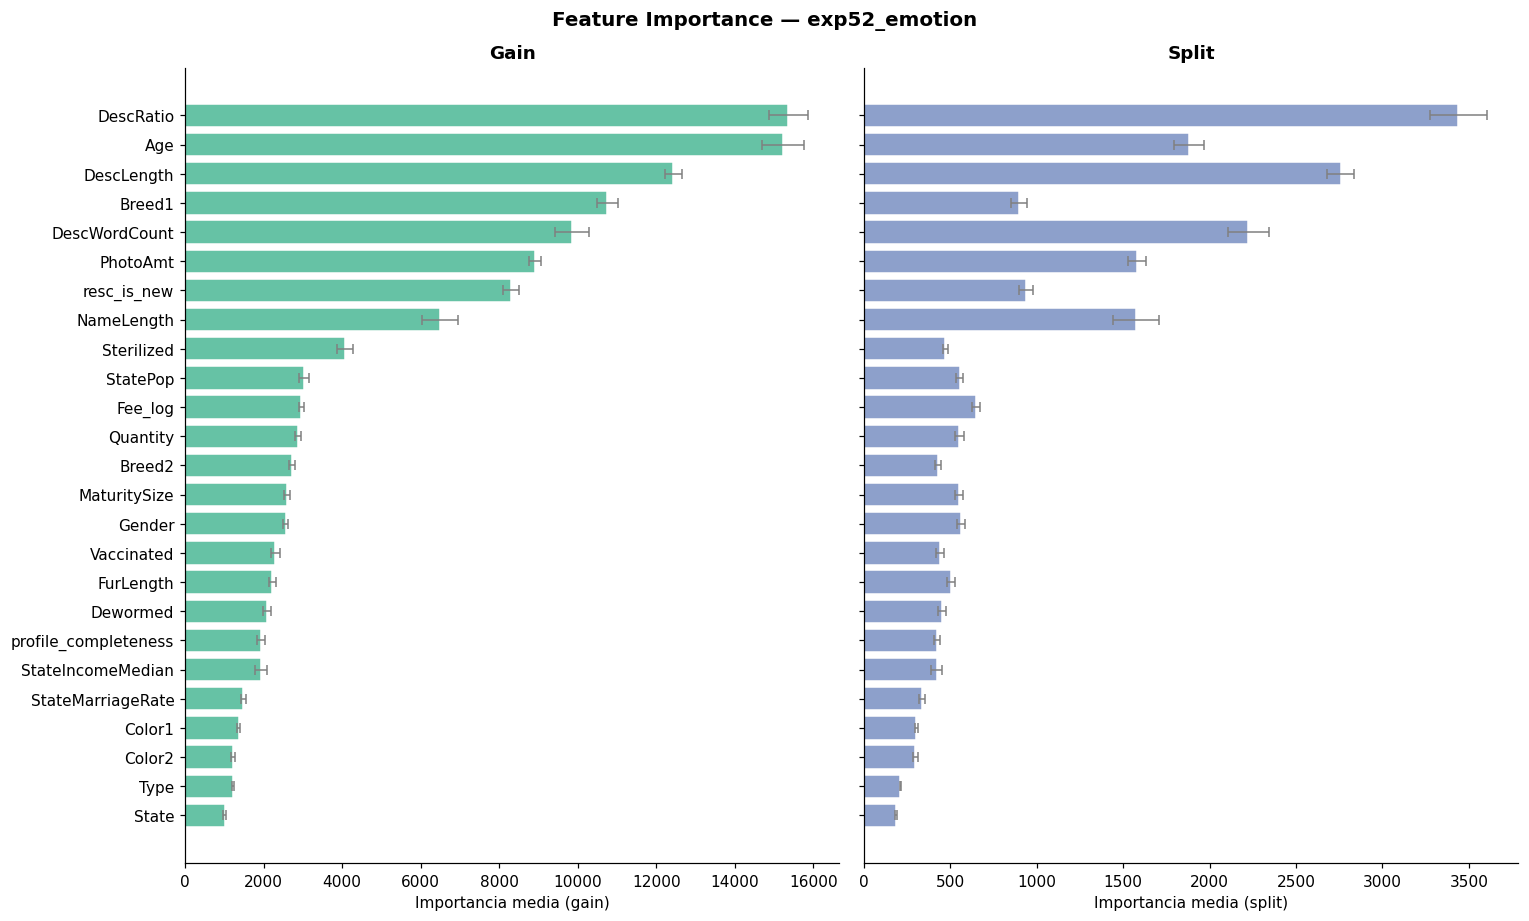

In [65]:
plot_results(y, [r['oof_preds'] for r in exp52_emotion], title='exp52_emotion')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp52_emotion])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=25, title='Feature Importance — exp52_emotion')


La gran mayoría de los registros tienen como sentiment asignado 'others'. Se realizará un segundo experimento tomando las probabilidades de las variables 'emotion_joy' y 'emotion_sadness'

In [66]:
NEW_INT = ['emotion_sadness', 
           #'emotion_joy', 
           #'emotion_anger'
           ]

CURRENT_FEATURES_52_so = CURRENT_FEATURES + NEW_INT
X_52_so = df_fe[CURRENT_FEATURES_52_so + AUX_COLS]

print(f'Features nuevas (5.2): {NEW_INT}')
print(f'Total features: {len(CURRENT_FEATURES_52_so)}')
print('\n' + '='*55)
print('EXPERIMENTO 5.2: + Emotion Analysis sin Others (Transformers)')
print('='*55)

exp52_emotion_so = []

for seed in SEEDS:
    r = run_cv(
        X=X_52_so,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        #te_cols=TE_COLS,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,       # rescatistas con <n publicaciones tiran a la media
        aux_cols=AUX_COLS, 
        experiment_name=f'exp52_emotion_so{seed}',
        verbose=False,  
    )
    exp52_emotion_so.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp52_emotion_so, name='exp52_emotion_so')
delta(exp52_emotion_so, best_result)

Features nuevas (5.2): ['emotion_sadness']
Total features: 30

EXPERIMENTO 5.2: + Emotion Analysis sin Others (Transformers)
Seed 310019: QWK = 0.3688 ± 0.0148
Seed 320009: QWK = 0.3738 ± 0.0112
Seed 330017: QWK = 0.3717 ± 0.0084
Seed 340007: QWK = 0.3781 ± 0.0133
Seed 350029: QWK = 0.3774 ± 0.0126
  Referencia : QWK = 0.3735 ± 0.0140  (n=25 folds)
  Nuevo      : QWK = 0.3739 ± 0.0127  (n=25 folds)
  ΔQWK       : +0.0004


0.0004347163920469521

Probando con las variables obtenidas, incorporar sólo la correspondiente a descripciones tristes aporta el mejor desempeño: un modelo que mejora en QWK y en estabilidad.

## 5.3 Combinación de Sentiment y Emociones
Se evaluará si los experimentos son complementarios

In [67]:
NEW_INT = ['emotion_sadness', 
           'vader_neg',
           #'vader_label_enc',
           #'emotion_joy', 
           #'emotion_anger'
           ]

CURRENT_FEATURES_53 = CURRENT_FEATURES + NEW_INT
X_53 = df_fe[CURRENT_FEATURES_53 + AUX_COLS]

print(f'Features nuevas (5.3): {NEW_INT}')
print(f'Total features: {len(CURRENT_FEATURES_53)}')
print('\n' + '='*55)
print('EXPERIMENTO 5.3: + Combinación Emotion (Sadness) + Sentiment (Vader)')
print('='*55)

exp53_combination = []

for seed in SEEDS:
    r = run_cv(
        X=X_53,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        te_cols=TE_COLS,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,       # rescatistas con <n publicaciones tiran a la media
        aux_cols=AUX_COLS, 
        experiment_name=f'exp53_combination{seed}',
        verbose=False,  
    )
    exp53_combination.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp53_combination, name='exp53_combination')
delta(exp53_combination, best_result)

Features nuevas (5.3): ['emotion_sadness', 'vader_neg']
Total features: 31

EXPERIMENTO 5.3: + Combinación Emotion (Sadness) + Sentiment (Vader)
Seed 310019: QWK = 0.3714 ± 0.0297
Seed 320009: QWK = 0.3787 ± 0.0121
Seed 330017: QWK = 0.3740 ± 0.0123
Seed 340007: QWK = 0.3792 ± 0.0187
Seed 350029: QWK = 0.3743 ± 0.0115
  Referencia : QWK = 0.3735 ± 0.0140  (n=25 folds)
  Nuevo      : QWK = 0.3755 ± 0.0185  (n=25 folds)
  ΔQWK       : +0.0020


0.001993756208329145

La señal mejora, pero aumenta mucho el desvío. Por ahora no se incorporarán, se evaluarán combinaciones con el siguiente experimento.

## 5.4 Extracción de Embeddings con Transformers - SentenceTransformer
Se realizará un proceso de extracción de Embeddings, aplicación de PCA para reducción de dimensionalidad, e incorporación de los N componentes más explicativos.

In [ ]:
CHECKPOINT_DIR = 'checkpoints_petfinder'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BATCH_SIZE = 64

# --- Cargar modelo ---
print("Cargando MiniLM...")
text_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✓ Modelo cargado")

def extraer_embeddings_texto(model, pet_ids, texts, checkpoint_dir, batch_size=64):
    checkpoint_pkl = os.path.join(checkpoint_dir, "text_embeddings_train.pkl")

    # Cargar checkpoint si existe
    if os.path.exists(checkpoint_pkl):
        try:
            with open(checkpoint_pkl, 'rb') as f:
                embeddings_dict = pickle.load(f)
            print(f"⚡ Checkpoint encontrado: {len(embeddings_dict)} PetIDs ya procesados. Retomando...")
        except (EOFError, pickle.UnpicklingError):
            print("⚠️ Checkpoint corrupto, empezando desde cero...")
            embeddings_dict = {}
    else:
        embeddings_dict = {}
        print("🚀 Empezando desde cero...")

    # Filtrar pendientes
    pendientes = [(pid, txt) for pid, txt in zip(pet_ids, texts) if pid not in embeddings_dict]
    print(f"📋 Pendientes: {len(pendientes)} | Ya procesados: {len(embeddings_dict)}")

    for i in tqdm(range(0, len(pendientes), batch_size), desc="text_embeddings"):
        batch_items  = pendientes[i:i + batch_size]
        batch_ids    = [item[0] for item in batch_items]
        batch_texts  = [item[1] if item[1] else "." for item in batch_items]

        try:
            batch_embs = model.encode(batch_texts, convert_to_numpy=True, show_progress_bar=False)
            for pid, emb in zip(batch_ids, batch_embs):
                embeddings_dict[pid] = emb
        except Exception as e:
            print(f"\n⚠️ Error en batch {i}: {e}. Procesando uno por uno...")
            for pid, text in zip(batch_ids, batch_texts):
                try:
                    embeddings_dict[pid] = model.encode(text, convert_to_numpy=True)
                except:
                    embeddings_dict[pid] = None

        # Guardado atómico cada 10 batches
        if (i // batch_size) % 10 == 0:
            tmp_file = checkpoint_pkl + '.tmp'
            with open(tmp_file, 'wb') as f:
                pickle.dump(embeddings_dict, f)
            os.replace(tmp_file, checkpoint_pkl)

    # Guardado final atómico
    tmp_file = checkpoint_pkl + '.tmp'
    with open(tmp_file, 'wb') as f:
        pickle.dump(embeddings_dict, f)
    os.replace(tmp_file, checkpoint_pkl)

    print(f"✓ Total procesados: {len(embeddings_dict)}")
    return embeddings_dict

# --- Extraer ---
pet_ids = df_fe['PetID'].tolist()
texts_embeddings   = (                         
    df_fe['Description']
    .fillna('.')
    .apply(lambda t: re.sub(r'\s+', ' ', unicodedata.normalize("NFKC", str(t))).strip() or '.')
    .str[:512]
    .tolist()
)
text_embeddings_dict = extraer_embeddings_texto(text_model, pet_ids, texts_embeddings, CHECKPOINT_DIR)

# --- Convertir a matriz alineada con df_fe ---
text_embeddings_matrix = np.array([
    text_embeddings_dict[pid] if text_embeddings_dict.get(pid) is not None
    else np.zeros(384)
    for pid in df_fe['PetID']
])
print(f"✓ Shape matriz de texto: {text_embeddings_matrix.shape}")  # (15000, 384)

Cargando MiniLM...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2313.87it/s]


✓ Modelo cargado
⚡ Checkpoint encontrado: 14951 PetIDs ya procesados. Retomando...
📋 Pendientes: 0 | Ya procesados: 14951


text_embeddings: 0it [00:00, ?it/s]


✓ Total procesados: 14951
✓ Shape matriz de texto: (14951, 384)


Se optimizará el número de componentes a extraer en la optimización bayesiana. Para avanzar con los experimentos haremos un análisis breve del punto óptimo con los parámetros baseline.

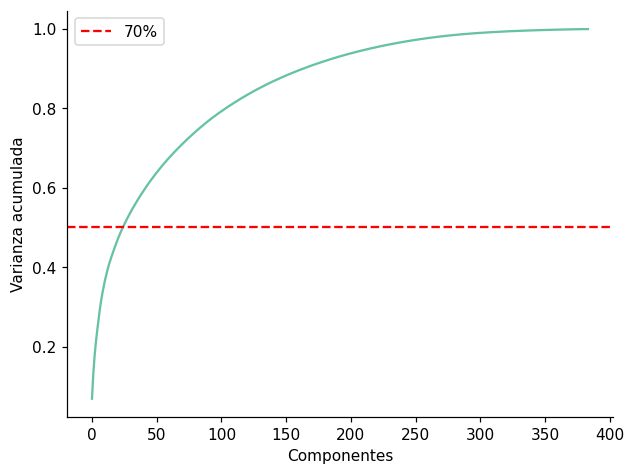

In [69]:
pca_full = PCA(random_state = SEED).fit(text_embeddings_matrix)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel("Componentes")
plt.ylabel("Varianza acumulada")
plt.axhline(0.50, color='r', linestyle='--', label='70%')
plt.legend()
plt.show()

In [70]:
text_embeddings_df = pd.DataFrame(
    text_embeddings_matrix,
    index=df_fe['PetID'],
    columns=[f'text_embedding_{i}' for i in range(384)]
)

df_fe = df_fe.join(text_embeddings_df, on='PetID')

NEW_INT = [f'text_embedding_{i}' for i in range(text_embeddings_matrix.shape[1])]

CURRENT_FEATURES_54 = CURRENT_FEATURES + NEW_INT
X_54 = df_fe[CURRENT_FEATURES_54 + AUX_COLS]
PCA_CONFIG_TEXT = {'text_embedding': 30}


print(f'Features nuevas (5.4): {NEW_INT}')
print(f'Total features: {len(CURRENT_FEATURES_54)}')
print('\n' + '='*55)
print('EXPERIMENTO 5.4: + Text Embeddings con PCA')
print('='*55)

exp54_text_embed = []

for seed in SEEDS:
    r = run_cv(
        X=X_54,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        #te_cols=TE_COLS,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,     
        pca_config = PCA_CONFIG_TEXT,
        aux_cols=AUX_COLS, 
        experiment_name=f'exp54_text_embed{seed}',
        verbose=False,  
    )
    exp54_text_embed.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp54_text_embed, name='exp54_text_embed')
delta(exp54_text_embed, best_result)

Features nuevas (5.4): ['text_embedding_0', 'text_embedding_1', 'text_embedding_2', 'text_embedding_3', 'text_embedding_4', 'text_embedding_5', 'text_embedding_6', 'text_embedding_7', 'text_embedding_8', 'text_embedding_9', 'text_embedding_10', 'text_embedding_11', 'text_embedding_12', 'text_embedding_13', 'text_embedding_14', 'text_embedding_15', 'text_embedding_16', 'text_embedding_17', 'text_embedding_18', 'text_embedding_19', 'text_embedding_20', 'text_embedding_21', 'text_embedding_22', 'text_embedding_23', 'text_embedding_24', 'text_embedding_25', 'text_embedding_26', 'text_embedding_27', 'text_embedding_28', 'text_embedding_29', 'text_embedding_30', 'text_embedding_31', 'text_embedding_32', 'text_embedding_33', 'text_embedding_34', 'text_embedding_35', 'text_embedding_36', 'text_embedding_37', 'text_embedding_38', 'text_embedding_39', 'text_embedding_40', 'text_embedding_41', 'text_embedding_42', 'text_embedding_43', 'text_embedding_44', 'text_embedding_45', 'text_embedding_46',

0.006085965590959752

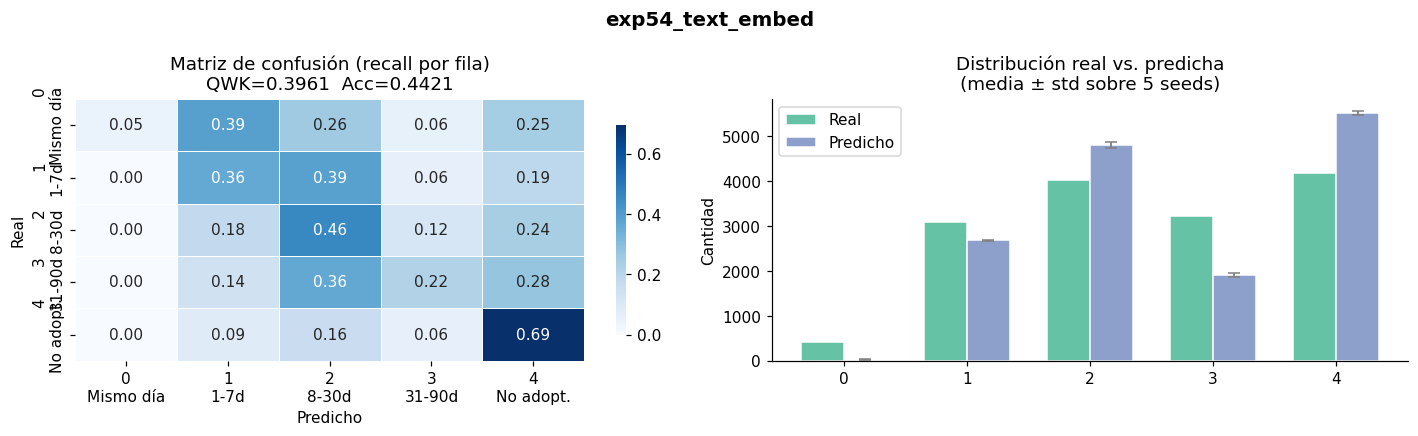

              precision    recall  f1-score   support

  0-MismoDía       0.69      0.05      0.09       410
  1-1ªSemana       0.39      0.36      0.38      3083
    2-1erMes       0.37      0.46      0.41      4029
 3-2do3erMes       0.44      0.22      0.29      3236
  4-NoAdopt.       0.53      0.69      0.60      4193

    accuracy                           0.44     14951
   macro avg       0.48      0.36      0.35     14951
weighted avg       0.44      0.44      0.42     14951



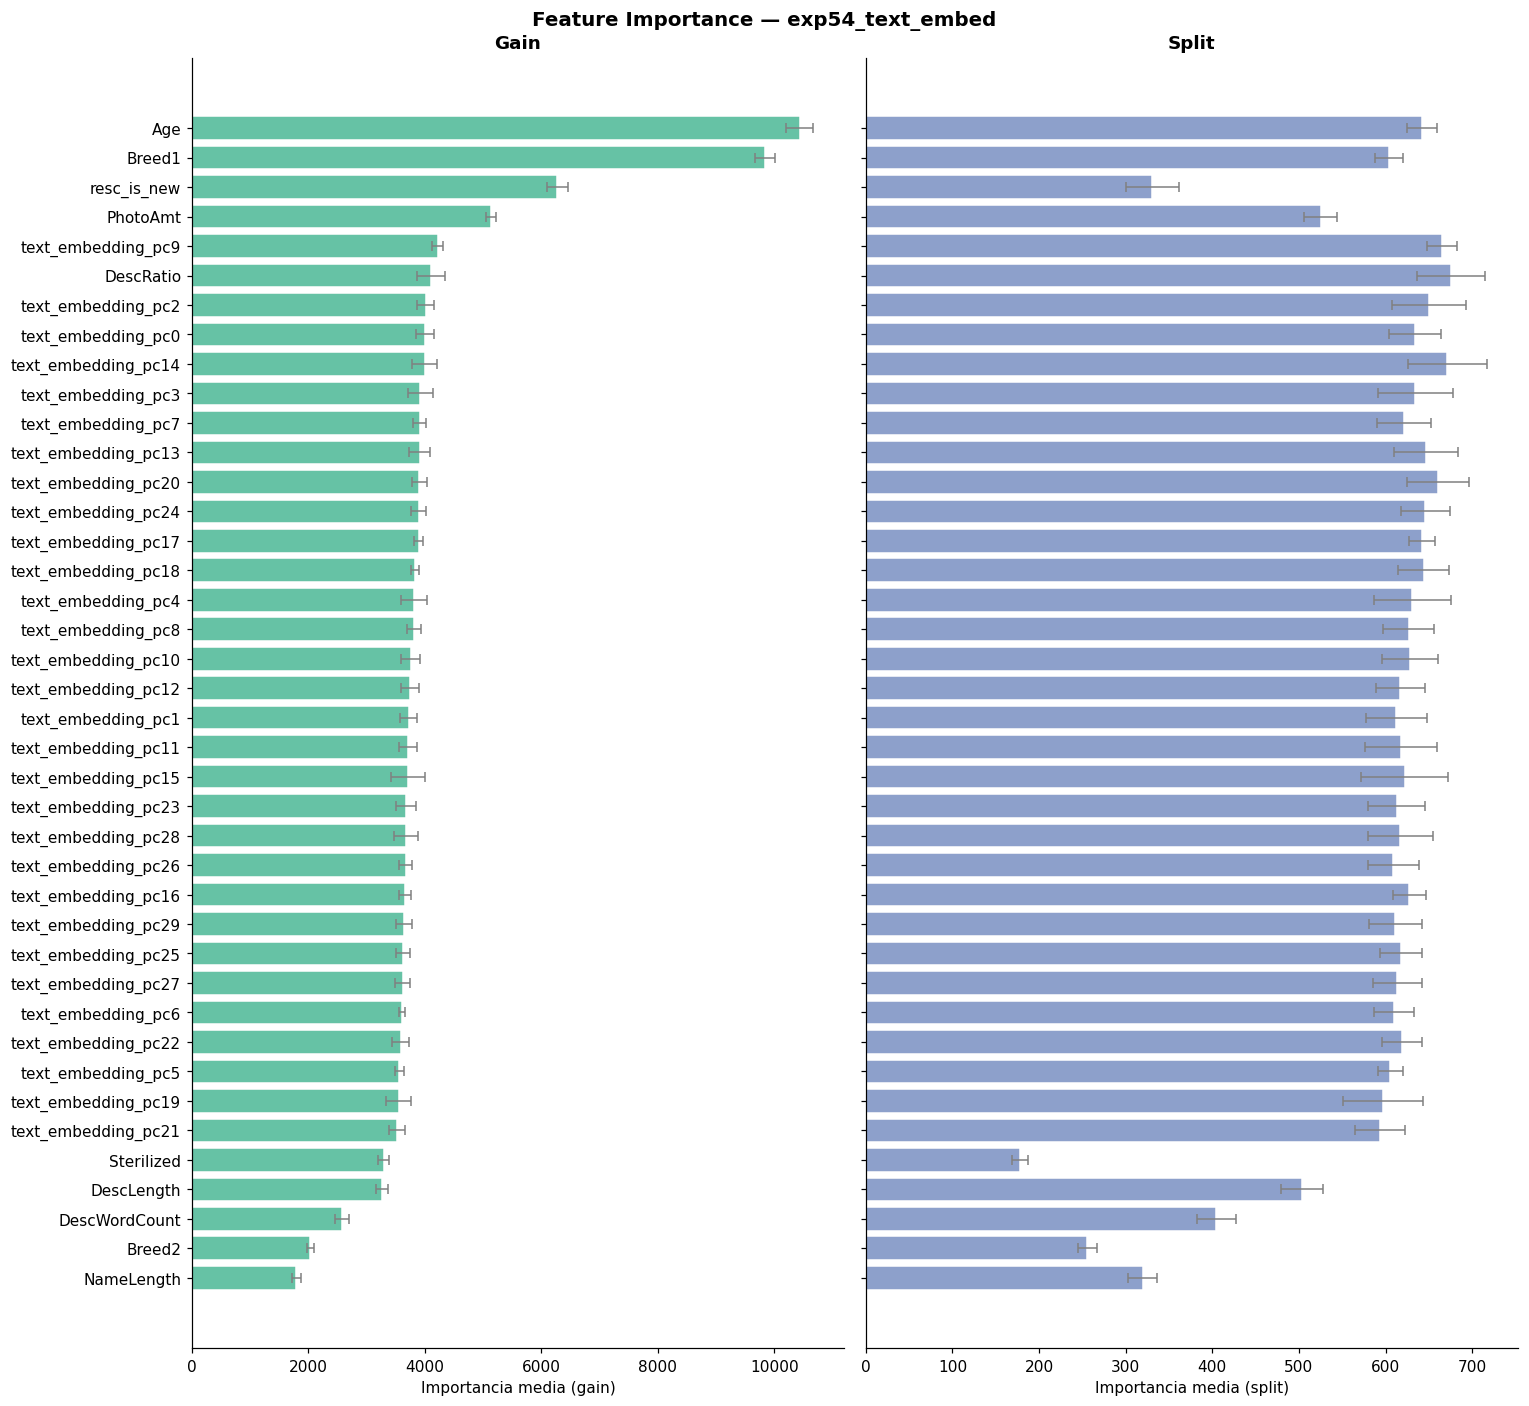

In [71]:
plot_results(y, [r['oof_preds'] for r in exp54_text_embed], title='exp54_text_embed')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp54_text_embed])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=40, title='Feature Importance — exp54_text_embed')


Los mejores resultados se obtienen al utilizar 30 componentes. 
Se incorporarán estas variables al modelo.

In [72]:
NEW_INT = [f'text_embedding_{i}' for i in range(text_embeddings_matrix.shape[1])] + ['vader_neg', 'emotion_sadness']
CURRENT_FEATURES_54b = CURRENT_FEATURES + NEW_INT
X_54b = df_fe[CURRENT_FEATURES_54b + AUX_COLS]

print(f'Features nuevas (5.4b): {NEW_INT}')
print(f'Total features: {len(CURRENT_FEATURES_54b)}')
print('\n' + '='*55)
print('EXPERIMENTO 5.4b: + Combinaciones')
print('='*55)

exp54b_combinations = []

for seed in SEEDS:
    r = run_cv(
        X=X_54b,
        y=y,
        params=BASELINE_PARAMS,
        seed = seed,
        cat_features=categoricals,
        #te_cols=TE_COLS,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,
        pca_config = PCA_CONFIG_TEXT,
        aux_cols=AUX_COLS, 
        experiment_name=f'exp54b_combinations{seed}',
        verbose=False,  
    )
    exp54b_combinations.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp54b_combinations, name='exp54b_combinations')
delta(exp54b_combinations, best_result)

Features nuevas (5.4b): ['text_embedding_0', 'text_embedding_1', 'text_embedding_2', 'text_embedding_3', 'text_embedding_4', 'text_embedding_5', 'text_embedding_6', 'text_embedding_7', 'text_embedding_8', 'text_embedding_9', 'text_embedding_10', 'text_embedding_11', 'text_embedding_12', 'text_embedding_13', 'text_embedding_14', 'text_embedding_15', 'text_embedding_16', 'text_embedding_17', 'text_embedding_18', 'text_embedding_19', 'text_embedding_20', 'text_embedding_21', 'text_embedding_22', 'text_embedding_23', 'text_embedding_24', 'text_embedding_25', 'text_embedding_26', 'text_embedding_27', 'text_embedding_28', 'text_embedding_29', 'text_embedding_30', 'text_embedding_31', 'text_embedding_32', 'text_embedding_33', 'text_embedding_34', 'text_embedding_35', 'text_embedding_36', 'text_embedding_37', 'text_embedding_38', 'text_embedding_39', 'text_embedding_40', 'text_embedding_41', 'text_embedding_42', 'text_embedding_43', 'text_embedding_44', 'text_embedding_45', 'text_embedding_46'

0.005875911351443053

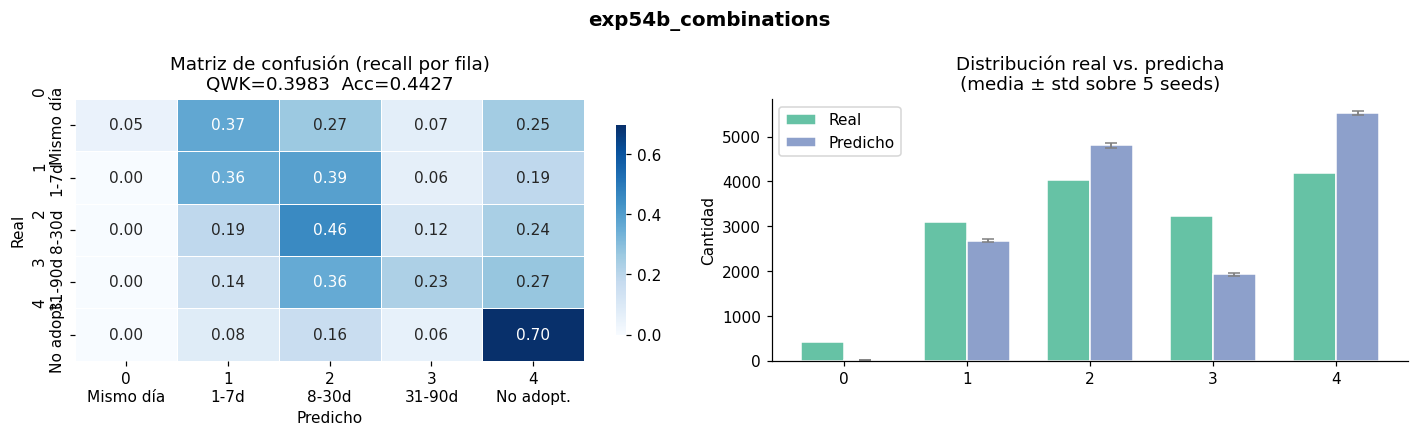

              precision    recall  f1-score   support

  0-MismoDía       0.68      0.05      0.09       410
  1-1ªSemana       0.39      0.36      0.37      3083
    2-1erMes       0.37      0.46      0.41      4029
 3-2do3erMes       0.44      0.23      0.30      3236
  4-NoAdopt.       0.54      0.70      0.61      4193

    accuracy                           0.44     14951
   macro avg       0.48      0.36      0.36     14951
weighted avg       0.45      0.44      0.42     14951



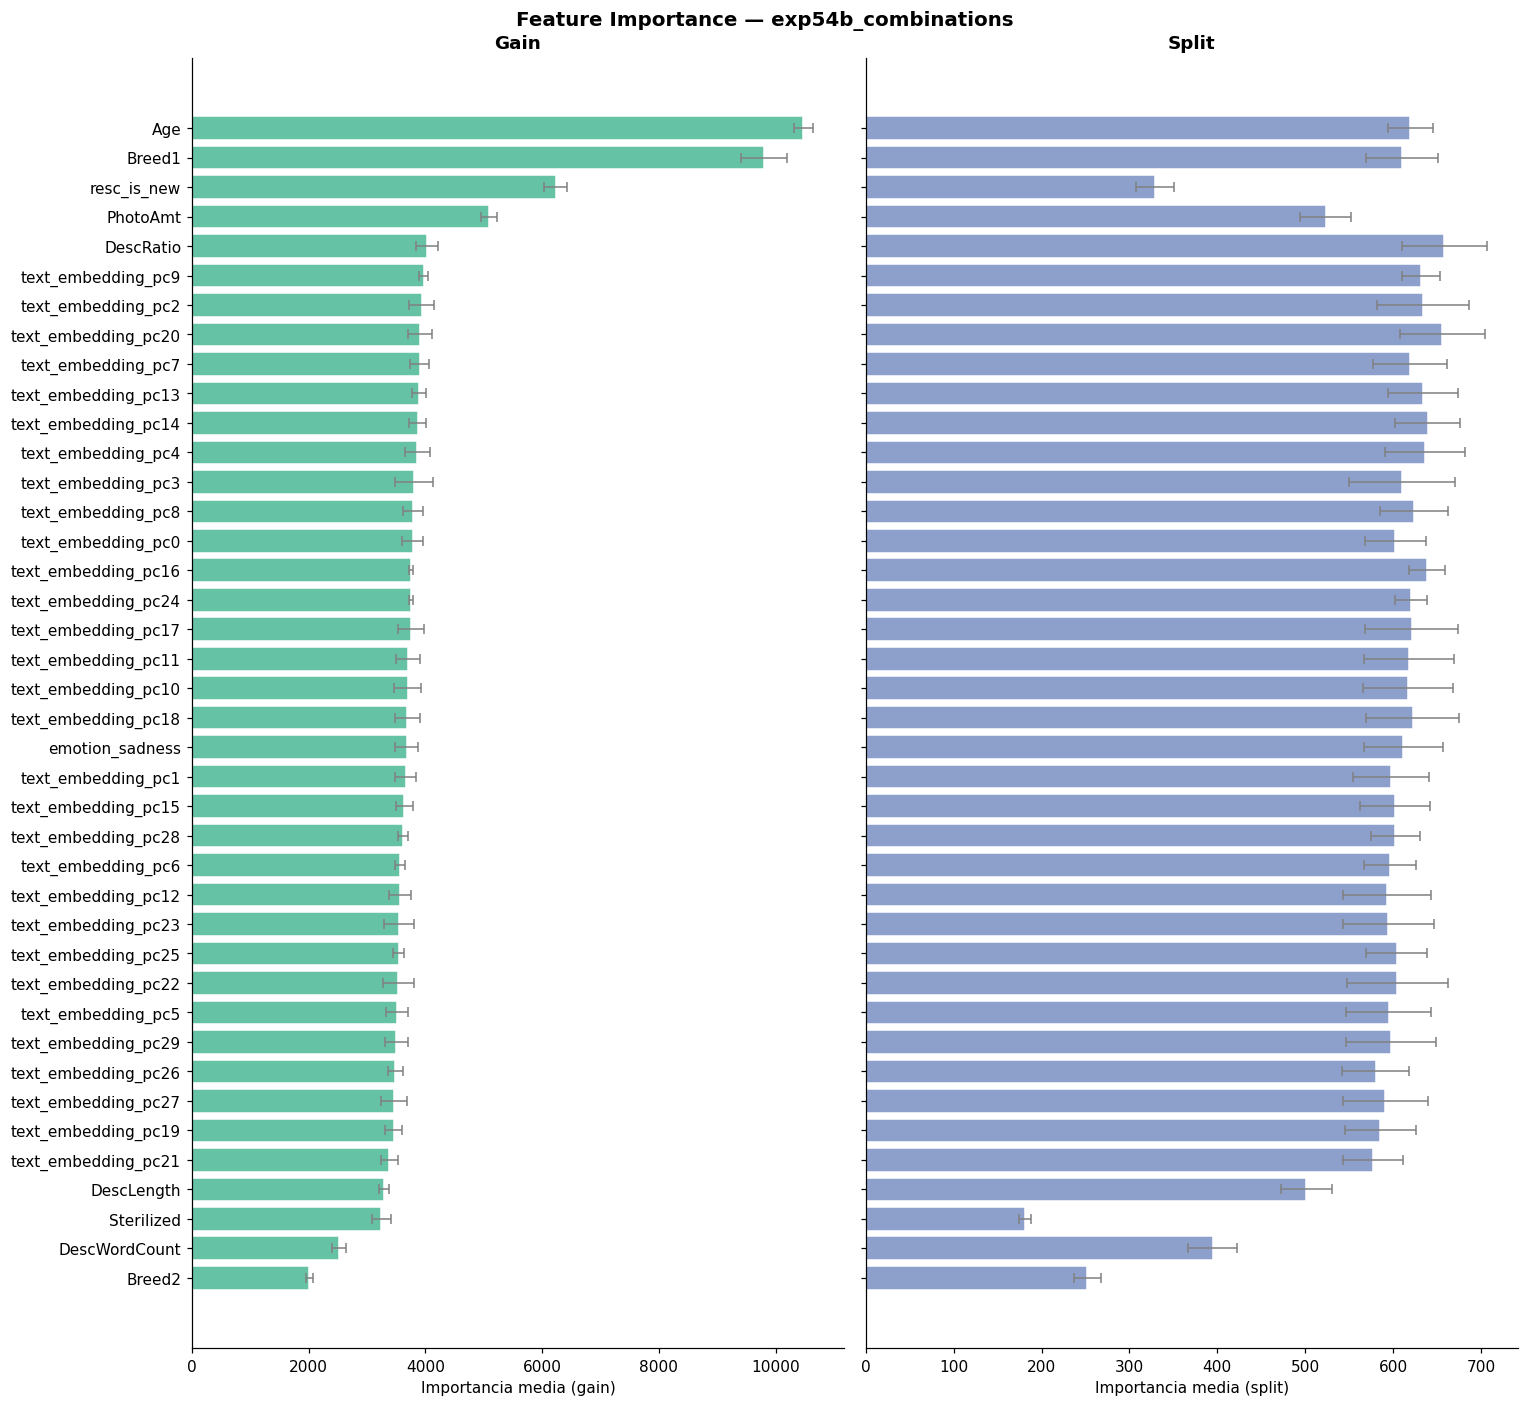

In [73]:
plot_results(y, [r['oof_preds'] for r in exp54b_combinations], title='exp54b_combinations')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp54b_combinations])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=40, title='Feature Importance — exp54b_combinations')


Las features se complementan bien entre sí: más señal, y más estable. La descripción parece ser un predictor clave: las variables del text_embedding ocupan la mayoría del top 25, DescRatio está en el 6to lugar y emotion_sadness en el 18. La feature a revisar será vader_neg.

In [74]:
CURRENT_FEATURES = CURRENT_FEATURES_54b
best_result = exp54b_combinations

---
# 6 Análisis de Imágenes

Se utilizará el modelo MobileNetV2 para extraer embeddings de las imágenes, se realizará un promedio de embeddings por PetID, luego se aplicará PCA para extraer las N features que permitan capturar variabilidad de las imágenes, por último se entrenará un nuevo experimento del modelo tabular para evaluar si mejora el QWK.
Por falta de GPU, el proceso se corrió por separado en Google Colab. Un proceso que en local hubiera tardado 22 horas en correr, en Colab con GPUx4 demoró 2 horas y media.

In [ ]:
# ── Celda 2: Configuración ──────────────────────────────────

#DRIVE_BASE_DIR = '/content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/11. Laboratorio de implementación II (jueves)/UA_MDM_Labo2_Grupo2'

TABULAR_DIR    = '../input/petfinder-adoption-prediction/train/train.csv'
IMAGE_DIR      = '../input/petfinder-adoption-prediction/train_images'
CHECKPOINT_DIR = 'checkpoints_petfinder'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
IMG_SIZE    = (160, 160)
BATCH_SIZE  = 64   
NUM_WORKERS = 2    
CHECKPOINT_EVERY = 50

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Dispositivo: cpu


In [76]:
# ── Celda 3: Modelo ─────────────────────────────────────────
print("Cargando MobileNetV2...")
mobilenet = models.mobilenet_v2(weights='IMAGENET1K_V1')
mobilenet.classifier = torch.nn.Identity()
mobilenet.eval().to(DEVICE)
print("✓ Modelo cargado y enviado a", DEVICE)
 
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Cargando MobileNetV2...
✓ Modelo cargado y enviado a cpu


In [77]:
# ── Celda 4: Dataset ────────────────────────────────────────
class PetImageDataset(Dataset):
    def __init__(self, image_dir, pet_ids, transform):
        self.transform = transform
        self.samples   = []  # (pet_id, path)
 
        for pid in pet_ids:
            img_idx = 1
            while True:
                path = os.path.join(image_dir, f"{pid}-{img_idx}.jpg")
                if not os.path.exists(path):
                    break
                self.samples.append((pid, path))
                img_idx += 1
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        pet_id, path = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            return pet_id, self.transform(img), True
        except Exception:
            return pet_id, torch.zeros(3, *IMG_SIZE), False

In [78]:
# ── Celda 5: Helpers de checkpoint ──────────────────────────
CHECKPOINT_PKL = os.path.join(CHECKPOINT_DIR, 'img_embeddings_train.pkl')
 
def cargar_checkpoint():
    if not os.path.exists(CHECKPOINT_PKL):
        print("No se encontró checkpoint previo. Empezando desde cero.")
        return {}
    try:
        with open(CHECKPOINT_PKL, 'rb') as f:
            data = pickle.load(f)
        print(f"⚡ Checkpoint cargado: {len(data)} PetIDs ya procesados.")
        return data
    except (EOFError, pickle.UnpicklingError):
        print("⚠️  Checkpoint corrupto. Empezando desde cero.")
        return {}
 
def guardar_checkpoint(embeddings_por_pet):
    """Escritura atómica: tmp → rename, para no corromper si se corta."""
    tmp = CHECKPOINT_PKL + '.tmp'
    with open(tmp, 'wb') as f:
        pickle.dump(embeddings_por_pet, f, protocol=4)
    os.replace(tmp, CHECKPOINT_PKL)
    print(f"  💾 Checkpoint guardado ({len(embeddings_por_pet)} PetIDs)")
 
 

In [79]:
# ── Celda 6: Extracción principal ───────────────────────────
def extraer_embeddings(pet_ids):
    embeddings_por_pet = cargar_checkpoint()
 
    pendientes = [pid for pid in pet_ids if pid not in embeddings_por_pet]
    print(f"📋 Pendientes: {len(pendientes)} / {len(pet_ids)} PetIDs")
 
    if not pendientes:
        print("✓ Nada que procesar.")
        return embeddings_por_pet
 
    dataset = PetImageDataset(IMAGE_DIR, pendientes, transform)
    loader  = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == 'cuda'),
    )
    print(f"   Imágenes a procesar: {len(dataset)}")
 
    # Acumula embeddings por pet durante el recorrido
    acum = {}   # pet_id -> [embedding, ...]
 
    t0 = time.time()
    with torch.no_grad():
        for batch_idx, (pet_ids_batch, imgs, validos) in enumerate(
            tqdm(loader, desc="Embeddings", unit="batch")
        ):
            imgs_validas = imgs[validos].to(DEVICE)
            pids_validos = [pid for pid, v in zip(pet_ids_batch, validos) if v]
 
            if len(imgs_validas) == 0:
                continue
 
            embs = mobilenet(imgs_validas).cpu().numpy()  # (B, 1280)
 
            for pid, emb in zip(pids_validos, embs):
                acum.setdefault(pid, []).append(emb)
 
            # ── Checkpoint parcial ───────────────────────────────────
            # Cada CHECKPOINT_EVERY batches, consolida lo acumulado y guarda.
            # Si Colab se corta acá, solo se pierde el batch en curso.
            if (batch_idx + 1) % CHECKPOINT_EVERY == 0:
                _consolidar_y_guardar(acum, embeddings_por_pet)
                acum.clear()
                elapsed = time.time() - t0
                print(f"  ⏱  {elapsed/60:.1f} min transcurridos | "
                      f"{len(embeddings_por_pet)} PetIDs guardados")
 
    # Consolidar lo que quedó al final
    _consolidar_y_guardar(acum, embeddings_por_pet)
 
    # Pets sin ninguna imagen válida
    for pid in pendientes:
        if pid not in embeddings_por_pet:
            embeddings_por_pet[pid] = {'embedding': None, 'n_imagenes': 0}
 
    guardar_checkpoint(embeddings_por_pet)
    print(f"\n✓ Procesamiento completo. Total: {len(embeddings_por_pet)} PetIDs")
    return embeddings_por_pet
 
 
def _consolidar_y_guardar(acum, embeddings_por_pet):
    """Promedia los embeddings acumulados y los vuelca al dict principal."""
    for pid, emb_list in acum.items():
        arr = np.stack(emb_list)
        embeddings_por_pet[pid] = {
            'embedding':   arr.mean(axis=0),
            'n_imagenes':  len(arr),
        }
    if acum:
        guardar_checkpoint(embeddings_por_pet)
 

In [80]:
# ── Celda 7: Ejecutar ─────────────────────────────────────── 
pet_ids       = df_fe['PetID'].tolist()
img_embeddings = extraer_embeddings(pet_ids)
 
df_fe['img_n_imagenes'] = df_fe['PetID'].map(
    lambda pid: img_embeddings[pid]['n_imagenes'] if img_embeddings.get(pid) else 0
)


⚡ Checkpoint cargado: 14993 PetIDs ya procesados.
📋 Pendientes: 0 / 14951 PetIDs
✓ Nada que procesar.


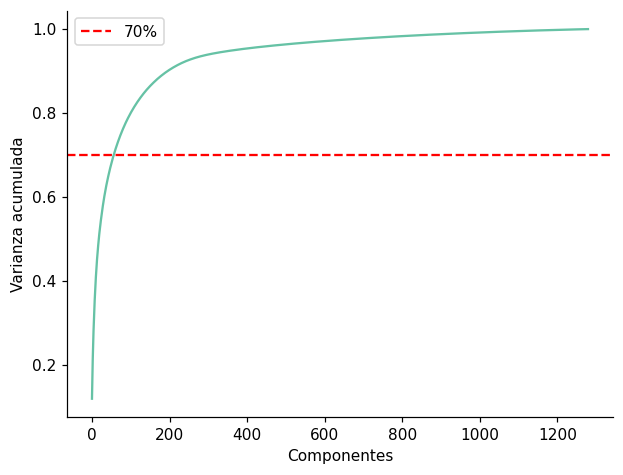

Varianza explicada con 20 features: 51.29%
Varianza explicada con 30 features: 58.46%
Varianza explicada con 40 features: 63.62%


In [81]:
img_ids = [k for k, v in img_embeddings.items() if v['embedding'] is not None]
img_vectors = np.array([v['embedding'] for v in img_embeddings.values() if v['embedding'] is not None])

pca = PCA(random_state=SEED)
pca_full = pca.fit_transform(img_vectors)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Componentes")
plt.ylabel("Varianza acumulada")
plt.axhline(0.70, color='r', linestyle='--', label='70%')
plt.legend()
plt.show()

for n in [20, 30, 40]:
    varianza = pca.explained_variance_ratio_[:n].sum()
    print(f"Varianza explicada con {n} features: {varianza:.2%}")

In [82]:
# Construir df con embeddings crudos (sin PCA)
img_embedding_cols = [f'img_embedding_{i}' for i in range(img_vectors.shape[1])]

img_embeddings_df = pd.DataFrame(
    img_vectors,
    index=img_ids,
    columns=img_embedding_cols
)

# Join crudo a df_fe
df_fe = df_fe.join(img_embeddings_df, on='PetID', how='left').fillna(0)

In [83]:
NEW_INT_61 = img_embedding_cols
CURRENT_FEATURES_61 = CURRENT_FEATURES + NEW_INT_61
X_61 = df_fe[CURRENT_FEATURES_61 + AUX_COLS]
PCA_CONFIG_IMG = {'text_embedding': 30, 'img_embedding': 15}

print(f'Features nuevas (img): {NEW_INT_61}')
print(f'Total features: {len(CURRENT_FEATURES_61)}')
print('\n' + '='*55)
print('EXPERIMENTO 6.1: + Image Embeddings (PCA)')
print('='*55)

exp61_img_embed = []
    
        
for seed in SEEDS:
    r = run_cv(
        X=X_61,
        y=y,
        params=BASELINE_PARAMS,
        seed=seed,
        cat_features=categoricals,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,
        aux_cols=AUX_COLS,
        pca_config = PCA_CONFIG_IMG,
        experiment_name=f'exp61_img_embed{seed}',
        verbose=False,
    )
    exp61_img_embed.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp61_img_embed, name='exp61_img_embed')
delta(exp61_img_embed, best_result)

Features nuevas (img): ['img_embedding_0', 'img_embedding_1', 'img_embedding_2', 'img_embedding_3', 'img_embedding_4', 'img_embedding_5', 'img_embedding_6', 'img_embedding_7', 'img_embedding_8', 'img_embedding_9', 'img_embedding_10', 'img_embedding_11', 'img_embedding_12', 'img_embedding_13', 'img_embedding_14', 'img_embedding_15', 'img_embedding_16', 'img_embedding_17', 'img_embedding_18', 'img_embedding_19', 'img_embedding_20', 'img_embedding_21', 'img_embedding_22', 'img_embedding_23', 'img_embedding_24', 'img_embedding_25', 'img_embedding_26', 'img_embedding_27', 'img_embedding_28', 'img_embedding_29', 'img_embedding_30', 'img_embedding_31', 'img_embedding_32', 'img_embedding_33', 'img_embedding_34', 'img_embedding_35', 'img_embedding_36', 'img_embedding_37', 'img_embedding_38', 'img_embedding_39', 'img_embedding_40', 'img_embedding_41', 'img_embedding_42', 'img_embedding_43', 'img_embedding_44', 'img_embedding_45', 'img_embedding_46', 'img_embedding_47', 'img_embedding_48', 'img_e

0.009611710787086447

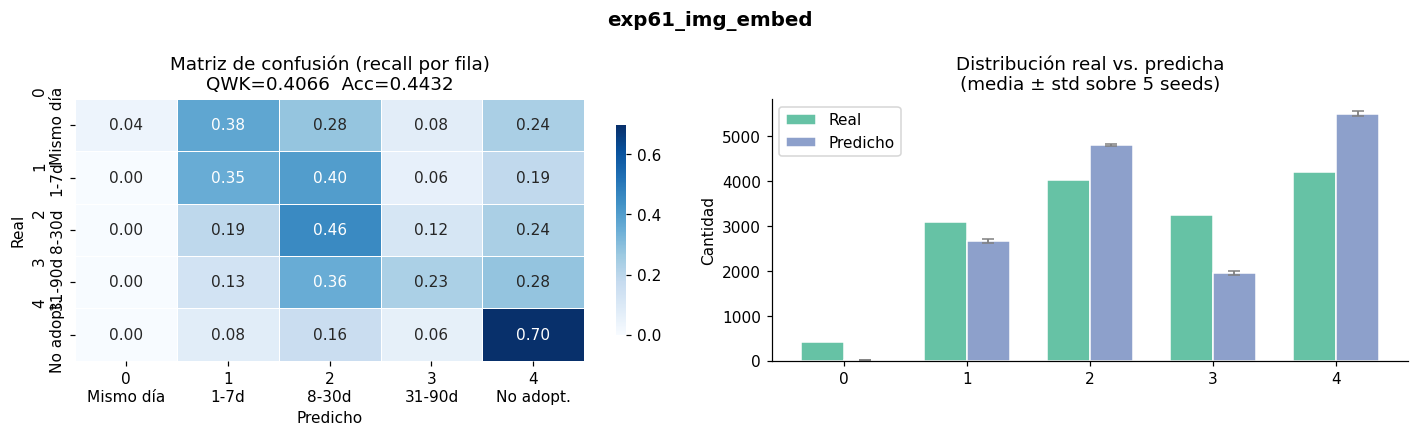

              precision    recall  f1-score   support

  0-MismoDía       0.83      0.04      0.07       410
  1-1ªSemana       0.39      0.35      0.37      3083
    2-1erMes       0.37      0.46      0.41      4029
 3-2do3erMes       0.45      0.23      0.31      3236
  4-NoAdopt.       0.54      0.70      0.61      4193

    accuracy                           0.44     14951
   macro avg       0.52      0.36      0.35     14951
weighted avg       0.45      0.44      0.42     14951



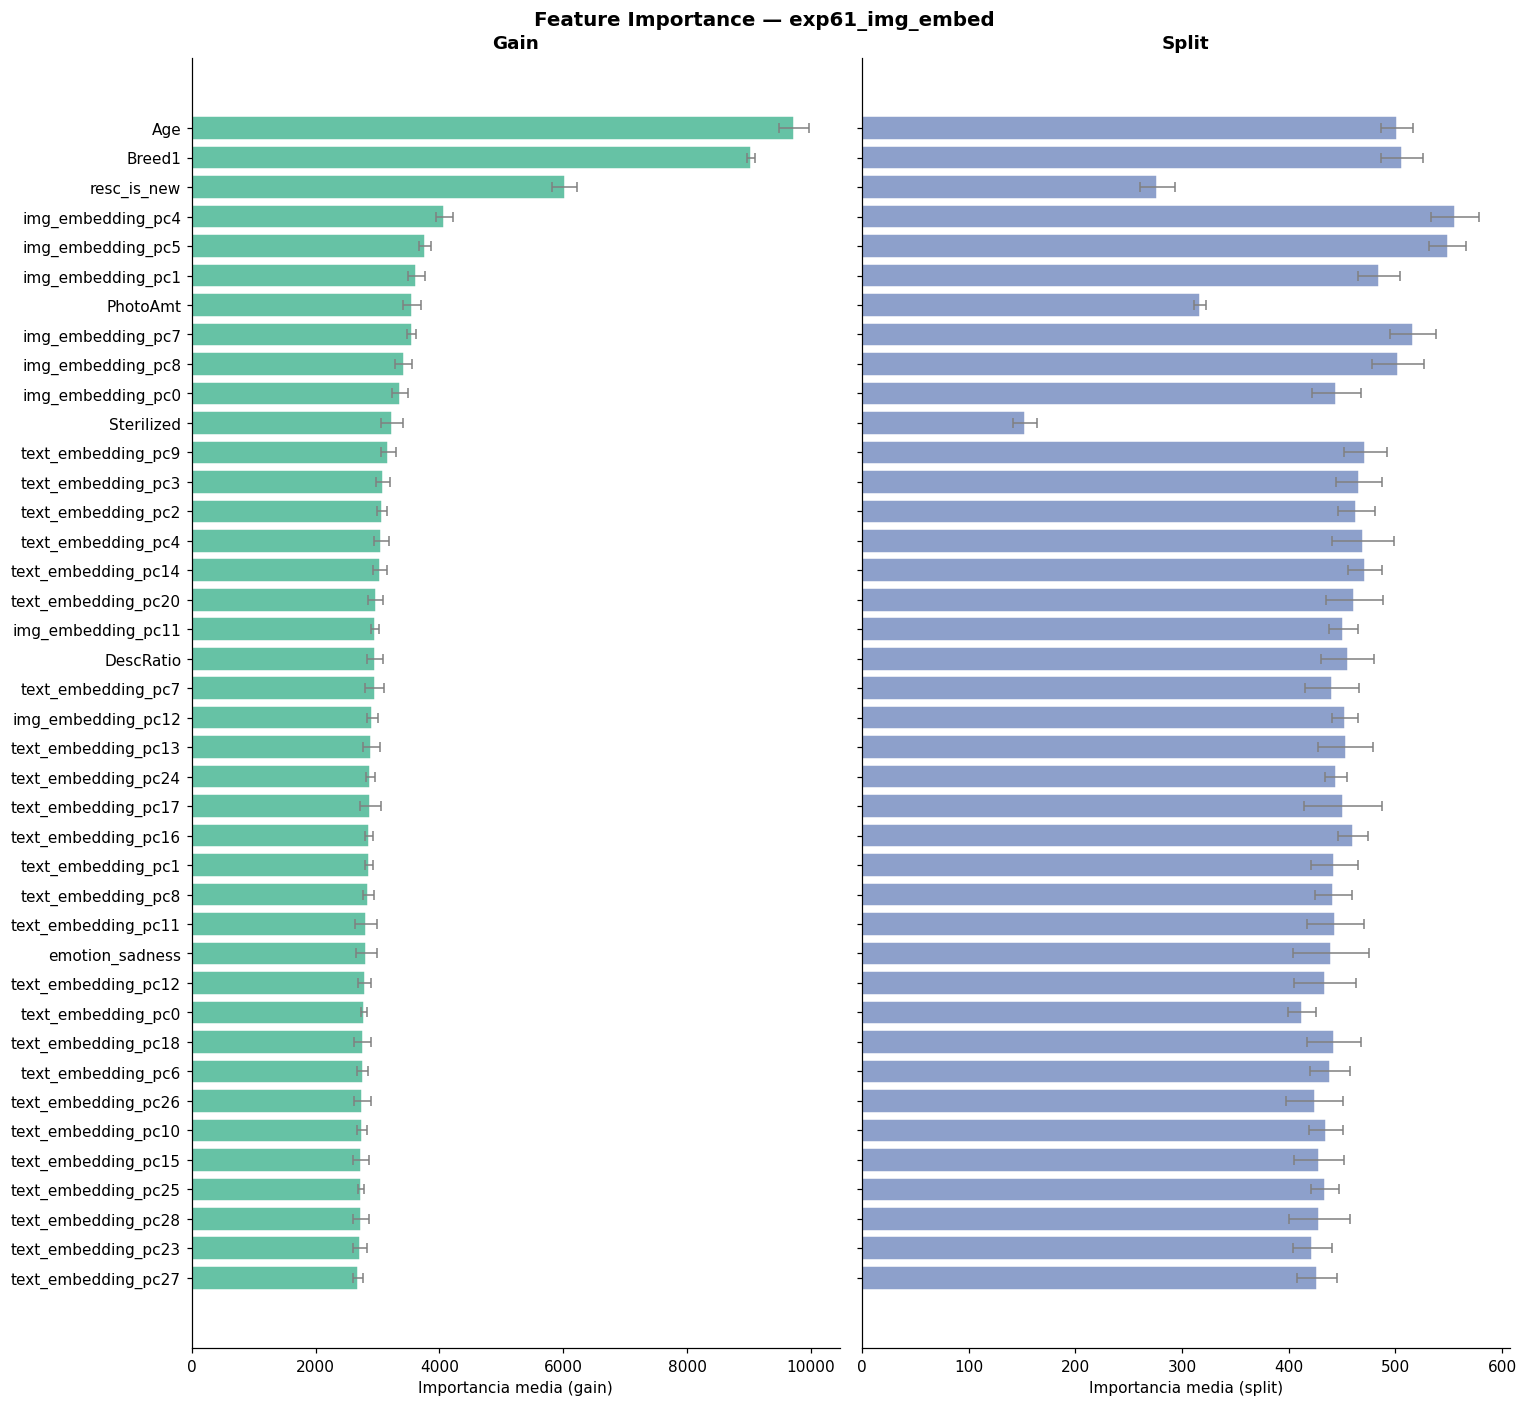

In [84]:
plot_results(y, [r['oof_preds'] for r in exp61_img_embed], title='exp61_img_embed')

all_feat_imp = pd.concat([r['feat_imp'] for r in exp61_img_embed])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=40, title='Feature Importance — exp61_img_embed')


El uso de los embeddings de imágenes también captura información importante, mejorando el QWK del modelo.

In [85]:
CURRENT_FEATURES = CURRENT_FEATURES_61
best_result = exp61_img_embed

# 7.a Limpieza final
Se identificaron variables con poca contribución de ganancia en el modelo, y poco utilizadas para splits. Se eliminarán del modelo para evaluar si tienen algún aporte real o no.

In [86]:
feat_imp_combined.tail(10)

,feature,gain,gain_std,split,split_std
22,StateMarriageRate,414.583620,34.063686,56.48,3.570994
11,FurLength,405.248149,34.855963,59.12,5.206918
3,Color1,375.501347,25.404990,60.60,4.696807
4,Color2,278.134171,15.253305,44.60,2.935984
25,Type,128.859818,35.672931,11.40,2.024846
15,Health,87.560132,10.578089,15.36,1.663731
27,VideoAmt,82.706044,9.998415,17.32,1.453272
5,Color3,76.348496,11.145137,15.44,3.173011
14,HasName,67.528832,19.398630,10.12,2.071714
13,HasDesc,0.000000,0.000000,0.00,0.000000


In [87]:
NEW_VAR = ['Color3',
          'VideoAmt',
          'HasName',
          'HasDesc',
          #'Type',
          #'Health'
         ]

features_sin_originales = [f for f in CURRENT_FEATURES
                            if f not in NEW_VAR]

categoricals_sin_originales = [f for f in categoricals 
                            if f not in NEW_VAR]

CURRENT_FEATURES_47a = features_sin_originales
X_47a = df_fe[CURRENT_FEATURES_47a + AUX_COLS]

print(f'Features a quitar (4.7a): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_47a)}')
print('\n' + '='*55)
print('EXPERIMENTO 4.7a: + Ajuste de Features')
print('='*55)

exp47a_ajuste = []

for seed in SEEDS:
    r = run_cv(
        X=X_47a,
        y=y,
        params=BASELINE_PARAMS,
        seed=seed,
        cat_features=categoricals_sin_originales,
        #te_cols=TE_COLS,
        agg_config=AGG_RESCUER,
        agg_smoothing=AGG_SMOOTHING,
        aux_cols=AUX_COLS + ['RescuerID'],
        pca_config = PCA_CONFIG_IMG,
        experiment_name=f'exp47a_ajuste{seed}',
        verbose=False,  
    )
    exp47a_ajuste.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(exp47a_ajuste, name='exp47a_ajuste')

# Resumen final
all_qwks = [r['qwk_mean'] for r in exp47a_ajuste]
print(f"\n── Resumen sobre {len(SEEDS)} semillas ──")
print(f"QWK medio:  {np.mean(all_qwks):.4f}")
print(f"QWK std:    {np.std(all_qwks):.4f}")
print(f"QWK rango:  [{min(all_qwks):.4f}, {max(all_qwks):.4f}]")
delta(exp47a_ajuste, best_result)

Features a quitar (4.7a): ['Color3', 'VideoAmt', 'HasName', 'HasDesc']
Total features: 1691

EXPERIMENTO 4.7a: + Ajuste de Features
Seed 310019: QWK = 0.3908 ± 0.0193
Seed 320009: QWK = 0.3923 ± 0.0062
Seed 330017: QWK = 0.3936 ± 0.0156
Seed 340007: QWK = 0.3893 ± 0.0116
Seed 350029: QWK = 0.3916 ± 0.0184

── Resumen sobre 5 semillas ──
QWK medio:  0.3915
QWK std:    0.0014
QWK rango:  [0.3893, 0.3936]
  Referencia : QWK = 0.3890 ± 0.0135  (n=25 folds)
  Nuevo      : QWK = 0.3915 ± 0.0151  (n=25 folds)
  ΔQWK       : +0.0025


0.0025307893986546426

Al eliminar este grupo de variables el modelo mejora su QWK aunque crece la varianza. 

In [88]:
CURRENT_FEATURES = features_sin_originales
categoricals = categoricals_sin_originales
best_result = exp47a_ajuste

---
# 7. Tuning de hiperparámetros con Optuna

Búsqueda bayesiana sobre el espacio de hiperparámetros de LightGBM.
Se usa 3-fold durante la búsqueda (velocidad) y se valida el mejor trial con 5-fold.
Los resultados se guardan en la carpeta 'cache' y pueden ser consultados o utilizados al definir el nombre con el objeto 'BO_VERSION'.

In [89]:
# X_final usa el mejor conjunto de features encontrado en FE
FINAL_FEATURES = CURRENT_FEATURES
FINAL_CAT_FEATURES = categoricals
FINAL_AGG_CONFIG = AGG_RESCUER
FINAL_AGG_SMOOTHING = AGG_SMOOTHING
FINAL_AUX_COLS = AUX_COLS
FINAL_TE_COLS = TE_COLS
FINAL_PCA_CONFIG = PCA_CONFIG_IMG
#FINAL_TE_SMOOTHING = 'auto'
X_final = df_fe[FINAL_FEATURES + FINAL_AUX_COLS].copy()

def objective(trial):
    params = {
        'objective'   : 'multiclass',
        'num_class'   : 5,
        'verbose'     : -1,
        'n_estimators': 4000,
        'learning_rate'          : trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'num_leaves'             : trial.suggest_int('num_leaves', 31, 150),
        'max_depth'              : trial.suggest_int('max_depth', 4, 9),
        'min_child_samples'      : trial.suggest_int('min_child_samples', 20, 150),
        'subsample'              : trial.suggest_float('subsample', 0.3, 1.0),
        'bagging_freq'           : trial.suggest_int('bagging_freq', 1, 7),
        'colsample_bytree'       : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_sum_hessian_in_leaf': trial.suggest_float('min_sum_hessian_in_leaf', 1e-3, 10.0, log=True),
    }

    # ── Hiperparámetros de PCA ────────────────────────────────────────────────
    pca_config = {
        'text_embedding': trial.suggest_int('pca_text_n', 5, 100),
        'img_embedding' : trial.suggest_int('pca_img_n',  5, 100),
    }

    results = run_cv(
        X=X_final,      
        y=y,
        params=params,
        cat_features=FINAL_CAT_FEATURES,
        n_folds=3,
        verbose=False,
        experiment_name=f'trial_{trial.number}',
        agg_config=FINAL_AGG_CONFIG,
        agg_smoothing=FINAL_AGG_SMOOTHING,
        aux_cols=FINAL_AUX_COLS,
        eval_metric_fn=lgb_qwk_eval,
        pca_config=pca_config,  
    )

    for fold, qwk_fold in enumerate(results['fold_qwk']):
        trial.report(qwk_fold, fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return results['qwk_mean']


print('Función objetivo definida.')

Función objetivo definida.


In [ ]:

os.makedirs('cache', exist_ok=True)
BO_VERSION = 'study_v10_pca'  
BO_CACHE_PATH = f'cache/{BO_VERSION}.pkl'

if os.path.exists(BO_CACHE_PATH):
    study = joblib.load(BO_CACHE_PATH)
    print(f'Study cargado desde caché: {BO_CACHE_PATH}')
    print(f'Trials completados: {len(study.trials)}')

else:
    N_TRIALS = 120
    study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)

    print(f'Iniciando búsqueda: {N_TRIALS} trials...')
    t0 = time.time()
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    print(f'\nTiempo total: {(time.time()-t0)/60:.1f} min')

    joblib.dump(study, BO_CACHE_PATH)
    print(f'Study guardado en: {BO_CACHE_PATH}')

print(f'\nMejor QWK (3-fold): {study.best_value:.4f}')
print('Mejores hiperparámetros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Study cargado desde caché: ../cache/study_v10_pca.pkl
Trials completados: 120

Mejor QWK (3-fold): 0.4045
Mejores hiperparámetros:
  learning_rate: 0.001749281778577592
  num_leaves: 85
  max_depth: 9
  min_child_samples: 24
  subsample: 0.804072026212061
  bagging_freq: 4
  colsample_bytree: 0.5532422864898395
  min_sum_hessian_in_leaf: 0.009185188601702197
  pca_text_n: 75
  pca_img_n: 34


In [91]:
#study = joblib.load('../cache/study_v9_pca.pkl')

df_trials = study.trials_dataframe()
print(df_trials.columns)
print(df_trials[['number','value','params_bagging_freq', 'params_colsample_bytree',
       'params_learning_rate', 'params_max_depth', 'params_min_child_samples',
       'params_min_sum_hessian_in_leaf', 'params_num_leaves',
       'params_subsample', 'params_pca_img_n', 'params_pca_text_n']].sort_values('value', ascending=False).head(10))

Index(['number', 'value', 'datetime_start', 'datetime_complete', 'duration',
       'params_bagging_freq', 'params_colsample_bytree',
       'params_learning_rate', 'params_max_depth', 'params_min_child_samples',
       'params_min_sum_hessian_in_leaf', 'params_num_leaves',
       'params_pca_img_n', 'params_pca_text_n', 'params_subsample', 'state'],
      dtype='object')
     number     value  params_bagging_freq  params_colsample_bytree  \
118     118  0.404534                    4                 0.553242   
42       42  0.403775                    1                 0.521498   
119     119  0.403694                    4                 0.512979   
113     113  0.403485                    5                 0.536947   
94       94  0.403208                    3                 0.538917   
86       86  0.402988                    4                 0.560907   
114     114  0.402955                    5                 0.541275   
93       93  0.402938                    3               

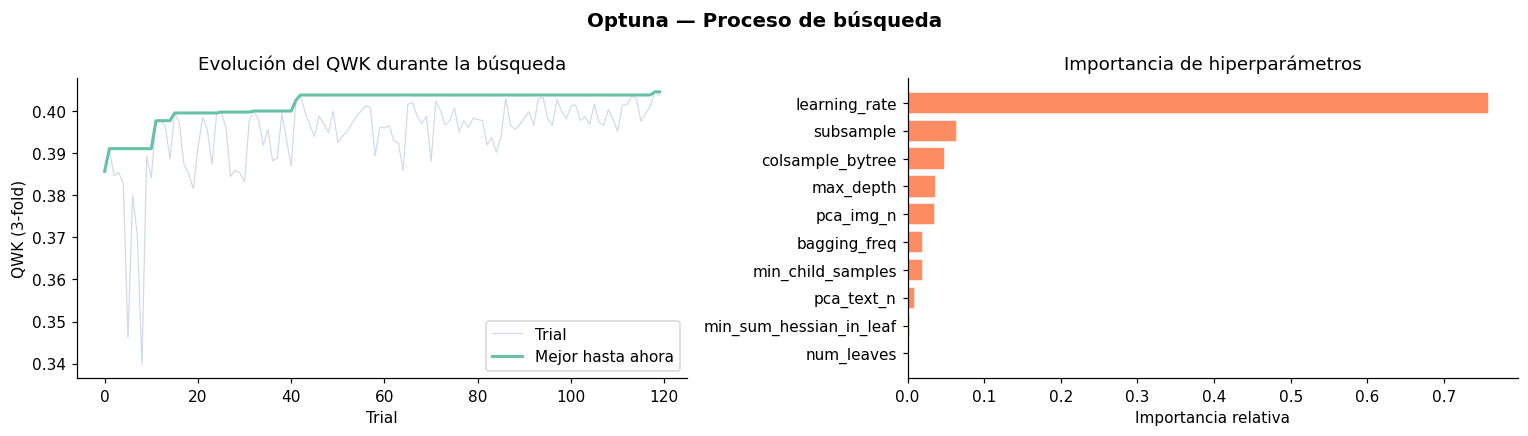

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study.trials_dataframe()
completed = trials_df[trials_df['state'] == 'COMPLETE'].copy()
completed['best_so_far'] = completed['value'].cummax()

axes[0].plot(completed.index, completed['value'],
             alpha=0.4, color=PALETTE[2], linewidth=0.8, label='Trial')
axes[0].plot(completed.index, completed['best_so_far'],
             color=PALETTE[0], linewidth=2, label='Mejor hasta ahora')
axes[0].set_title('Evolución del QWK durante la búsqueda')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('QWK (3-fold)')
axes[0].legend()

try:
    imp = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame(list(imp.items()), columns=['Param','Importance']).sort_values('Importance')
    axes[1].barh(imp_df['Param'], imp_df['Importance'], color=PALETTE[1], edgecolor='white')
    axes[1].set_title('Importancia de hiperparámetros')
    axes[1].set_xlabel('Importancia relativa')
except Exception as e:
    axes[1].text(0.5, 0.5, f'No disponible:\n{e}', ha='center', va='center')
    axes[1].axis('off')

plt.suptitle('Optuna — Proceso de búsqueda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [93]:
# Validación final del mejor trial con 5-fold
BEST_PARAMS = {
    'objective'   : 'multiclass',
    'num_class'   : 5,
    'metric'      : 'multi_logloss',
    'verbose'     : -1,
    'n_estimators': 3000,  
    **study.best_params
}

BEST_PCA_CONFIG = {
    'text_embedding': study.best_params['pca_text_n'],
    'img_embedding' : study.best_params['pca_img_n'],
}

print('='*55)
print('EXPERIMENTO FINAL: Mejor FE + Hiperparámetros tuneados (5-fold)')
print('='*55)

result_tuned = []
for seed in SEEDS:
    r = run_cv(
        X = X_final,   
        y = y,
        params = BEST_PARAMS,
        cat_features = FINAL_CAT_FEATURES,   
        n_folds = 5,    
        seed=seed,
        #te_cols=FINAL_TE_COLS,   
        #te_smoothing=FINAL_TE_SMOOTHING,
        agg_config=FINAL_AGG_CONFIG,
        agg_smoothing=FINAL_AGG_SMOOTHING,
        pca_config=BEST_PCA_CONFIG or None,
        aux_cols=FINAL_AUX_COLS,
        experiment_name=f'exp7_tuned{seed}',
        verbose=False,
    )
    result_tuned.append(r)
    print(f"Seed {seed}: QWK = {r['qwk_mean']:.4f} ± {r['qwk_std']:.4f}")

tracker.log(result_tuned, name='result_tuned')
delta(result_tuned, best_result)

EXPERIMENTO FINAL: Mejor FE + Hiperparámetros tuneados (5-fold)
Seed 310019: QWK = 0.3969 ± 0.0134
Seed 320009: QWK = 0.4074 ± 0.0132
Seed 330017: QWK = 0.4059 ± 0.0166
Seed 340007: QWK = 0.4007 ± 0.0119
Seed 350029: QWK = 0.3999 ± 0.0159
  Referencia : QWK = 0.3915 ± 0.0151  (n=25 folds)
  Nuevo      : QWK = 0.4022 ± 0.0148  (n=25 folds)
  ΔQWK       : +0.0106


0.010626876996757184

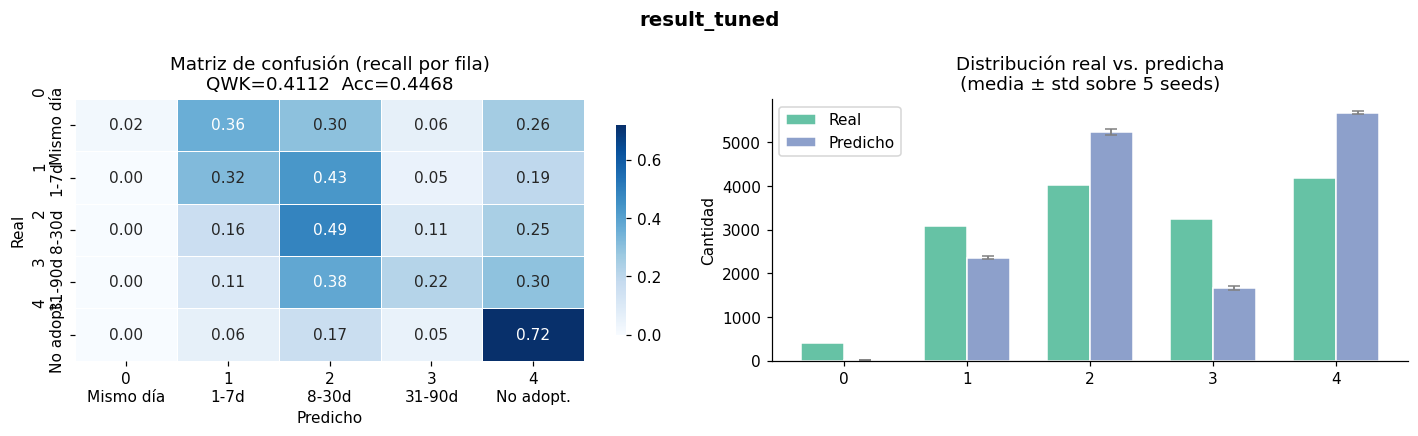

              precision    recall  f1-score   support

  0-MismoDía       0.73      0.02      0.04       410
  1-1ªSemana       0.41      0.32      0.36      3083
    2-1erMes       0.37      0.49      0.42      4029
 3-2do3erMes       0.46      0.22      0.30      3236
  4-NoAdopt.       0.53      0.72      0.61      4193

    accuracy                           0.45     14951
   macro avg       0.50      0.35      0.35     14951
weighted avg       0.45      0.45      0.42     14951



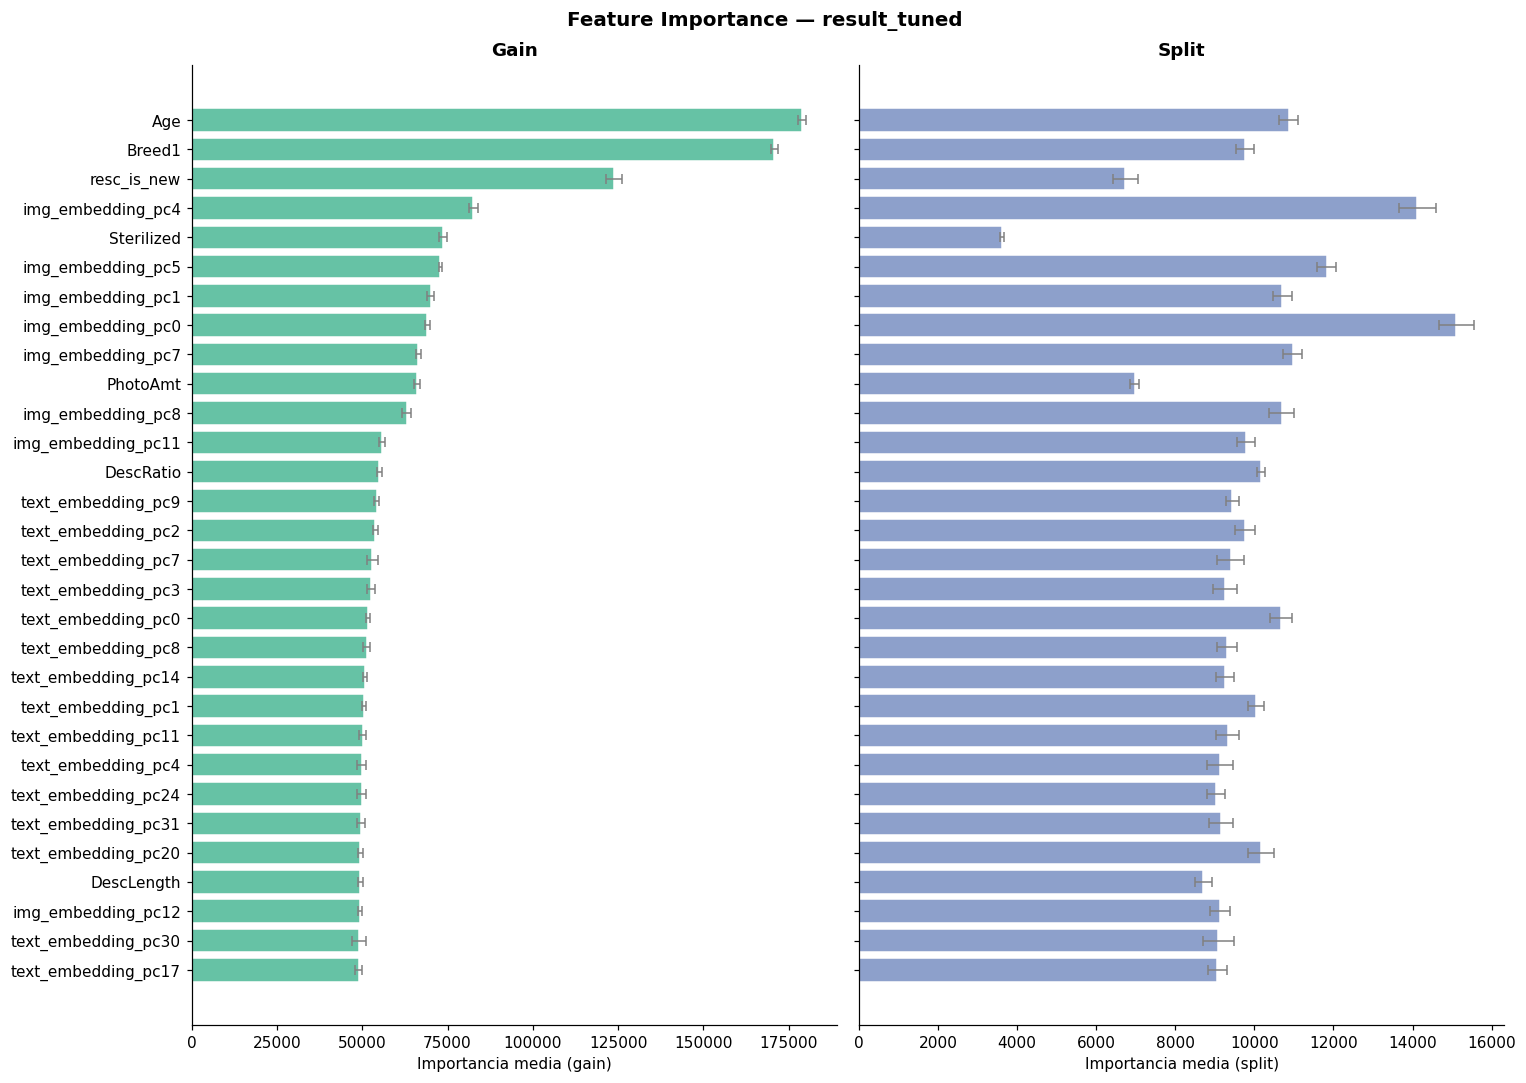

In [94]:
plot_results(y, [r['oof_preds'] for r in result_tuned], title='result_tuned')

all_feat_imp = pd.concat([r['feat_imp'] for r in result_tuned])

feat_imp_combined = (
    all_feat_imp
    .groupby('feature')
    .agg(
        gain      =('gain',      'mean'),
        gain_std  =('gain',      'std'),   # std entre seeds (no entre folds)
        split     =('split',     'mean'),
        split_std =('split',     'std'),
    )
    .reset_index()
    .sort_values('gain', ascending=False)
)

plot_importance(feat_imp_combined, top_n=30, title='Feature Importance — result_tuned')


## 7.1 Análisis de Tuning

### 7.1a Versión 'study_v8_ajuste.pkl'

- **learning_rate (0.008)**: Es un valor bajo (conservador). Indica que el modelo necesita dar pasos pequeños para no "pasarse de largo" del mínimo global.
- **num_leaves (56) y max_depth (8)**: Estos controlan la complejidad del árbol. Un max_depth de 8 permite árboles relativamente profundos, pero num_leaves en 56 actúa como un regulador (el máximo teórico para profundidad 8 sería $2^8 = 256$). Esto evita que los árboles sean demasiado densos.
- **min_child_samples (29)**: Es el número mínimo de datos en una hoja. Al ser relativamente bajo para 15k registros, permite que el modelo cree hojas para patrones específicos, lo cual es útil cuando hay embeddings que capturan nichos de datos.
- **subsample (0.82) y bagging_freq (2)**: El modelo usa el 82% de los datos para cada iteración, refrescando esa muestra cada 2 árboles. Esto añade robustez contra el ruido.
- **colsample_bytree (0.52)**: Optuna decidió usar solo la mitad de las columnas por cada árbol. Con 120 features (donde muchas son dimensiones de embeddings), esto reduce drásticamente la correlación entre árboles y evita que unas pocas dimensiones dominantes de los embeddings opaquen a las variables tabulares.
- **min_sum_hessian_in_leaf (6.30)**: Es una penalización para que una hoja no se cree a menos que tenga suficiente "confianza". Un valor de 6.3 es moderadamente alto, lo que ayuda a la regularización.

**Conclusiones**: 
- La combinación de un colsample_bytree bajo (0.52) y un learning_rate muy bajo indica que el modelo está luchando contra el ruido. Es probable que los embeddings de imágenes/texto tengan dimensiones redundantes o poco informativas.
- **Arquitectura "Ancha" pero no "Profunda"**: Al limitar las hojas a 56 con una profundidad de 8, el modelo prefiere encontrar interacciones de variables de nivel medio en lugar de memorizar casos individuales.

Se buscará reducir la cantidad de features provenientes de los embeddings de texto e imagen (reducir de 30/40 a 10/20). Hasta acá, el PCA se hacía antes de entrenar el modelo, lo que podía generar un leakage leve (ya que las componentes contenían información del dataset que, en entrenamiento, no debería verse). A partir de ahora se incluirá el PCA al proceso de cross-validation para mejorar la robustez de las métricas de evaluación.
Además, esto permite optimizar el n_componentes como un hiperparámetro más, lo que da la oportunidad a Optuna de definir la cantidad de features a seleccionar en función de la optimización del kappa.

### 7.1a Versión 'study_v8_ajuste.pkl'
- **learning_rate (0.00175)**: — Muy bajo. Optuna encontró que el modelo necesita pasos pequeños.
- **num_leaves: 85 / max_depth: 9** — Combinación razonable. Con max_depth=9 el máximo teórico de hojas sería 512, así que num_leaves=85 lo restringe bastante, evitando overfitting. Indica que el modelo prefiere árboles moderadamente complejos pero controlados.
- **min_child_samples: 24** — Conservador, protege bien contra overfitting en un dataset de 15K registros (~10K en train con 3-fold). Con este tamaño de datos es una elección sensata.
- **subsample: 0.80 / bagging_freq: 4** — Usa el 80% de las filas en cada árbol, cada 4 iteraciones. Regularización estándar, nada llamativo.
- **colsample_bytree: 0.55** — Solo usa el 55% de las features por árbol. Es relativamente agresivo, lo que puede indicar que muchas features tienen ruido o redundancia (algo esperable si los embeddings tienen dimensiones correlacionadas incluso después de PCA).
- **min_sum_hessian_in_leaf: 0.009** — Valor muy bajo, casi sin efecto como regularizador. El modelo no necesitó este tipo de control adicional.

PCA
- **pca_text_n: 75** — De todos los componentes posibles para los text embeddings, el modelo se quedó con 75. Capturan la mayor varianza semántica útil para predecir adoptabilidad.
- **pca_img_n: 34** — Los image embeddings necesitan muchos menos componentes que los de texto. Esto es interesante: sugiere que la información visual relevante está más concentrada (quizás color, tamaño, nitidez de la foto) mientras que la semántica textual es más rica o ruidosa.
La asimetría texto/imagen (75 vs 34) tiene sentido intuitivamente: una descripción bien escrita puede transmitir mucho más sobre el animal que una foto.

# 8. Conclusiones finales

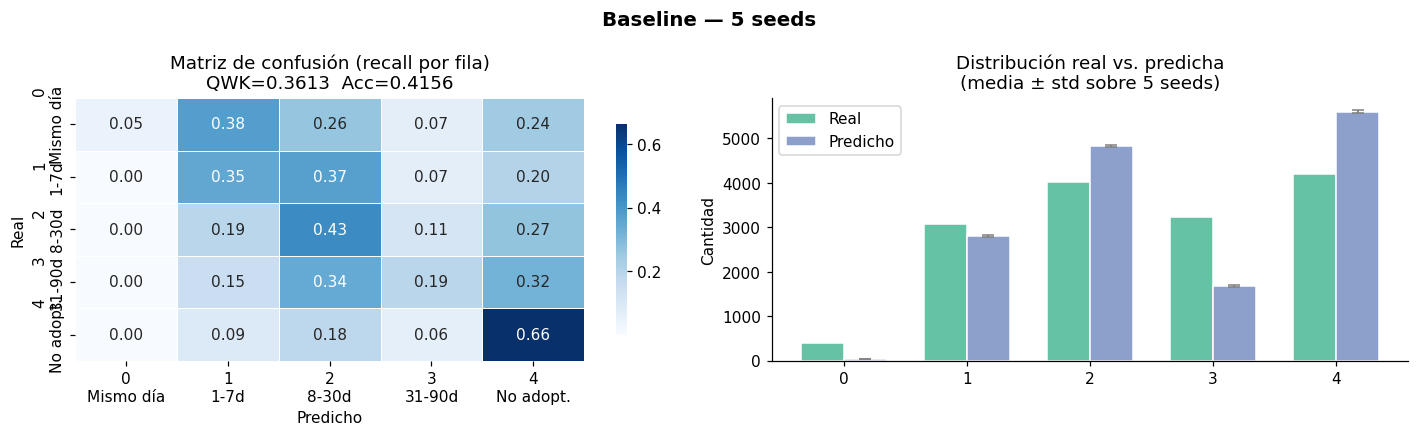

              precision    recall  f1-score   support

  0-MismoDía       0.54      0.05      0.09       410
  1-1ªSemana       0.38      0.35      0.36      3083
    2-1erMes       0.35      0.43      0.39      4029
 3-2do3erMes       0.39      0.19      0.26      3236
  4-NoAdopt.       0.49      0.66      0.57      4193

    accuracy                           0.42     14951
   macro avg       0.43      0.34      0.33     14951
weighted avg       0.41      0.42      0.40     14951



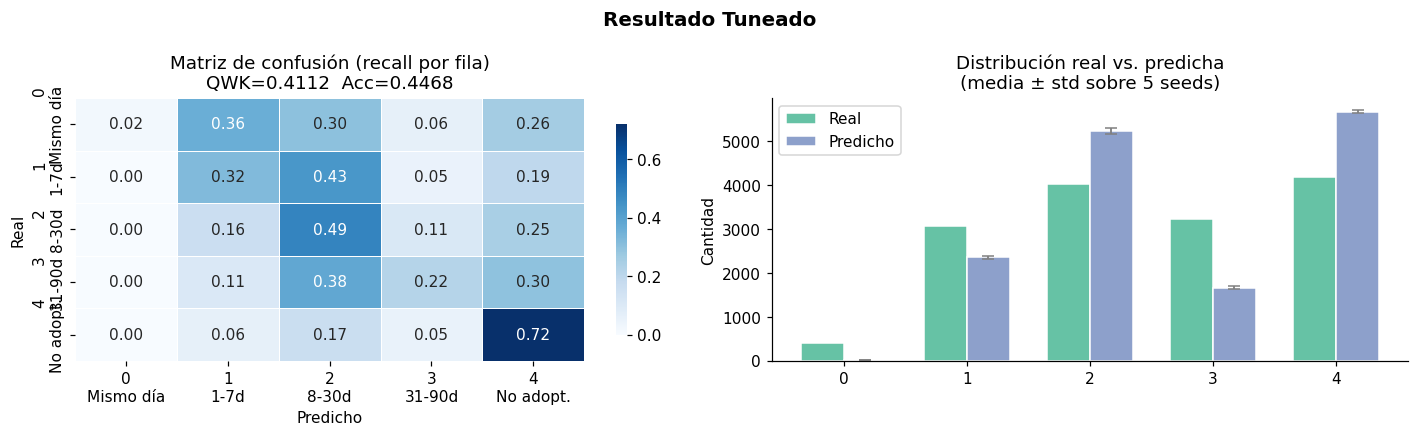

              precision    recall  f1-score   support

  0-MismoDía       0.73      0.02      0.04       410
  1-1ªSemana       0.41      0.32      0.36      3083
    2-1erMes       0.37      0.49      0.42      4029
 3-2do3erMes       0.46      0.22      0.30      3236
  4-NoAdopt.       0.53      0.72      0.61      4193

    accuracy                           0.45     14951
   macro avg       0.50      0.35      0.35     14951
weighted avg       0.45      0.45      0.42     14951



In [95]:
plot_results(y, [r['oof_preds'] for r in exp00b_baseline], title='Baseline — 5 seeds')
plot_results(y, [r['oof_preds'] for r in result_tuned], title='Resultado Tuneado')

El modelo tuneado parece tener sesgos similares al baseline, ya que tiende a clasificar con más frecuencia a las clases mayoritarias.
- Respecto de la clase 0: tiene dificultades para decidir que un caso corresponde a adopción instantánea (tal vez por el desbalanceo de esta clase), pero cuando clasifica de esta manera acierta en el 72% de las veces. 
- Respecto de la clase 1: las métricas se mantienen estables entre el baseline y el tuneado.
- Respecto de las clases 2, 3 y 4: el modelo final mejoró en su poder predictivo respecto del baseline.

El uso de embeddings con reducción de dimensionalidad parece mejorar la capacidad predictiva: 
Por un lado, hay señal en las descripciones: algo que se comenzaba a ver con la extracción de información desde el modelo tabular, como el conteo de palabras o caracteres, que ocupaban los primeros puestos en Feature Importance a lo largo de los distintos experimentos. Al incorporar tanto los embeddings como los análisis de sentimiento y de emociones el QWK creció fuertemente. No se trata simplemente de descripciones técnicas, sino de textos cargados de sentimiento que afectan la velocidad de adopción.
Por otro lado, hay señal en las imágenes: tal vez pueda tratarse de un factor de 'ternura' o ligado a la estética, o a la asociación de animales más populares que otros según raza (como indica la aparición de la variable Breed1 en el top 3 de Feature Importance)pelaje, etc.
Entre las variables tabulares, se destacó la Edad del animal (animales más cachorros tienden a ser adoptados con mayor velocidad), la Raza (tal vez por el factor de popularidad mencionado), y si el Rescatista es nuevo (puede indicar más experiencia a la hora de armar publicaciones, o redes de contactos más amplias si se trata de alguna organización)

Eventualmente se podría intentar trabajar con balanceo de clases. También se considera que se puede mejorar el cruce con los datos de imágenes y texto entrenando modelos de clasificación por separado y armando ensambles. Esto no se realizó para este trabajo por falta de poder computacional.